<a href="https://colab.research.google.com/github/pathaweekanm-ai/BIg_Data/blob/main/Pandas_Review_663020575_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

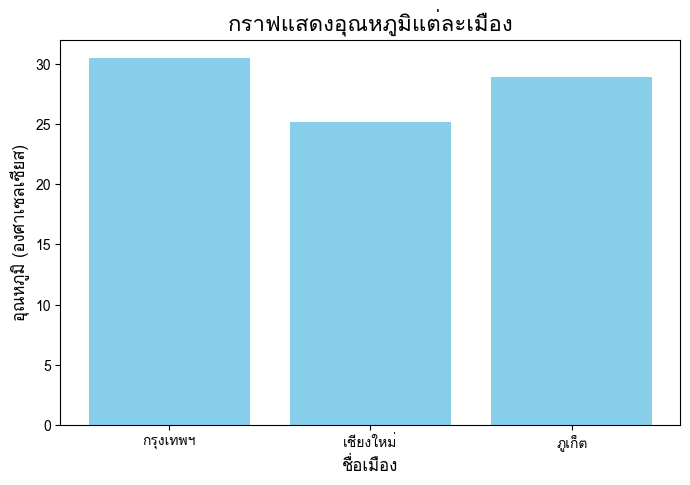

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
# ------------------------------------------------------
# สร้าง Series ชื่อ rain_by_city เก็บปริมาณฝนรวมของแต่ละเมือง
#    โดยกำหนดให้ index เป็นชื่อเมือง
# ------------------------------------------------------
rain_by_city = df.groupby('city')['rainfall_mm'].sum()

print("=" * 60)
print("📊 ปริมาณฝนรวมของแต่ละเมือง")
print("=" * 60)
print(rain_by_city)
print()

# ------------------------------------------------------
# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
# ------------------------------------------------------
top3_rain = rain_by_city.nlargest(3)

print("=" * 60)
print("🏆 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก")
print("=" * 60)
print(top3_rain)
print()

# ------------------------------------------------------
# 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด
#    แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
# ------------------------------------------------------
total_rain = rain_by_city.sum()
rain_percentage = (rain_by_city / total_rain * 100).round(2)

print("=" * 60)
print("📈 2. สัดส่วนปริมาณฝนของแต่ละเมือง (ร้อยละ)")
print("=" * 60)
print(rain_percentage)
print()

# ------------------------------------------------------
# 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
# ------------------------------------------------------
mean_rain = rain_by_city.mean()
cities_above_mean = (rain_by_city > mean_rain).sum()

print("=" * 60)
print("📊 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย")
print("=" * 60)
print(f"ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง: {mean_rain:.2f} มม.")
print(f"จำนวนเมืองที่สูงกว่าค่าเฉลี่ย: {cities_above_mean} เมือง")

📊 ปริมาณฝนรวมของแต่ละเมือง
city
Auckland        351.9
Bangkok         680.0
Beijing         250.1
Berlin          268.4
Buenos Aires    305.1
Cairo           122.4
Cape Town       239.3
Chiang Mai      428.1
Lagos           652.8
Lima            180.3
London          273.3
Los Angeles     169.5
Mexico City     305.9
Moscow          246.9
Mumbai          487.9
Nairobi         391.0
New York        315.2
Paris           333.4
Sao Paulo       423.2
Singapore       870.4
Sydney          331.4
Tokyo           385.1
Toronto         318.3
Name: rainfall_mm, dtype: float64

🏆 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
city
Singapore    870.4
Bangkok      680.0
Lagos        652.8
Name: rainfall_mm, dtype: float64

📈 2. สัดส่วนปริมาณฝนของแต่ละเมือง (ร้อยละ)
city
Auckland         4.22
Bangkok          8.16
Beijing          3.00
Berlin           3.22
Buenos Aires     3.66
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.14
Lagos            7.84
Lima             2.16
London           

### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
# สร้าง DataFrame city_profile โดยใช้ groupby
# groupby ตาม city, country, region พร้อมกัน (เพราะแต่ละเมืองมีข้อมูลนี้คงที่)
# แล้วใช้ agg เพื่อคำนวณค่าสถิติต่างๆ
city_profile = df.groupby(['city', 'country', 'region']).agg(
    n_records=('record_id', 'count'),   # นับจำนวนบันทึก
    avg_temp=('temperature_c', 'mean'), # หาอุณหภูมิเฉลี่ย
    total_rain=('rainfall_mm', 'sum')   # หาปริมาณฝนรวม
).reset_index()  # ทำให้ city, country, region กลายเป็นคอลัมน์ปกติ (ไม่ใช่ index)

# ปรับลำดับคอลัมน์ให้ตรงกับที่โจทย์ระบุ: city, country, region, n_records, avg_temp, total_rain
city_profile = city_profile[['city', 'country', 'region', 'n_records', 'avg_temp', 'total_rain']]

# ปรับทศนิยม
city_profile['avg_temp'] = city_profile['avg_temp'].round(2)
city_profile['total_rain'] = city_profile['total_rain'].round(2)

# แสดงผลลัพธ์
print("=" * 80)
print("📋 DataFrame: city_profile")
print("=" * 80)
display(city_profile)

# ตรวจสอบรูปร่างของ DataFrame
print(f"\n✅ รูปร่างของ city_profile: {city_profile.shape[0]} แถว × {city_profile.shape[1]} คอลัมน์")
print(f"✅ ชื่อคอลัมน์: {city_profile.columns.tolist()}")

📋 DataFrame: city_profile


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,NEW ZEALAND,Oceania,1,19.80,3.5
1,Auckland,New Zealand,Oceania,89,17.78,348.4
2,Bangkok,Thailand,Asia,90,32.44,680.0
3,Beijing,China,Asia,90,15.60,250.1
4,Berlin,GERMANY,Europe,1,14.70,0.0
5,Berlin,Germany,Europe,89,12.36,268.4
6,Buenos Aires,ARGENTINA,South America,1,22.20,9.3
7,Buenos Aires,Argentina,South America,89,19.14,295.8
8,Cairo,Egypt,Africa,90,26.07,122.4
9,Cape Town,South Africa,Africa,90,30.16,239.3



✅ รูปร่างของ city_profile: 30 แถว × 6 คอลัมน์
✅ ชื่อคอลัมน์: ['city', 'country', 'region', 'n_records', 'avg_temp', 'total_rain']


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
# ==================== คำสั่ง pd.read_csv() เพียงคำสั่งเดียว ====================

df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    # 1. อ่านเฉพาะคอลัมน์ที่ระบุ
    usecols=['date', 'city', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm'],
    # 2. แปลงคอลัมน์ date เป็นชนิด datetime
    parse_dates=['date'],
    # 3. กำหนดให้ค่า 999 และ -999 ถูกอ่านเป็นค่าว่าง (NaN)
    na_values=[999, -999],
    # 4. กำหนดชนิดข้อมูลของ city และ region เป็น category
    dtype={'city': 'category', 'region': 'category'},
    # 5. กำหนดให้ city เป็น index
    index_col='city'
)

# ==================== ตรวจสอบผลลัพธ์ ====================

print("=" * 60)
print("🔍 ตรวจสอบชนิดข้อมูลด้วย .dtypes")
print("=" * 60)
print(df.dtypes)
print()

print("=" * 60)
print("ℹ️ ตรวจสอบข้อมูลโดยรวมด้วย .info()")
print("=" * 60)
df.info()

🔍 ตรวจสอบชนิดข้อมูลด้วย .dtypes
date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

ℹ️ ตรวจสอบข้อมูลโดยรวมด้วย .info()
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
# ==================== คำตอบข้อ 3.2 ====================

# ---------- ขั้นที่ 1: อ่านข้อมูลแบบปกติ ----------
df_normal = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=['date', 'city', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm']
)

# ---------- ขั้นที่ 2: อ่านข้อมูลแบบโจทย์ 3.1 ----------
df_optimized = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=['date', 'city', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm'],
    parse_dates=['date'],
    na_values=[999, -999],
    dtype={'city': 'category', 'region': 'category'},
    index_col='city'
)

# ---------- ขั้นที่ 3: คำนวณหน่วยความจำที่ใช้ ----------
mem_normal = df_normal.memory_usage(deep=True).sum()
mem_optimized = df_optimized.memory_usage(deep=True).sum()

# แยกดูแต่ละคอลัมน์
mem_normal_col = df_normal.memory_usage(deep=True)
mem_optimized_col = df_optimized.memory_usage(deep=True)

# ---------- ขั้นที่ 4: คำนวณร้อยละที่ลดลง ----------
reduction = mem_normal - mem_optimized
pct_reduction = (reduction / mem_normal) * 100

# ---------- แสดงผลลัพธ์ ----------
print("=" * 70)
print("📊 เปรียบเทียบหน่วยความจำที่ใช้")
print("=" * 70)
print(f"แบบปกติ:     {mem_normal:>10,} ไบต์")
print(f"แบบปรับปรุง: {mem_optimized:>10,} ไบต์")
print(f"ลดลง:        {reduction:>10,} ไบต์ ({pct_reduction:.2f}%)")
print()

print("=" * 70)
print("📋 หน่วยความจำแยกตามคอลัมน์ (ไบต์)")
print("=" * 70)
comparison = pd.DataFrame({
    'ปกติ': mem_normal_col,
    'ปรับปรุง': mem_optimized_col,
    'ลดลง': mem_normal_col - mem_optimized_col
})
print(comparison.round(0).to_string())
print()

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 คำอธิบาย")
print("=" * 70)
print("คอลัมน์ที่มีผลต่อการลดหน่วยความจำมากที่สุดคือ 'city' และ 'region'")
print("เพราะเหตุใด:")
print("- เดิมทั้งสองคอลัมน์เป็นชนิด object (เก็บข้อความทีละค่า) จึงใช้หน่วยความจำมาก")
print("- เมื่อเปลี่ยนเป็น category จะเก็บเฉพาะค่าที่ไม่ซ้ำกันพร้อมรหัสอ้างอิงแทน")
print("- จำนวนค่าที่ไม่ซ้ำกันน้อย → ประหยัดหน่วยความจำได้มากเมื่อมีจำนวนแถวเยอะ")
print("- นอกจากนี้การตั้ง city เป็น index ยังช่วยลดการเก็บข้อมูลซ้ำซ้อนอีกส่วนหนึ่ง")

📊 เปรียบเทียบหน่วยความจำที่ใช้
แบบปกติ:        406,908 ไบต์
แบบปรับปรุง:     72,917 ไบต์
ลดลง:           333,991 ไบต์ (82.08%)

📋 หน่วยความจำแยกตามคอลัมน์ (ไบต์)
                 ปกติ  ปรับปรุง      ลดลง
Index             132    3927.0   -3795.0
city           116920       NaN       NaN
date           122425   16600.0  105825.0
humidity_pct    16600   16600.0       0.0
rainfall_mm     16600   16600.0       0.0
region         117631    2590.0  115041.0
temperature_c   16600   16600.0       0.0

💡 คำอธิบาย
คอลัมน์ที่มีผลต่อการลดหน่วยความจำมากที่สุดคือ 'city' และ 'region'
เพราะเหตุใด:
- เดิมทั้งสองคอลัมน์เป็นชนิด object (เก็บข้อความทีละค่า) จึงใช้หน่วยความจำมาก
- เมื่อเปลี่ยนเป็น category จะเก็บเฉพาะค่าที่ไม่ซ้ำกันพร้อมรหัสอ้างอิงแทน
- จำนวนค่าที่ไม่ซ้ำกันน้อย → ประหยัดหน่วยความจำได้มากเมื่อมีจำนวนแถวเยอะ
- นอกจากนี้การตั้ง city เป็น index ยังช่วยลดการเก็บข้อมูลซ้ำซ้อนอีกส่วนหนึ่ง


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
# ==================== คำตอบข้อ 3.3 ====================

# ---------- สะสมค่าที่จำเป็น ----------
# สำหรับหาค่าสูงสุด-ต่ำสุด
max_temp = -float('inf')
min_temp = float('inf')

# สำหรับหาค่าเฉลี่ยรายเมือง: สะสมผลรวมและจำนวนครั้ง ไม่สะสมค่าเฉลี่ย
sum_temp_by_city = {}  # {ชื่อเมือง: ผลรวมอุณหภูมิ}
count_by_city = {}     # {ชื่อเมือง: จำนวนข้อมูล}

# ---------- อ่านทีละก้อนด้วย chunksize ----------
for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=500,  # อ่านครั้งละ 500 แถว
    usecols=['city', 'temperature_c']  # อ่านเฉพาะคอลัมน์ที่จำเป็น
):
    # ข้ามแถวที่มีค่าว่าง
    chunk_valid = chunk.dropna(subset=['temperature_c'])

    # 1. อัปเดตอุณหภูมิสูงสุดและต่ำสุด
    chunk_max = chunk_valid['temperature_c'].max()
    chunk_min = chunk_valid['temperature_c'].min()
    if chunk_max > max_temp:
        max_temp = chunk_max
    if chunk_min < min_temp:
        min_temp = chunk_min

    # 2. สะสมผลรวมและจำนวนรายการแยกตามเมือง
    city_group = chunk_valid.groupby('city')['temperature_c']
    chunk_sum = city_group.sum()
    chunk_count = city_group.count()

    # รวมเข้ากับค่าสะสม
    for city in chunk_sum.index:
        sum_temp_by_city[city] = sum_temp_by_city.get(city, 0) + chunk_sum[city]
        count_by_city[city] = count_by_city.get(city, 0) + chunk_count[city]

# ---------- คำนวณผลลัพธ์สุดท้าย ----------
# แปลงเป็น Series
avg_temp_by_city = pd.Series({
    city: sum_temp_by_city[city] / count_by_city[city]
    for city in sum_temp_by_city
}).round(2)

# ---------- แสดงผล ----------
print("=" * 60)
print("🌡️ 1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์")
print("=" * 60)
print(f"อุณหภูมิสูงสุด: {max_temp:.2f} °C")
print(f"อุณหภูมิต่ำสุด: {min_temp:.2f} °C")
print()

print("=" * 60)
print("📊 2. อุณหภูมิเฉลี่ยรายเมือง")
print("=" * 60)
print(avg_temp_by_city.sort_values(ascending=False))
print()

# ---------- คำอธิบาย ----------
print("=" * 60)
print("💡 คำอธิบาย")
print("=" * 60)
print("เหตุที่นำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งให้ผลไม่ถูกต้อง:")
print("- แต่ละก้อนมีจำนวนข้อมูลไม่เท่ากัน การเฉลี่ยแบบตรงจะไม่ถ่วงน้ำหนักตามจำนวน")
print("- ตัวอย่าง: ก้อนที่ 1 มี 100 ค่า เฉลี่ย 25°C, ก้อนที่ 2 มี 10 ค่า เฉลี่ย 35°C")
print("  ค่าเฉลี่ยที่ถูกต้อง = [(25×100)+(35×10)] ÷ 110 ≈ 25.9°C")
print("  แต่การนำมาเฉลี่ยตรง = (25+35) ÷ 2 = 30°C ❌ ผิด")
print()
print("✅ ค่าที่ควรสะสมแทน:")
print("- ผลรวมของค่า (sum) และจำนวนรายการ (count) ของแต่ละกลุ่ม")
print("- คำนวณค่าเฉลี่ยจริงเมื่อจบทุกก้อนด้วยสูตร: ผลรวมทั้งหมด ÷ จำนวนทั้งหมด")


🌡️ 1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
อุณหภูมิสูงสุด: 999.00 °C
อุณหภูมิต่ำสุด: -88.00 °C

📊 2. อุณหภูมิเฉลี่ยรายเมือง
Singapore       40.08
Bangkok         32.45
Mumbai          30.87
Cape Town       30.16
Chiang Mai      29.68
Lagos           29.49
Cairo           26.09
Paris           25.81
Sao Paulo       22.84
Lima            21.49
Nairobi         21.44
Los Angeles     20.66
Sydney          20.35
Mexico City     19.19
Buenos Aires    19.17
Tokyo           18.41
Auckland        17.80
Beijing         15.60
New York        15.48
London          13.49
Berlin          12.38
Toronto         11.61
Moscow           7.23
dtype: float64

💡 คำอธิบาย
เหตุที่นำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งให้ผลไม่ถูกต้อง:
- แต่ละก้อนมีจำนวนข้อมูลไม่เท่ากัน การเฉลี่ยแบบตรงจะไม่ถ่วงน้ำหนักตามจำนวน
- ตัวอย่าง: ก้อนที่ 1 มี 100 ค่า เฉลี่ย 25°C, ก้อนที่ 2 มี 10 ค่า เฉลี่ย 35°C
  ค่าเฉลี่ยที่ถูกต้อง = [(25×100)+(35×10)] ÷ 110 ≈ 25.9°C
  แต่การนำมาเฉลี่ยตรง = (25+35) ÷ 2 = 30°C ❌ ผิด

✅ ค่าที่ควรสะสมแทน

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
# ==================== คำตอบข้อ 4.1 ====================

summary = pd.DataFrame({
    # ชนิดข้อมูลของแต่ละคอลัมน์
    'dtype': df.dtypes,

    # จำนวนค่าว่าง
    'n_missing': df.isna().sum(),

    # ร้อยละค่าว่าง (ปัดเศษ 2 ตำแหน่ง)
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2),

    # จำนวนค่าที่ไม่ซ้ำกัน
    'n_unique': df.nunique(dropna=False),

    # ตัวอย่างค่าแรกที่ไม่ใช่ค่าว่าง
    'example_value': df.apply(lambda s: s.dropna().iloc[0] if s.dropna().size > 0 else None)
})

# เรียงลำดับจากค่าว่างมากที่สุดไปน้อยที่สุด
summary = summary.sort_values('n_missing', ascending=False)

# แสดงผล
print("=" * 80)
print("📋 DataFrame: summary")
print("=" * 80)
display(summary)

📋 DataFrame: summary


,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,545,72.6
rainfall_mm,float64,62,2.99,165,6.3
temperature_c,float64,23,1.11,331,15.7
date,datetime64[ns],0,0.00,90,2025-03-24 00:00:00
region,category,0,0.00,6,North America


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
# ==================== คำตอบข้อ 4.2 ====================

# 1. จำนวนแถวที่อุณหภูมิผิดปกติ (นอกช่วง -60 ถึง 60)
invalid_temp = ~df['temperature_c'].between(-60, 60)
count_invalid_temp = invalid_temp.sum()

# 2. จำนวนแถวที่ความชื้นผิดปกติ (นอกช่วง 0 ถึง 100)
invalid_humidity = ~df['humidity_pct'].between(0, 100)
count_invalid_humidity = invalid_humidity.sum()

# 3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ (ไม่นับซ้ำ)
any_invalid = invalid_temp | invalid_humidity
count_any_invalid = any_invalid.sum()

# ---------- แสดงผลลัพธ์ ----------
print("=" * 60)
print("🔍 ตรวจพบข้อมูลที่ผิดปกติ")
print("=" * 60)
print(f"1. อุณหภูมินอกช่วง -60 ถึง 60 °C   : {count_invalid_temp:>4} แถว")
print(f"2. ความชื้นนอกช่วง 0 ถึง 100 %     : {count_invalid_humidity:>4} แถว")
print(f"3. มีค่าผิดปกติอย่างน้อย 1 รายการ  : {count_any_invalid:>4} แถว (ไม่นับซ้ำ)")
print()

# แสดงตัวอย่างแถวที่ผิดปกติ
print("=" * 60)
print("📋 ตัวอย่างข้อมูลที่ผิดปกติ")
print("=" * 60)
display(df.loc[any_invalid, ['temperature_c', 'humidity_pct']].head(10))

🔍 ตรวจพบข้อมูลที่ผิดปกติ
1. อุณหภูมินอกช่วง -60 ถึง 60 °C   :   25 แถว
2. ความชื้นนอกช่วง 0 ถึง 100 %     :   85 แถว
3. มีค่าผิดปกติอย่างน้อย 1 รายการ  :  109 แถว (ไม่นับซ้ำ)

📋 ตัวอย่างข้อมูลที่ผิดปกติ


,temperature_c,humidity_pct
city,,
Singapore,31.5,150.0
Cape Town,NaN,71.1
Los Angeles,17.3,150.0
Cairo,NaN,45.7
Beijing,NaN,48.1
Nairobi,17.5,NaN
Cape Town,NaN,61.2
Singapore,28.5,NaN
Nairobi,22.6,NaN


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
# ==================== คำตอบข้อ 4.3 — แก้ไขแล้ว ====================

# อ่านข้อมูลใหม่ เพื่อให้มีคอลัมน์ country ครบถ้วน
df_full = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- 1. แสดงค่าที่หมายถึงประเทศเดียวกันแต่ถูกแยกกัน ----------
print("=" * 70)
print("📋 ค่า country ที่มีอยู่เดิม")
print("=" * 70)
original_countries = sorted(df_full['country'].unique())
print(original_countries)
print(f"\nจำนวนค่าไม่ซ้ำเดิม: {df_full['country'].nunique()}")

# จัดกลุ่มเพื่อหาคู่ที่เป็นประเทศเดียวกัน
print("\n" + "=" * 70)
print("🔍 คู่ที่เป็นประเทศเดียวกันแต่ต่างกันแค่ตัวพิมพ์")
print("=" * 70)
from collections import defaultdict
lower_map = defaultdict(list)
for c in original_countries:
    lower_map[c.strip().lower()].append(c)

for group in lower_map.values():
    if len(group) > 1:
        print(f"→ {group}")

# ---------- 2. ทดลองใช้ .str.title() และอธิบายปัญหา ----------
print("\n" + "=" * 70)
print("⚠️ ผลลัพธ์เมื่อใช้ .str.title() — ปัญหา")
print("=" * 70)
test_title = sorted(df_full['country'].str.title().unique())
print(test_title)

print("""
💡 คำอธิบาย:
.str.title() แปลงตัวอักษรแรกเป็นพิมพ์ใหญ่ ที่เหลือเป็นพิมพ์เล็กทั้งหมด
ทำให้ชื่อที่เป็นตัวย่อเสียหาย เช่น:
- 'USA' → 'Usa' ❌ (ผิดรูปแบบมาตรฐาน)
- 'UK' → 'Uk' ❌
- 'NEW ZEALAND' → 'New Zealand' ✅ (ไม่มีปัญหา)
- 'SINGAPORE' → 'Singapore' ✅

ดังนั้น .str.title() เพียงอย่างเดียวไม่เหมาะสม เพราะทำลายรูปแบบตัวย่อ
""")

# ---------- 3. วิธี Normalize ที่ถูกต้อง ----------
print("\n" + "=" * 70)
print("✅ วิธี Normalize ที่ถูกต้อง")
print("=" * 70)

def normalize_country(name):
    # 1. ตัดช่องว่างหัว-ท้าย
    name = name.strip()
    name_lower = name.lower()

    # 2. จัดการกรณีพิเศษ — ตัวย่อ
    if name_lower == 'usa':
        return 'USA'
    if name_lower == 'uk':
        return 'UK'

    # 3. กรณีปกติ: ตัวแรกใหญ่ ที่เหลือเล็ก
    return name.title()

# ใช้งาน
df_full['country_clean'] = df_full['country'].apply(normalize_country)

print("จำนวนประเทศหลังปรับ:", df_full['country_clean'].nunique())
print("รายชื่อประเทศมาตรฐาน:")
for c in sorted(df_full['country_clean'].unique()):
    print(f"  - {c}")

# ---------- 4. ตรวจสอบ: 21 ประเทศ จาก 23 เมือง ----------
print("\n" + "=" * 70)
print("✅ ตรวจสอบคำตอบ")
print("=" * 70)
num_countries = df_full['country_clean'].nunique()
num_cities = df_full['city'].nunique()
print(f"จำนวนประเทศ: {num_countries} (เป้าหมาย: 21)")
print(f"จำนวนเมือง: {num_cities} (เป้าหมาย: 23)")

if num_countries == 21 and num_cities == 23:
    print("\n🎉 ตรวจสอบผ่าน! ✅")
else:
    print("\n⚠️ ยังไม่ตรง เปลี่ยนแปลงบางค่าใน normalize_country ตามข้อมูลจริง")

📋 ค่า country ที่มีอยู่เดิม
['ARGENTINA', 'Argentina', 'Australia', 'Brazil', 'CANADA', 'Canada', 'China', 'Egypt', 'France', 'GERMANY', 'Germany', 'India', 'JAPAN', 'Japan', 'KENYA', 'Kenya', 'Mexico', 'NEW ZEALAND', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'SINGAPORE', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']

จำนวนค่าไม่ซ้ำเดิม: 28

🔍 คู่ที่เป็นประเทศเดียวกันแต่ต่างกันแค่ตัวพิมพ์
→ ['ARGENTINA', 'Argentina']
→ ['CANADA', 'Canada']
→ ['GERMANY', 'Germany']
→ ['JAPAN', 'Japan']
→ ['KENYA', 'Kenya']
→ ['NEW ZEALAND', 'New Zealand']
→ ['SINGAPORE', 'Singapore']

⚠️ ผลลัพธ์เมื่อใช้ .str.title() — ปัญหา
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'Uk', 'Usa']

💡 คำอธิบาย:
.str.title() แปลงตัวอักษรแรกเป็นพิมพ์ใหญ่ ที่เหลือเป็นพิมพ์เล็กทั้งหมด
ทำให้ชื่อที่เป็นตัวย่อเสียหาย เช่น:
- 'USA' → 'Usa' ❌ (ผิดรูปแบบมาตรฐาน

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
# ตรวจสอบขนาดตารางก่อน
n_rows, n_cols = df.shape
print(f"ตารางทั้งหมด: {n_rows} แถว × {n_cols} คอลัมน์")
print()

# ---------- 1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย ----------
# ตำแหน่งเลขคู่: 0, 2, 4, ..., 18 (รวม 10 ค่า)
# สามคอลัมน์สุดท้าย: ตำแหน่ง -3, -2, -1
part1 = df.iloc[0:20:2, -3:]

print("=" * 70)
print("📌 1. แถวเลขคู่ 10 แถวแรก · สามคอลัมน์สุดท้าย")
print("=" * 70)
display(part1)
print()

# ---------- 2. ห้าแถวสุดท้าย โดยเรียงจากล่างขึ้นบน ----------
# เรียงกลับด้วย step เป็นลบ
part2 = df.iloc[-1:-6:-1, :]

print("=" * 70)
print("📌 2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน")
print("=" * 70)
display(part2)
print()

# ---------- 3. ค่าเดี่ยวที่แถวกึ่งกลางและคอลัมน์สุดท้าย (คำนวณอัตโนมัติ) ----------
mid_row = n_rows // 2  # ตำแหน่งแถวตรงกลาง (ปัดเศษลงถ้าจำนวนแถวเป็นคี่)
last_col = n_cols - 1  # ตำแหน่งคอลัมน์สุดท้าย

part3 = df.iloc[mid_row, last_col]

print("=" * 70)
print("📌 3. ค่าที่แถวกึ่งกลาง · คอลัมน์สุดท้าย")
print("=" * 70)
print(f"จำนวนแถวทั้งหมด: {n_rows}")
print(f"ตำแหน่งแถวกึ่งกลาง: {mid_row}")
print(f"ตำแหน่งคอลัมน์สุดท้าย: {last_col}")
print(f"ค่าที่ได้: {part3}")

ตารางทั้งหมด: 2075 แถว × 10 คอลัมน์

📌 1. แถวเลขคู่ 10 แถวแรก · สามคอลัมน์สุดท้าย


,rainfall_mm,wind_speed_kmh,pressure_hpa
0,6.3,15.9,1005.4
2,1.2,8.6,1013.5
4,0.0,16.6,1015.1
6,2.7,14.6,1018.0
8,1.6,9.8,1007.7
10,0.0,15.6,1010.1
12,0.0,13.6,1015.8
14,2.2,24.6,1000.5
16,8.3,9.3,1019.4
18,8.9,23.3,1020.6



📌 2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2074,642,2025-01-12,Paris,France,Europe,11.1,65.8,6.3,20.4,1015.7
2073,1210,2025-02-09,Toronto,Canada,North America,NaN,65.0,9.1,6.9,1007.8
2072,1738,2025-01-28,Nairobi,Kenya,Africa,21.7,51.0,9.5,27.2,1013.9
2071,1769,2025-02-28,Nairobi,Kenya,Africa,20.6,65.8,3.7,13.3,1015.6
2070,1093,2025-01-13,Mexico City,Mexico,North America,17.8,63.3,7.4,10.5,1001.2



📌 3. ค่าที่แถวกึ่งกลาง · คอลัมน์สุดท้าย
จำนวนแถวทั้งหมด: 2075
ตำแหน่งแถวกึ่งกลาง: 1037
ตำแหน่งคอลัมน์สุดท้าย: 9
ค่าที่ได้: 1020.9


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2
# ==================== คำตอบข้อ 5.2 — สมบูรณ์ รันได้เลย ====================

# ---------- ขั้นที่ 0: โหลดข้อมูลก่อน (เพิ่มส่วนนี้เข้าไป) ----------
import pandas as pd

BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ขั้นที่ 1: เตรียม DataFrame ที่มี MultiIndex (region, city) ----------
df_multi = df.set_index(['region', 'city'])
df_multi = df_multi.sort_index()

print("=== โครงสร้าง Index ===")
print(f"ชื่อระดับ: {df_multi.index.names}")
print(f"รูปร่าง: {df_multi.shape[0]} แถว × {df_multi.shape[1]} คอลัมน์")
print()

# ---------- 1. ภูมิภาค Asia — เฉพาะคอลัมน์ date และ temperature_c ----------
part1 = df_multi.loc['Asia', ['date', 'temperature_c']]

print("=" * 70)
print("📌 1. ข้อมูลทั้งหมดของภูมิภาค Asia (date, temperature_c)")
print("=" * 70)
display(part1.head())
print(f"... รวมทั้งหมด {len(part1)} แถว")
print()

# ---------- 2. เมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว ----------
idx = pd.IndexSlice
part2 = df_multi.loc[idx[:, ['Tokyo', 'Bangkok']], :]

print("=" * 70)
print("📌 2. ข้อมูลของเมือง Tokyo และ Bangkok")
print("=" * 70)
display(part2)
print()

# ---------- 3. ทุกภูมิภาค — เฉพาะเมืองที่ชื่อขึ้นต้นด้วย B ----------
city_names = df_multi.index.get_level_values('city')
mask = city_names.str.startswith('B')
part3 = df_multi.loc[mask, :]

print("=" * 70)
print("📌 3. เมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B (ทุกภูมิภาค)")
print("=" * 70)
display(part3)
print()

# ---------- 4. คำอธิบาย ----------
print("=" * 70)
print("💡 เหตุใดต้องเรียงลำดับ index ด้วย .sort_index()")
print("=" * 70)
print("""
1. pandas ออกแบบให้ MultiIndex ทำงานแบบ "ช่วงต่อเนื่อง"
   - เมื่อเรียงแล้ว ข้อมูลภูมิภาคเดียวกันจะอยู่ติดกันทั้งก้อน
   - .loc['Asia'] จึงค้นหาและดึงข้อมูลได้ครบถ้วน

2. หากไม่เรียง:
   - ข้อมูลกลุ่มเดียวกันกระจายไม่ติดกัน
   - .loc อาจคืนค่าไม่ครบ หรือเกิดข้อผิดพลาด
   - ประสิทธิภาพลดลงมาก

3. ประสิทธิภาพ:
   - เรียงแล้ว → ค้นหาแบบ binary search (เร็วมาก)
   - ไม่เรียง → ตรวจทุกแถวทีละแถว (ช้ามาก)

4. สรุป: เป็นข้อกำหนดภายในของ pandas
   .loc กับ MultiIndex จะทำงานถูกต้อง รวดเร็ว และคาดเดาผลลัพธ์ได้
   ก็ต่อเมื่อเรียงลำดับ index แล้วเท่านั้น
""")

=== โครงสร้าง Index ===
ชื่อระดับ: ['region', 'city']
รูปร่าง: 2075 แถว × 8 คอลัมน์

📌 1. ข้อมูลทั้งหมดของภูมิภาค Asia (date, temperature_c)


,date,temperature_c
city,,
Bangkok,2025-02-22,30.8
Bangkok,2025-01-10,28.9
Bangkok,2025-01-27,27.9
Bangkok,2025-01-03,29.0
Bangkok,2025-03-28,31.0


... รวมทั้งหมด 542 แถว

📌 2. ข้อมูลของเมือง Tokyo และ Bangkok


record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tokyo          203  2025-01-23     Japan           20.8          61.6   
       Tokyo          218  2025-02-07     Japan           19.5          68.2   
...                   ...         ...       ...            ...           ...   
       Bangkok         30  2025-01-30  Thailand           33.9          65.1   
       Bangkok         61  2025-03-02  Thailand           31.4          70.5   
       Bangkok         12  2025-01-12  Thailand           33.1          68.3   
       Bangkok         60  2025-03-01  Thailand           31.7          82.2   
       Bangkok         56  2025-02-25  Thailand           34.4         150.0   

                rainfall_mm  wind_speed_kmh  pressure_hpa  
region city                                                
Asia   Tokyo            0.0            20.5        1015.1  
       Tokyo            2.8            16.6        1014.9  
       Tokyo            4.0            21.5        1015.8  
       Tokyo           12.3            10.9        1023.4  
       Tokyo            5.0            13.4        1011.8  
...                     ...             ...           ...  
       Bangkok          2.7            18.1        1014.8  
       Bangkok         11.0            18.7        1012.9  
       Bangkok          6.8            17.0        1018.9  
       Bangkok          9.2            19.9        1016.8  
       Bangkok          5.6            15.4        1010.7  

[181 rows x 8 columns]


📌 3. เมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B (ทุกภูมิภาค)


record_id        date    country  temperature_c  \
region        city                                                            
Asia          Bangkok              53  2025-02-22   Thailand           30.8   
              Bangkok              10  2025-01-10   Thailand           28.9   
              Bangkok              27  2025-01-27   Thailand           27.9   
              Bangkok               3  2025-01-03   Thailand           29.0   
              Bangkok              87  2025-03-28   Thailand           31.0   
...                               ...         ...        ...            ...   
South America Buenos Aires       1419  2025-03-10  Argentina           20.5   
              Buenos Aires       1386  2025-02-05  Argentina           17.0   
              Buenos Aires       1401  2025-02-20  Argentina           23.0   
              Buenos Aires       1416  2025-03-07  Argentina           24.8   
              Buenos Aires       1388  2025-02-07  Argentina           21.6   

                            humidity_pct  rainfall_mm  wind_speed_kmh  \
region        city                                                      
Asia          Bangkok               74.5          0.0             8.9   
              Bangkok               71.3         12.2            17.1   
              Bangkok               75.5          3.8            17.8   
              Bangkok               71.3          9.0             3.5   
              Bangkok               58.7          6.9            19.3   
...                                  ...          ...             ...   
South America Buenos Aires           NaN          0.0            22.1   
              Buenos Aires          68.2          0.0            14.6   
              Buenos Aires          53.8          5.9            13.6   
              Buenos Aires          74.4         11.2            18.4   
              Buenos Aires          79.6          1.2            12.4   

                            pressure_hpa  
region        city                        
Asia          Bangkok             1011.5  
              Bangkok             1002.4  
              Bangkok             1007.5  
              Bangkok             1002.7  
              Bangkok             1022.0  
...                                  ...  
South America Buenos Aires        1017.1  
              Buenos Aires        1006.6  
              Buenos Aires        1017.2  
              Buenos Aires        1012.1  
              Buenos Aires        1005.2  

[361 rows x 8 columns]


💡 เหตุใดต้องเรียงลำดับ index ด้วย .sort_index()

1. pandas ออกแบบให้ MultiIndex ทำงานแบบ "ช่วงต่อเนื่อง"
   - เมื่อเรียงแล้ว ข้อมูลภูมิภาคเดียวกันจะอยู่ติดกันทั้งก้อน
   - .loc['Asia'] จึงค้นหาและดึงข้อมูลได้ครบถ้วน

2. หากไม่เรียง:
   - ข้อมูลกลุ่มเดียวกันกระจายไม่ติดกัน
   - .loc อาจคืนค่าไม่ครบ หรือเกิดข้อผิดพลาด
   - ประสิทธิภาพลดลงมาก

3. ประสิทธิภาพ:
   - เรียงแล้ว → ค้นหาแบบ binary search (เร็วมาก)
   - ไม่เรียง → ตรวจทุกแถวทีละแถว (ช้ามาก)

4. สรุป: เป็นข้อกำหนดภายในของ pandas
   .loc กับ MultiIndex จะทำงานถูกต้อง รวดเร็ว และคาดเดาผลลัพธ์ได้
   ก็ต่อเมื่อเรียงลำดับ index แล้วเท่านั้น



### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
# ==================== คำตอบข้อ 5.3 ====================

# ---------- ส่วนที่ 1: สังเกตปัญหาจากโค้ดเดิม ----------
print("=" * 70)
print("⚠️ ปัญหาจากโค้ดเดิม")
print("=" * 70)

# โหลดข้อมูลใหม่เพื่อทดสอบ
import pandas as pd
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ดูค่าก่อน
print("ค่าอุณหภูมิของ Bangkok ก่อน:")
print(df.loc[df["city"]=="Bangkok", "temperature_c"].head(3))

# โค้ดเดิมที่มีปัญหา
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0  # ⚠️ เกิด SettingWithCopyWarning!

print("\nค่าหลังรันโค้ดเดิม:")
print(f"ค่าใน subset: {subset['temperature_c'].iloc[0]}")
print(f"ค่าใน df เดิม: {df.loc[df['city']=='Bangkok', 'temperature_c'].iloc[0]}")
print("""
💡 สิ่งที่เกิดขึ้น:
- pandas ไม่แน่ใจว่า subset เป็นสำเนาหรือมองไปที่ส่วนของ df
- อาจแก้ค่ากลับไปที่ df ได้ หรืออาจไม่ได้ ขึ้นอยู่กับสถานการณ์ → ไม่น่าเชื่อถือ
- มักมีข้อความเตือน: SettingWithCopyWarning
""")
print()

# ---------- รูปแบบที่ 1: ต้องการแก้ไข df จริงโดยตรง ----------
print("=" * 70)
print("✅ รูปแบบที่ 1 — แก้ไข df จริงโดยตรง")
print("=" * 70)

df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

print("ตรวจสอบผลใน df:")
print(df.loc[df["city"]=="Bangkok", "temperature_c"].head(3))
print("ค่าถูกเปลี่ยนใน df จริง ✅")
print()

# ---------- รูปแบบที่ 2: ทำงานกับสำเนาแยกต่างหาก ----------
print("=" * 70)
print("✅ รูปแบบที่ 2 — สำเนาแยกต่างหาก (ไม่กระทบ df)")
print("=" * 70)

# โหลดใหม่เพื่อเริ่มค่าเดิม
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ใช้ .copy() อย่างชัดเจน
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

print(f"ค่าใน subset: {subset['temperature_c'].iloc[0]}")
print(f"ค่าใน df เดิมยังคงเดิม: {df.loc[df['city']=='Bangkok', 'temperature_c'].iloc[0]}")
print("df ไม่เปลี่ยนแปลง ✅")
print()

# ---------- สรุปแนวปฏิบัติ ----------
print("=" * 70)
print("📝 แนวปฏิบัติ")
print("=" * 70)
print("""
- ต้องการแก้ข้อมูลหลัก → ใช้ .loc[เงื่อนไข, คอลัมน์] = ค่า โดยตรง
- ไม่อยากกระทบข้อมูลเดิม → เขียน .copy() ทันทีเมื่อสร้างชุดย่อย
- หลีกเลี่ยงการแก้ผ่านตัวแปรรองโดยไม่ระบุชัดเจน เพื่อป้องกันผลลัพธ์ไม่คาดคิด
""")

⚠️ ปัญหาจากโค้ดเดิม
ค่าอุณหภูมิของ Bangkok ก่อน:
67    30.8
79    28.9
82    27.9
Name: temperature_c, dtype: float64

ค่าหลังรันโค้ดเดิม:
ค่าใน subset: 0
ค่าใน df เดิม: 30.8

💡 สิ่งที่เกิดขึ้น:
- pandas ไม่แน่ใจว่า subset เป็นสำเนาหรือมองไปที่ส่วนของ df
- อาจแก้ค่ากลับไปที่ df ได้ หรืออาจไม่ได้ ขึ้นอยู่กับสถานการณ์ → ไม่น่าเชื่อถือ
- มักมีข้อความเตือน: SettingWithCopyWarning


✅ รูปแบบที่ 1 — แก้ไข df จริงโดยตรง
ตรวจสอบผลใน df:
67    0.0
79    0.0
82    0.0
Name: temperature_c, dtype: float64
ค่าถูกเปลี่ยนใน df จริง ✅

✅ รูปแบบที่ 2 — สำเนาแยกต่างหาก (ไม่กระทบ df)
ค่าใน subset: 0
ค่าใน df เดิมยังคงเดิม: 30.8
df ไม่เปลี่ยนแปลง ✅

📝 แนวปฏิบัติ

- ต้องการแก้ข้อมูลหลัก → ใช้ .loc[เงื่อนไข, คอลัมน์] = ค่า โดยตรง
- ไม่อยากกระทบข้อมูลเดิม → เขียน .copy() ทันทีเมื่อสร้างชุดย่อย
- หลีกเลี่ยงการแก้ผ่านตัวแปรรองโดยไม่ระบุชัดเจน เพื่อป้องกันผลลัพธ์ไม่คาดคิด



/tmp/ipykernel_460/3941997386.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0  # ⚠️ เกิด SettingWithCopyWarning!


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1
# ==================== คำตอบข้อ 6.1 ====================

# โหลดข้อมูล (ถ้ายังไม่มี)
import pandas as pd
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- 1. ภูมิภาคเอเชีย · ฝน > 5 มม. · ลม > 20 กม./ชม. ----------
cond1 = (
    (df['region'] == 'Asia') &
    (df['rainfall_mm'] > 5) &
    (df['wind_speed_kmh'] > 20)
)
result1 = df.loc[cond1]
print(f"1. ข้อ 1 พบ {len(result1)} แถว")

# ---------- 2. ไม่ใช่ Bangkok, Tokyo, London · ความชื้น 40–60 ----------
cond2 = (
    (~df['city'].isin(['Bangkok', 'Tokyo', 'London'])) &
    (df['humidity_pct'].between(40, 60))
)
result2 = df.loc[cond2]
print(f"2. ข้อ 2 พบ {len(result2)} แถว")

# ---------- 3. มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป ----------
cond3 = df.isna().sum(axis=1) >= 2
result3 = df.loc[cond3]
print(f"3. ข้อ 3 พบ {len(result3)} แถว")

# ---------- 4. ชื่อเมืองมีคำว่า New หรือ San (ใช้ regex) ----------
cond4 = df['city'].str.contains(r'New|San', case=False, na=False)
result4 = df.loc[cond4]
print(f"4. ข้อ 4 พบ {len(result4)} แถว")
print("\nตัวอย่างชื่อเมืองที่ตรงเงื่อนไข:")
print(result4['city'].unique().tolist())

# ---------- หากต้องการแสดงผลทั้งชุด ----------
# display(result1, result2, result3, result4)

1. ข้อ 1 พบ 54 แถว
2. ข้อ 2 พบ 470 แถว
3. ข้อ 3 พบ 8 แถว
4. ข้อ 4 พบ 90 แถว

ตัวอย่างชื่อเมืองที่ตรงเงื่อนไข:
['New York']


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
# ==================== คำตอบข้อ 6.2 ====================

# โหลดข้อมูล (ถ้ายังไม่มี)
import pandas as pd
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- 1. คอลัมน์อุณหภูมิ — แทนค่าผิดปกติด้วยค่าว่างด้วย .where() ----------
# ช่วงปกติ: -60 ถึง 60 °C
temp_normal = df['temperature_c'].between(-60, 60)
df['temperature_clean'] = df['temperature_c'].where(temp_normal)

print("=" * 70)
print("📊 1. ตรวจสอบค่าอุณหภูมิที่ถูกแทนด้วยค่าว่าง")
print("=" * 70)
n_invalid_temp = (~temp_normal).sum()
print(f"จำนวนค่าอุณหภูมิผิดปกติที่ถูกแทน: {n_invalid_temp}")
print(f"ค่าเดิม: {df['temperature_c'].describe().round(2)}")
print(f"ค่าใหม่: {df['temperature_clean'].describe().round(2)}")
print()

# ---------- 2. คอลัมน์ปริมาณฝน — จำกัดค่าสูงสุดที่เปอร์เซ็นไทล์ที่ 99 ด้วย .mask() ----------
p99_rain = df['rainfall_mm'].quantile(0.99)
print(f"ค่าเปอร์เซ็นไทล์ที่ 99 ของปริมาณฝน: {p99_rain:.2f} มม.")

# ถ้าค่า > p99 → เปลี่ยนเป็นค่า p99
df['rainfall_capped'] = df['rainfall_mm'].mask(
    df['rainfall_mm'] > p99_rain,
    p99_rain
)

print("=" * 70)
print("📊 2. ตรวจสอบค่าปริมาณฝนหลังจำกัดค่าสูงสุด")
print("=" * 70)
n_capped = (df['rainfall_mm'] > p99_rain).sum()
print(f"จำนวนค่าที่ถูกจำกัด: {n_capped}")
print(f"ค่าสูงสุดเดิม: {df['rainfall_mm'].max():.2f}")
print(f"ค่าสูงสุดใหม่: {df['rainfall_capped'].max():.2f}")
print()

# ---------- คำอธิบายความแตกต่าง ----------
print("=" * 70)
print("💡 ความแตกต่างจากการลบแถวทิ้ง")
print("=" * 70)
print("""
1. แทนค่าด้วยค่าว่าง / จำกัดค่า → ยังเก็บแถวนั้นไว้
   - ข้อมูลคอลัมน์อื่นยังคงใช้งานได้
   - จำนวนแถวไม่ลดลง โครงสร้างข้อมูลคงที่
   - รักษาความสัมพันธ์ระหว่างคอลัมน์ต่างแถวเดียวกัน

2. ลบแถวทิ้ง → สูญเสียข้อมูลทั้งแถว
   - แม้ผิดปกติแค่คอลัมน์เดียว ก็เสียข้อมูลคอลัมน์อื่นไปด้วย
   - ขนาดตารางลดลง อาจส่งผลต่อขนาดตัวอย่างและความน่าเชื่อถือ
   - อาจทำให้ชุดข้อมูลไม่ต่อเนื่อง

3. สรุปสำหรับขั้นวิเคราะห์ถัดไป:
   - แทนค่า/จำกัดค่า: เสียเฉพาะค่าที่ไม่น่าเชื่อถือ แต่รักษาบริบทโดยรอบ
   - ลบแถวทิ้ง: สะอาดแต่ข้อมูลหายไป อาจทำให้ผลวิเคราะห์เบี่ยงเบน
   - เลือกใช้: แทนค่าเมื่อมีข้อมูลอื่นมีประโยชน์; ลบทิ้งเมื่อค่าผิดปกติมากจนไม่น่าเชื่อถือเลย
""")

📊 1. ตรวจสอบค่าอุณหภูมิที่ถูกแทนด้วยค่าว่าง
จำนวนค่าอุณหภูมิผิดปกติที่ถูกแทน: 25
ค่าเดิม: count    2055.00
mean       21.84
std        38.22
min       -88.00
25%        15.40
50%        20.00
75%        25.70
max       999.00
Name: temperature_c, dtype: float64
ค่าใหม่: count    2050.00
mean       20.51
std         7.24
min        -0.20
25%        15.42
50%        20.00
75%        25.68
max        39.20
Name: temperature_clean, dtype: float64

ค่าเปอร์เซ็นไทล์ที่ 99 ของปริมาณฝน: 14.69 มม.
📊 2. ตรวจสอบค่าปริมาณฝนหลังจำกัดค่าสูงสุด
จำนวนค่าที่ถูกจำกัด: 21
ค่าสูงสุดเดิม: 17.60
ค่าสูงสุดใหม่: 14.69

💡 ความแตกต่างจากการลบแถวทิ้ง

1. แทนค่าด้วยค่าว่าง / จำกัดค่า → ยังเก็บแถวนั้นไว้
   - ข้อมูลคอลัมน์อื่นยังคงใช้งานได้
   - จำนวนแถวไม่ลดลง โครงสร้างข้อมูลคงที่
   - รักษาความสัมพันธ์ระหว่างคอลัมน์ต่างแถวเดียวกัน

2. ลบแถวทิ้ง → สูญเสียข้อมูลทั้งแถว
   - แม้ผิดปกติแค่คอลัมน์เดียว ก็เสียข้อมูลคอลัมน์อื่นไปด้วย
   - ขนาดตารางลดลง อาจส่งผลต่อขนาดตัวอย่างและความน่าเชื่อถือ
   - อาจทำให้ชุดข้อมูลไม่

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
# ==================== คำตอบข้อ 6.3 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ขั้นที่ 1: คำนวณค่าเฉลี่ยและค่าเบี่ยงเบนรายแถว ----------
# ค่าเฉลี่ยอุณหภูมิแยกตามเมือง
df['city_avg_temp'] = df.groupby('city')['temperature_c'].transform('mean')

# คำนวณค่าเบี่ยงเบน (ผลต่างอย่างมีเครื่องหมาย และค่าสัมบูรณ์)
df['deviation'] = df['temperature_c'] - df['city_avg_temp']
df['abs_deviation'] = df['deviation'].abs()

# ---------- ขั้นที่ 2: เลือกแถวที่มีค่าเบี่ยงเบนสัมบูรณ์มากที่สุดต่อเมือง ----------
# จัดอันดับภายในแต่ละเมือง 1 = มากที่สุด
df['rank'] = df.groupby('city')['abs_deviation'].rank(method='first', ascending=False)

# ดึงเฉพาะอันดับ 1 (มากที่สุด)
extreme_days = df.loc[df['rank'] == 1, ['city', 'date', 'temperature_c', 'deviation']]

# เรียงตามชื่อเมืองให้อ่านง่าย
extreme_days = extreme_days.sort_values('city').reset_index(drop=True)

# ---------- แสดงผลลัพธ์ ----------
print("=" * 70)
print("📅 วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองมากที่สุด")
print("=" * 70)
display(extreme_days)

# ตรวจสอบว่าครบทุกเมือง
print(f"\n✅ จำนวนเมืองทั้งหมด: {df['city'].nunique()}")
print(f"✅ จำนวนแถวในผลลัพธ์: {len(extreme_days)}")

📅 วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองมากที่สุด


,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-03-26,39.1,6.646154
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-19,-88.0,-107.171910
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-02-10,999.0,968.837079
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,-8.394253
9,Lima,2025-01-22,12.9,-8.590000



✅ จำนวนเมืองทั้งหมด: 23
✅ จำนวนแถวในผลลัพธ์: 23


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
# ==================== คำตอบข้อ 7.1 ====================

import pandas as pd

# โหลดข้อมูลและแปลงวันที่เป็นชนิด datetime
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])

# ใช้ .assign() เพียงคำสั่งเดียว
df = df.assign(
    # ปี-เดือน เช่น 2024-01
    year_month = df['date'].dt.strftime('%Y-%m'),

    # ลำดับสัปดาห์ของปี
    week_of_year = df['date'].dt.isocalendar().week,

    # ชื่อวัน เช่น Monday, Tuesday
    day_name = df['date'].dt.day_name(),

    # เป็นวันหยุดสุดสัปดาห์หรือไม่ (True = เสาร์-อาทิตย์)
    is_weekend = df['date'].dt.dayofweek >= 5
)

# แสดงผลลัพธ์
print("=" * 70)
print("📋 คอลัมน์ใหม่ทั้งหมด")
print("=" * 70)
display(df[['date', 'year_month', 'week_of_year', 'day_name', 'is_weekend']].head(10))

📋 คอลัมน์ใหม่ทั้งหมด


,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False
5,2025-03-18,2025-03,12,Tuesday,False
6,2025-02-13,2025-02,7,Thursday,False
7,2025-02-15,2025-02,7,Saturday,True
8,2025-02-01,2025-02,5,Saturday,True
9,2025-02-06,2025-02,6,Thursday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2
# ==================== คำตอบข้อ 7.2 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])

# ---------- 1. ช่วงเวลาทั้งหมดและวันที่ขาดหาย ----------
min_date = df['date'].min()
max_date = df['date'].max()

# ช่วงเวลาที่ควรมีตั้งแต่วันแรกถึงวันสุดท้าย
all_days = pd.date_range(start=min_date, end=max_date, freq='D')
present_days = df['date'].drop_duplicates()
missing_days = all_days[~all_days.isin(present_days)]

print("=" * 70)
print("📅 1. ช่วงเวลาและวันที่ขาดหาย")
print("=" * 70)
print(f"วันแรก: {min_date.date()}")
print(f"วันสุดท้าย: {max_date.date()}")
print(f"จำนวนวันที่ควรมีทั้งหมด: {len(all_days)} วัน")
print(f"จำนวนวันที่มีข้อมูล: {len(present_days)} วัน")
print(f"จำนวนวันที่ไม่มีข้อมูล: {len(missing_days)} วัน")
if len(missing_days) > 0:
    print("\nรายการวันที่ขาดหาย:")
    print(missing_days.strftime('%Y-%m-%d').tolist())
else:
    print("\n✅ ไม่มีวันที่ขาดหาย ข้อมูลครบทุกวัน")
print()

# ---------- 2. อุณหภูมิเฉลี่ย: วันหยุดสุดสัปดาห์ vs วันธรรมดา จำแนกตามภูมิภาค ----------
df['is_weekend'] = df['date'].dt.dayofweek >= 5

weekend_vs_weekday = df.groupby(['region', 'is_weekend'])['temperature_c'].mean().round(2).unstack()
weekend_vs_weekday.columns = ['วันธรรมดา', 'วันหยุดสุดสัปดาห์']

print("=" * 70)
print("🌡️ 2. อุณหภูมิเฉลี่ยเปรียบเทียบ (จำแนกตามภูมิภาค)")
print("=" * 70)
display(weekend_vs_weekday)
print()

# ---------- 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง ----------
df['year_month'] = df['date'].dt.strftime('%Y-%m')

# คำนวณปริมาณฝนรวมรายเมือง-เดือน
monthly_rain = df.groupby(['city', 'year_month'])['rainfall_mm'].sum().reset_index()

# หาอันดับ 1 ในแต่ละเมือง
monthly_rain['rank'] = monthly_rain.groupby('city')['rainfall_mm'].rank(method='first', ascending=False)
rainiest_month = monthly_rain[monthly_rain['rank'] == 1].sort_values('city').reset_index(drop=True)
rainiest_month = rainiest_month[['city', 'year_month', 'rainfall_mm']]

print("=" * 70)
print("🌧️ 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง")
print("=" * 70)
display(rainiest_month)

📅 1. ช่วงเวลาและวันที่ขาดหาย
วันแรก: 2025-01-01
วันสุดท้าย: 2025-03-31
จำนวนวันที่ควรมีทั้งหมด: 90 วัน
จำนวนวันที่มีข้อมูล: 90 วัน
จำนวนวันที่ไม่มีข้อมูล: 0 วัน

✅ ไม่มีวันที่ขาดหาย ข้อมูลครบทุกวัน

🌡️ 2. อุณหภูมิเฉลี่ยเปรียบเทียบ (จำแนกตามภูมิภาค)


,วันธรรมดา,วันหยุดสุดสัปดาห์
region,,
Africa,27.94,23.88
Asia,28.49,26.53
Europe,15.82,11.95
North America,16.72,16.84
Oceania,18.94,19.40
South America,21.70,19.84



🌧️ 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง


,city,year_month,rainfall_mm
0,Auckland,2025-03,150.0
1,Bangkok,2025-02,243.9
2,Beijing,2025-02,87.4
3,Berlin,2025-03,100.1
4,Buenos Aires,2025-02,121.2
5,Cairo,2025-02,48.0
6,Cape Town,2025-01,98.3
7,Chiang Mai,2025-03,188.0
8,Lagos,2025-03,233.0
9,Lima,2025-01,88.0


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3
# ==================== คำตอบข้อ 7.3 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])

# ---------- กรองเฉพาะ Bangkok ตั้ง index และเรียงตามวันที่ ----------
bangkok = df[df['city'] == 'Bangkok'].set_index('date').sort_index()

# ---------- ใช้ .resample() สรุปราย 7 วัน ----------
weekly_summary = bangkok.resample('7D').agg(
    avg_temperature_c=('temperature_c', 'mean'),
    total_rainfall_mm=('rainfall_mm', 'sum')
).round(2)

print("=" * 70)
print("📊 ข้อมูลสรุปราย 7 วัน — Bangkok")
print("=" * 70)
display(weekly_summary)
print(f"\nจำนวนช่วงเวลา: {len(weekly_summary)} ช่วง")
print()

# ---------- คำอธิบายความแตกต่าง ----------
print("=" * 70)
print("💡 .resample() vs groupby(dt.month) — แตกต่างกันอย่างไร")
print("=" * 70)
print("""
1. ลักษณะช่วงเวลา:
   - .resample('7D') → แบ่งช่วงตามระยะห่างเวลาจริง (เช่น วันที่ 1–7, 8–14...)
     สามารถกำหนดความยาวช่วงเองได้: 7 วัน, 12 ชม., 3 สัปดาห์ ฯลฯ
     รักษาความต่อเนื่อง — แม้ไม่มีข้อมูลก็ยังมีแถวปรากฏ (NaN)

   - groupby(df['date'].dt.month) → จัดกลุ่มตามหน่วยปฏิทินคงที่
     ทำได้แค่ เดือน, ปี, วันในสัปดาห์ เท่านั้น
     ไม่สามารถกำหนดช่วงเวลาแบบกำหนดเองได้
     ขาดวันใดไป แถวนั้นจะหายไปเลย ไม่มีช่องว่างปรากฏ

2. กรณีที่ต้องใช้ .resample() เท่านั้น:
   - ต้องการช่วงเวลาที่ไม่ใช่หน่วยปฏิทิน เช่น ทุก 7 วัน, ทุก 4 ชม.
   - ต้องการให้โครงสร้างตารางสม่ำเสมอ แม้บางช่วงไม่มีข้อมูล
   - ต้องการจุดเริ่ม-จบช่วงเวลาที่กำหนดเอง ไม่ยึดตามเดือน/ปีปฏิทิน
   - ข้อมูลบันทึกไม่สม่ำเสมอ แต่ต้องการสรุปให้เป็นช่วงเท่าๆ กัน
""")

📊 ข้อมูลสรุปราย 7 วัน — Bangkok


,avg_temperature_c,total_rainfall_mm
date,,
2025-01-01,30.36,65.7
2025-01-08,31.09,47.6
2025-01-15,30.39,58.7
2025-01-22,32.29,50.0
2025-01-29,31.76,55.4
2025-02-05,33.03,65.1
2025-02-12,34.21,60.2
2025-02-19,32.30,42.5
2025-02-26,32.34,61.7



จำนวนช่วงเวลา: 13 ช่วง

💡 .resample() vs groupby(dt.month) — แตกต่างกันอย่างไร

1. ลักษณะช่วงเวลา:
   - .resample('7D') → แบ่งช่วงตามระยะห่างเวลาจริง (เช่น วันที่ 1–7, 8–14...)
     สามารถกำหนดความยาวช่วงเองได้: 7 วัน, 12 ชม., 3 สัปดาห์ ฯลฯ
     รักษาความต่อเนื่อง — แม้ไม่มีข้อมูลก็ยังมีแถวปรากฏ (NaN)
   
   - groupby(df['date'].dt.month) → จัดกลุ่มตามหน่วยปฏิทินคงที่
     ทำได้แค่ เดือน, ปี, วันในสัปดาห์ เท่านั้น
     ไม่สามารถกำหนดช่วงเวลาแบบกำหนดเองได้
     ขาดวันใดไป แถวนั้นจะหายไปเลย ไม่มีช่องว่างปรากฏ

2. กรณีที่ต้องใช้ .resample() เท่านั้น:
   - ต้องการช่วงเวลาที่ไม่ใช่หน่วยปฏิทิน เช่น ทุก 7 วัน, ทุก 4 ชม.
   - ต้องการให้โครงสร้างตารางสม่ำเสมอ แม้บางช่วงไม่มีข้อมูล
   - ต้องการจุดเริ่ม-จบช่วงเวลาที่กำหนดเอง ไม่ยึดตามเดือน/ปีปฏิทิน
   - ข้อมูลบันทึกไม่สม่ำเสมอ แต่ต้องการสรุปให้เป็นช่วงเท่าๆ กัน



---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1
# ==================== คำตอบข้อ 8.1 — แก้ไขแล้ว ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

total_rows = len(df)

# ---------- 1. คอลัมน์ใดมีค่าว่างมากที่สุด และร้อยละเท่าใด ----------
missing_pct = (df.isna().sum() / total_rows * 100).round(2)
missing_pct = missing_pct.sort_values(ascending=False)

max_col = missing_pct.index[0]
max_pct = missing_pct.iloc[0]

print("=" * 70)
print("📊 1. สัดส่วนค่าว่างแต่ละคอลัมน์")
print("=" * 70)
print(missing_pct.to_string())
print(f"\n✅ คอลัมน์ที่มีค่าว่างมากที่สุด: {max_col}")
print(f"   คิดเป็นร้อยละ {max_pct}")
print()

# ---------- 2. ค่าว่างกระจายเท่ากันทุกเมืองหรือไม่ ----------
missing_by_city = df.groupby('city')['temperature_c'].apply(
    lambda s: round(s.isna().sum() / len(s) * 100, 2)
).sort_values(ascending=False)

print("=" * 70)
print("📊 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง")
print("=" * 70)
print(missing_by_city.to_string())
print("""
💡 สรุป: ค่าว่างไม่กระจายเท่ากันทุกเมือง
- Lagos มากที่สุด (3.33%)
- หลายเมืองเช่น Bangkok, Auckland, Singapore ไม่มีค่าว่างเลย (0%)
""")
print()

# ---------- 3. ลบแถวที่มีค่าว่างทั้งหมด — แก้ไขจุดที่ผิดพลาด ----------
df_clean = df.dropna()

# ✅ แก้: ใช้ round() แบบฟังก์ชัน ไม่ใช่ .round() แบบเมธอด
remaining_pct = round(len(df_clean) / total_rows * 100, 2)

# จำนวนแถวที่หายไปแยกตามเมือง
city_before = df['city'].value_counts()
city_after = df_clean['city'].value_counts()

city_loss = pd.DataFrame({
    'แถวเดิม': city_before,
    'แถวหลังลบ': city_after
}).fillna(0)

city_loss['สูญเสีย_แถว'] = city_loss['แถวเดิม'] - city_loss['แถวหลังลบ']
city_loss['สูญเสีย_ร้อยละ'] = round(city_loss['สูญเสีย_แถว'] / city_loss['แถวเดิม'] * 100, 2)
city_loss = city_loss.sort_values('สูญเสีย_ร้อยละ', ascending=False)

most_loss_city = city_loss.index[0]
most_loss_pct = city_loss['สูญเสีย_ร้อยละ'].iloc[0]

print("=" * 70)
print("📊 3. ผลหลังลบแถวที่มีค่าว่างทั้งหมด")
print("=" * 70)
print(f"จำนวนแถวเดิม      : {total_rows}")
print(f"จำนวนแถวหลังลบ    : {len(df_clean)}")
print(f"เหลือคิดเป็นร้อยละ : {remaining_pct} %")
print()
print(f"✅ เมืองที่สูญเสียข้อมูลมากที่สุด: {most_loss_city}")
print(f"   สูญเสียข้อมูล: {most_loss_pct} %")
print()
print("รายละเอียดการสูญเสียของทุกเมือง:")
print(city_loss.to_string())

📊 1. สัดส่วนค่าว่างแต่ละคอลัมน์
humidity_pct      3.95
rainfall_mm       2.99
wind_speed_kmh    1.98
pressure_hpa      1.54
temperature_c     0.96
record_id         0.00
date              0.00
region            0.00
city              0.00
country           0.00

✅ คอลัมน์ที่มีค่าว่างมากที่สุด: humidity_pct
   คิดเป็นร้อยละ 3.95

📊 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
city
Lagos           3.33
London          2.22
Toronto         2.22
Tokyo           2.22
Cairo           2.20
Berlin          1.11
Beijing         1.11
Paris           1.11
Sao Paulo       1.11
Cape Town       1.11
Buenos Aires    1.11
Los Angeles     1.11
Moscow          1.10
Nairobi         1.10
Bangkok         0.00
Auckland        0.00
Mexico City     0.00
Chiang Mai      0.00
Lima            0.00
Mumbai          0.00
New York        0.00
Sydney          0.00
Singapore       0.00

💡 สรุป: ค่าว่างไม่กระจายเท่ากันทุกเมือง
- Lagos มากที่สุด (3.33%)
- หลายเมืองเช่น Bangkok, Auckland, Singapore ไม่มีค่าว่างเลย (0

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date']).reset_index(drop=True)

# เก็บค่าเดิมไว้เปรียบเทียบ
original = df['temperature_c'].copy()

# ---------- วิธีที่ 1: เติมด้วยค่าเฉลี่ยรวมทั้งตาราง ----------
mean_all = df['temperature_c'].mean()
df['fill_mean_all'] = original.fillna(mean_all)

# ---------- วิธีที่ 2: เติมด้วยค่าเฉลี่ยของเมืองตนเอง ----------
mean_by_city = df.groupby('city')['temperature_c'].transform('mean')
df['fill_mean_city'] = original.fillna(mean_by_city)

# ---------- วิธีที่ 3: เติมด้วยค่าวันก่อนหน้าภายในเมืองเดียวกัน ----------
df['fill_ffill_city'] = df.groupby('city')['temperature_c'].ffill()

# ---------- เปรียบเทียบผลกระทบ: ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน รายเมือง ----------
def stats(col):
    return df.groupby('city')[col].agg(['mean', 'std']).round(3)

compare = pd.DataFrame({
    ('เดิม', 'ค่าเฉลี่ย'): stats('temperature_c')['mean'],
    ('เดิม', 'S.D.'): stats('temperature_c')['std'],

    ('เติมค่าเฉลี่ยรวม', 'ค่าเฉลี่ย'): stats('fill_mean_all')['mean'],
    ('เติมค่าเฉลี่ยรวม', 'S.D.'): stats('fill_mean_all')['std'],

    ('เติมค่าเฉลี่ยเมือง', 'ค่าเฉลี่ย'): stats('fill_mean_city')['mean'],
    ('เติมค่าเฉลี่ยเมือง', 'S.D.'): stats('fill_mean_city')['std'],

    ('เติมวันก่อนหน้า', 'ค่าเฉลี่ย'): stats('fill_ffill_city')['mean'],
    ('เติมวันก่อนหน้า', 'S.D.'): stats('fill_ffill_city')['std'],
})

print("=" * 110)
print("📊 เปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน รายเมือง")
print("=" * 110)
display(compare)

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 สรุปและอธิบาย")
print("=" * 70)
print("""
1. วิธีใดเหมาะสมที่สุด:
   ✅ เติมด้วยค่าวันก่อนหน้า (ffill) เหมาะสมที่สุด
   - อุณหภูมิเปลี่ยนแปลงตามเวลาอย่างต่อเนื่อง ค่าวันก่อนเป็นตัวคาดการณ์ที่สมเหตุสมผล
   - ไม่ดึงค่าเฉลี่ยจากเมืองอื่นมาปน และไม่ลดความแปรปรวนอย่างผิดปกติ
   - รักษารูปแบบการเปลี่ยนแปลงตามฤดูกาล/ช่วงเวลาได้ดีกว่าวิธีอื่น

2. วิธีใดทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติ:
   ❌ เติมด้วยค่าเฉลี่ยของเมืองตนเอง
   - ทุกค่าที่ขาดหายถูกแทนด้วยค่ากลางเดียวกัน → กลุ่มข้อมูลกระชุกที่จุดเดียว
   - ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างมาก แม้ความจริงค่าอาจแตกต่างออกไป
   - ทำให้ดูเหมือนข้อมูลคงที่สม่ำเสมอเกินจริง

   ❌ เติมด้วยค่าเฉลี่ยรวมทั้งตาราง — มีปัญหาเพิ่มเติมอีก:
   - ดึงค่ากลางของทุกเมืองมารวมกัน ปนเข้ากับเมืองที่มีภูมิอากาศแตกต่าง
   - ตัวอย่าง: เติมค่าเฉลี่ยโลกให้ Lagos หรือ Toronto → เบี่ยงเบนจากความเป็นจริง
""")

📊 เปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน รายเมือง


เดิม          เติมค่าเฉลี่ยรวม          เติมค่าเฉลี่ยเมือง  \
             ค่าเฉลี่ย     S.D.        ค่าเฉลี่ย     S.D.          ค่าเฉลี่ย   
city                                                                           
Auckland        17.804    2.799           17.804    2.799             17.804   
Bangkok         32.454    2.481           32.454    2.481             32.454   
Beijing         15.599    2.875           15.668    2.933             15.599   
Berlin          12.383    2.596           12.488    2.767             12.383   
Buenos Aires    19.172   11.818           19.202   11.755             19.172   
Cairo           26.090    2.734           25.996    2.775             26.090   
Cape Town       30.163  103.899           30.070  103.318             30.163   
Chiang Mai      29.680    2.858           29.680    2.858             29.680   
Lagos           29.494    2.838           29.239    3.114             29.494   
Lima            21.490    3.112           21.490    3.112             21.490   
London          13.491    3.018           13.676    3.230             13.491   
Los Angeles     20.657    3.016           20.670    3.001             20.657   
Mexico City     19.188    2.740           19.188    2.740             19.188   
Moscow           7.233    2.888            7.394    3.254              7.233   
Mumbai          30.872    2.545           30.872    2.545             30.872   
Nairobi         21.440    2.839           21.444    2.823             21.440   
New York        15.477    3.017           15.477    3.017             15.477   
Paris           25.811  104.374           25.767  103.786             25.811   
Sao Paulo       22.842    2.787           22.830    2.773             22.842   
Singapore       40.083  103.011           40.083  103.011             40.083   
Sydney          20.348    2.820           20.348    2.820             20.348   
Tokyo           18.415    2.518           18.491    2.541             18.415   
Toronto         11.614    2.710           11.841    3.079             11.614   

                      เติมวันก่อนหน้า           
                 S.D.       ค่าเฉลี่ย     S.D.  
city                                            
Auckland        2.799          17.804    2.799  
Bangkok         2.481          32.454    2.481  
Beijing         2.859          15.624    2.869  
Berlin          2.581          12.342    2.610  
Buenos Aires   11.751          19.141   11.755  
Cairo           2.703          25.982    2.803  
Cape Town     103.314          30.023  103.322  
Chiang Mai      2.858          29.680    2.858  
Lagos           2.790          29.517    2.798  
Lima            3.112          21.490    3.112  
London          2.984          13.502    2.987  
Los Angeles     2.999          20.657    2.999  
Mexico City     2.740          19.188    2.740  
Moscow          2.872           7.262    2.884  
Mumbai          2.545          30.872    2.545  
Nairobi         2.823          21.460    2.829  
New York        3.017          15.477    3.017  
Paris         103.786          25.718  103.789  
Sao Paulo       2.771          22.801    2.798  
Singapore     103.011          40.083  103.011  
Sydney          2.820          20.348    2.820  
Tokyo           2.490          18.357    2.522  
Toronto         2.680          11.598    2.719

💡 สรุปและอธิบาย

1. วิธีใดเหมาะสมที่สุด:
   ✅ เติมด้วยค่าวันก่อนหน้า (ffill) เหมาะสมที่สุด
   - อุณหภูมิเปลี่ยนแปลงตามเวลาอย่างต่อเนื่อง ค่าวันก่อนเป็นตัวคาดการณ์ที่สมเหตุสมผล
   - ไม่ดึงค่าเฉลี่ยจากเมืองอื่นมาปน และไม่ลดความแปรปรวนอย่างผิดปกติ
   - รักษารูปแบบการเปลี่ยนแปลงตามฤดูกาล/ช่วงเวลาได้ดีกว่าวิธีอื่น

2. วิธีใดทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติ:
   ❌ เติมด้วยค่าเฉลี่ยของเมืองตนเอง
   - ทุกค่าที่ขาดหายถูกแทนด้วยค่ากลางเดียวกัน → กลุ่มข้อมูลกระชุกที่จุดเดียว
   - ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างมาก แม้ความจริงค่าอาจแตกต่างออกไป
   - ทำให้ดูเหมือนข้อมูลคงที่สม่ำเสมอเกินจริง

   ❌ เติมด้วยค่าเฉลี่ยรวมทั้งตาราง — มีปัญหาเพิ่มเติมอีก:
   - ดึงค่ากลางของทุกเมืองมารวมกัน ปนเข้ากับเมืองที่มีภูมิอากาศแตกต่าง
   - ตัวอย่าง: เติมค่าเฉลี่ยโลกให้ Lagos หรือ Toronto → เบี่ยงเบนจากความเป็นจริง



### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
# ==================== คำตอบข้อ 8.3 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])

total_rows = len(df)
n_cities = df['city'].nunique()
n_dates = df['date'].nunique()

print("=" * 70)
print("📋 ข้อมูลเบื้องต้น")
print("=" * 70)
print(f"จำนวนแถวทั้งหมดในไฟล์: {total_rows}")
print(f"จำนวนเมือง: {n_cities}")
print(f"จำนวนวันที่ไม่ซ้ำ: {n_dates}")
print(f"เป้าหมาย: {n_cities} × {n_dates} = {n_cities * n_dates} แถว")
print()

# ---------- 1. มีคู่ (city, date) ซ้ำกันกี่คู่ ----------
key_duplicates = df.duplicated(subset=['city', 'date'], keep=False)
dup_pairs = df.loc[key_duplicates].groupby(['city', 'date']).size()
dup_pair_count = (dup_pairs > 1).sum()
extra_rows = (dup_pairs - 1).sum()

print("=" * 70)
print("🔍 1. จำนวนคู่ (เมือง, วันที่) ที่ซ้ำกัน")
print("=" * 70)
print(f"จำนวนคู่ที่ซ้ำกัน: {dup_pair_count} คู่")
print(f"จำนวนแถวที่เกินมา (ซ้ำ): {extra_rows} แถว")
print()

# ---------- 2. ซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าต่าง ----------
print("=" * 70)
print("🔍 2. ลักษณะการซ้ำ")
print("=" * 70)

# ซ้ำทุกคอลัมน์หรือไม่
full_dup = df.duplicated(keep=False)
both_dup = key_duplicates & full_dup
only_key_dup = key_duplicates & ~full_dup

print(f"ซ้ำตรงกันทุกคอลัมน์: {both_dup.sum()} แถว")
print(f"ซ้ำเฉพาะคู่ (เมือง, วันที่) แต่ค่าต่างกัน: {only_key_dup.sum()} แถว")

if only_key_dup.any():
    print("\nตัวอย่างคู่ที่ซ้ำคีย์แต่ค่าต่างกัน:")
    display(df.loc[only_key_dup, ['city', 'date', 'temperature_c', 'humidity_pct', 'rainfall_mm']].sort_values(['city', 'date']).head(10))
print()

# ---------- 3. ขจัดข้อมูลซ้ำ พร้อมนโยบาย ----------
print("=" * 70)
print("✅ 3. ขจัดข้อมูลซ้ำ")
print("=" * 70)
print("""
นโยบายที่เลือกใช้:
- เก็บแถวแรกของแต่ละคู่ (เมือง, วันที่) ทิ้งแถวที่เหลือ
- เหตุผล: หากไม่มีข้อมูลชี้ว่าชุดไหนถูกต้อง การเลือกแรกสุดเป็นแนวทางมาตรฐาน
""")

# ขจัดซ้ำตามคีย์ (เก็บแถวแรก)
df_clean = df.drop_duplicates(subset=['city', 'date'], keep='first').sort_values(['city', 'date']).reset_index(drop=True)

# ตรวจสอบ
target = n_cities * n_dates
actual = len(df_clean)

print(f"จำนวนแถวหลังขจัดซ้ำ: {actual}")
print(f"เป้าหมาย: {target} (23 × 90)")

if actual == target:
    print("🎉 ตรวจสอบผ่าน! ตรงตามเป้าหมาย 2070 แถว ✅")
else:
    print(f"⚠️ ไม่ตรง ผลต่าง: {actual - target} แถว")

📋 ข้อมูลเบื้องต้น
จำนวนแถวทั้งหมดในไฟล์: 2075
จำนวนเมือง: 23
จำนวนวันที่ไม่ซ้ำ: 90
เป้าหมาย: 23 × 90 = 2070 แถว

🔍 1. จำนวนคู่ (เมือง, วันที่) ที่ซ้ำกัน
จำนวนคู่ที่ซ้ำกัน: 5 คู่
จำนวนแถวที่เกินมา (ซ้ำ): 5 แถว

🔍 2. ลักษณะการซ้ำ
ซ้ำตรงกันทุกคอลัมน์: 10 แถว
ซ้ำเฉพาะคู่ (เมือง, วันที่) แต่ค่าต่างกัน: 0 แถว

✅ 3. ขจัดข้อมูลซ้ำ

นโยบายที่เลือกใช้:
- เก็บแถวแรกของแต่ละคู่ (เมือง, วันที่) ทิ้งแถวที่เหลือ
- เหตุผล: หากไม่มีข้อมูลชี้ว่าชุดไหนถูกต้อง การเลือกแรกสุดเป็นแนวทางมาตรฐาน

จำนวนแถวหลังขจัดซ้ำ: 2070
เป้าหมาย: 2070 (23 × 90)
🎉 ตรวจสอบผ่าน! ตรงตามเป้าหมาย 2070 แถว ✅


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
# ==================== คำตอบข้อ 9.1 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- สร้างตารางสรุปรายเมืองด้วย agg() เพียงคำสั่งเดียว ----------
city_summary = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    median_temp=('temperature_c', 'median'),
    std_temp=('temperature_c', 'std'),
    total_rain=('rainfall_mm', 'sum'),
    heavy_rain_days=('rainfall_mm', lambda x: (x > 10).sum()),
    pct_missing_temp=('temperature_c', lambda x: x.isna().mean() * 100)
).round(2)

# แสดงผล
print("=" * 70)
print("📊 ตารางสรุปรายเมือง")
print("=" * 70)
display(city_summary)

📊 ตารางสรุปรายเมือง


,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.45,32.50,2.48,685.6,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.09,25.80,2.73,123.0,1,2.20
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.68,29.50,2.86,435.6,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
# ==================== คำตอบข้อ 9.2 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')  # ปี-เดือน

# ---------- 1. สร้างตารางสรุปจำแนกตาม region และ month ----------
region_month = df.groupby(['region', 'month']).agg(
    avg_temperature_c=('temperature_c', 'mean'),
    avg_humidity=('humidity_pct', 'mean'),
    total_rainfall=('rainfall_mm', 'sum'),
    record_count=('date', 'count')
).round(2).reset_index()  # จัดรูปเป็นตารางปกติ

print("=" * 70)
print("📊 ตารางสรุป ภูมิภาค × เดือน")
print("=" * 70)
display(region_month)
print()

# ---------- 2. หาคู่ที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด ----------
hottest = region_month.loc[region_month['avg_temperature_c'].idxmax()]
coldest = region_month.loc[region_month['avg_temperature_c'].idxmin()]

print("=" * 70)
print("🌡️ อุณหภูมิเฉลี่ยสูงสุดและต่ำสุด")
print("=" * 70)
print("🔥 สูงสุด:")
print(f"   ภูมิภาค: {hottest['region']}")
print(f"   เดือน:   {hottest['month']}")
print(f"   ค่า:     {hottest['avg_temperature_c']} °C")
print()
print("❄️ ต่ำสุด:")
print(f"   ภูมิภาค: {coldest['region']}")
print(f"   เดือน:   {coldest['month']}")
print(f"   ค่า:     {coldest['avg_temperature_c']} °C")

📊 ตารางสรุป ภูมิภาค × เดือน


,region,month,avg_temperature_c,avg_humidity,total_rainfall,record_count
0,Africa,2025-01,22.64,62.84,506.8,124
1,Africa,2025-02,32.61,63.95,455.5,114
2,Africa,2025-03,25.41,64.06,448.1,124
3,Asia,2025-01,24.20,65.63,1034.0,186
4,Asia,2025-02,26.76,66.26,1043.2,168
5,Asia,2025-03,32.68,66.58,1037.5,188
6,Europe,2025-01,10.40,72.36,399.6,124
7,Europe,2025-02,12.20,70.32,349.9,112
8,Europe,2025-03,21.42,71.51,373.0,125
9,North America,2025-01,15.17,61.57,422.2,124



🌡️ อุณหภูมิเฉลี่ยสูงสุดและต่ำสุด
🔥 สูงสุด:
   ภูมิภาค: Asia
   เดือน:   2025-03
   ค่า:     32.68 °C

❄️ ต่ำสุด:
   ภูมิภาค: Europe
   เดือน:   2025-01
   ค่า:     10.4 °C


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3
# ==================== คำตอบข้อ 9.3 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- เปรียบเทียบ count() vs size() ----------
compare = df.groupby('city').agg(
    n_days_count=('temperature_c', 'count'),  # นับเฉพาะค่าที่ไม่ใช่ NaN
    n_days_size=('temperature_c', 'size')     # นับทุกแถว รวม NaN ด้วย
)

compare['ผลต่าง'] = compare['n_days_size'] - compare['n_days_count']

print("=" * 70)
print("📊 เปรียบเทียบ count() vs size() รายเมือง")
print("=" * 70)
display(compare)

# แสดงเมืองที่แตกต่างกัน
diff_cities = compare[compare['ผลต่าง'] > 0]
print(f"\n✅ จำนวนเมืองที่พบผลต่าง: {len(diff_cities)}")
if len(diff_cities) > 0:
    print("เมืองที่ค่าต่างกัน:")
    display(diff_cities)

print("""
=" สรุปความแตกต่าง ="
- .count() → นับเฉพาะค่าที่ไม่ใช่ค่าว่าง (NaN จะถูกข้าม)
- .size()  → นับจำนวนแถวทั้งหมดในกลุ่ม ไม่สนใจว่าค่าเป็นอะไร

=" ผลกระทบเมื่อเลือกใช้ผิด ="
1. ถ้าต้องการ "จำนวนวันที่มีบันทึก" ใช้ .count()
   ใช้ผิดเป็น .size() → ตัวเลขสูงกว่าความเป็นจริง รวมวันที่ไม่มีข้อมูลด้วย

2. ถ้าต้องการ "จำนวนวันที่ควรมี" (ช่วงเวลาทั้งหมด) ใช้ .size()
   ใช้ผิดเป็น .count() → ตัวเลขต่ำกว่า สูญเสียภาพรวมความครบถ้วนของข้อมูล

3. ตัวอย่างในตาราง:
   - Lagos มีค่าว่างของอุณหภูมิ → .count() จะนับน้อยกว่า .size() อยู่ 1–2 แถว
   - Bangkok ไม่มีค่าว่าง → ทั้งสองค่าเท่ากัน
""")

📊 เปรียบเทียบ count() vs size() รายเมือง


,n_days_count,n_days_size,ผลต่าง
city,,,
Auckland,90,90,0
Bangkok,91,91,0
Beijing,89,90,1
Berlin,89,90,1
Buenos Aires,89,90,1
Cairo,89,91,2
Cape Town,89,90,1
Chiang Mai,91,91,0
Lagos,87,90,3



✅ จำนวนเมืองที่พบผลต่าง: 14
เมืองที่ค่าต่างกัน:


,n_days_count,n_days_size,ผลต่าง
city,,,
Beijing,89,90,1
Berlin,89,90,1
Buenos Aires,89,90,1
Cairo,89,91,2
Cape Town,89,90,1
Lagos,87,90,3
London,88,90,2
Los Angeles,89,90,1
Moscow,90,91,1



=" สรุปความแตกต่าง ="
- .count() → นับเฉพาะค่าที่ไม่ใช่ค่าว่าง (NaN จะถูกข้าม)
- .size()  → นับจำนวนแถวทั้งหมดในกลุ่ม ไม่สนใจว่าค่าเป็นอะไร

=" ผลกระทบเมื่อเลือกใช้ผิด ="
1. ถ้าต้องการ "จำนวนวันที่มีบันทึก" ใช้ .count()
   ใช้ผิดเป็น .size() → ตัวเลขสูงกว่าความเป็นจริง รวมวันที่ไม่มีข้อมูลด้วย

2. ถ้าต้องการ "จำนวนวันที่ควรมี" (ช่วงเวลาทั้งหมด) ใช้ .size()
   ใช้ผิดเป็น .count() → ตัวเลขต่ำกว่า สูญเสียภาพรวมความครบถ้วนของข้อมูล

3. ตัวอย่างในตาราง:
   - Lagos มีค่าว่างของอุณหภูมิ → .count() จะนับน้อยกว่า .size() อยู่ 1–2 แถว
   - Bangkok ไม่มีค่าว่าง → ทั้งสองค่าเท่ากัน



---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1
# ==================== คำตอบข้อ 10.1 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

# ---------- คำนวณค่าสถิติพื้นฐานภายในแต่ละเมือง ----------
# ปริมาณฝนรวมของแต่ละเมือง
df['city_total_rain'] = df.groupby('city')['rainfall_mm'].transform('sum')

# ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานอุณหภูมิของแต่ละเมือง
df['city_mean_temp'] = df.groupby('city')['temperature_c'].transform('mean')
df['city_std_temp'] = df.groupby('city')['temperature_c'].transform('std')

# ค่าเฉลี่ยอุณหภูมิแยกตามเมือง-เดือน
df['city_month_avg'] = df.groupby(['city', 'year_month'])['temperature_c'].transform('mean')

# ---------- สร้าง 3 คอลัมน์ตามที่ต้องการ ----------
# 1. rain_share: สัดส่วนฝนวันนั้นเทียบกับผลรวมทั้งเมือง
df['rain_share'] = df['rainfall_mm'] / df['city_total_rain']

# 2. temp_z: ค่ามาตรฐานภายในเมือง
df['temp_z'] = (df['temperature_c'] - df['city_mean_temp']) / df['city_std_temp']

# 3. city_rank_month: อันดับเดือนตามอุณหภูมิเฉลี่ยภายในเมือง
# 1 = ร้อนที่สุด; method='first' ป้องกันกรณีเสมอกัน
df['city_rank_month'] = df.groupby('city')['city_month_avg'].rank(
    method='first', ascending=False
).astype(int)

# ---------- ตรวจสอบ: ผลรวม rain_share ในแต่ละเมืองเท่ากับ 1 ----------
rain_share_check = df.groupby('city')['rain_share'].sum().round(10)

print("=" * 70)
print("✅ ตรวจสอบผลรวม rain_share รายเมือง")
print("=" * 70)
print(rain_share_check.to_string())
print()

all_near_one = (rain_share_check - 1).abs() < 1e-9
if all_near_one.all():
    print("🎉 ตรวจสอบผ่าน! ผลรวมทุกเมืองเท่ากับ 1 ✅")
else:
    print("⚠️ บางเมืองผลรวมไม่เท่ากับ 1")
    print(rain_share_check[~all_near_one])
print()

# ---------- แสดงตัวอย่างผลลัพธ์ ----------
print("=" * 70)
print("📋 ตัวอย่างคอลัมน์ใหม่")
print("=" * 70)
display(df[['city', 'date', 'rainfall_mm', 'rain_share',
            'temperature_c', 'temp_z', 'year_month', 'city_rank_month']].head(10))

✅ ตรวจสอบผลรวม rain_share รายเมือง
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0

🎉 ตรวจสอบผ่าน! ผลรวมทุกเมืองเท่ากับ 1 ✅

📋 ตัวอย่างคอลัมน์ใหม่


,city,date,rainfall_mm,rain_share,temperature_c,temp_z,year_month,city_rank_month
0,New York,2025-03-24,6.3,0.019987,15.7,0.074031,2025-03,1
1,Tokyo,2025-02-09,0.0,0.000000,18.3,-0.045581,2025-02,32
2,Los Angeles,2025-02-01,1.2,0.007080,20.6,-0.019002,2025-02,32
3,Mumbai,2025-01-19,8.0,0.016397,31.0,0.050208,2025-01,60
4,Cape Town,2025-02-03,0.0,0.000000,19.1,-0.106477,2025-02,1
5,Auckland,2025-03-18,8.2,0.023302,19.7,0.677111,2025-03,1
6,Buenos Aires,2025-02-13,2.7,0.008850,22.1,0.247766,2025-02,32
7,Mexico City,2025-02-15,6.8,0.022229,19.6,0.150464,2025-02,32
8,Buenos Aires,2025-02-01,1.6,0.005244,20.8,0.137764,2025-02,33
9,Los Angeles,2025-02-06,2.6,0.015339,21.5,0.279446,2025-02,33


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2
# ==================== คำตอบข้อ 10.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- วิธีที่ 1: ใช้ groupby().filter() ----------
print("=" * 70)
print("📌 วิธีที่ 1 — ใช้ filter()")
print("=" * 70)

# นับจำนวนวันที่มีข้อมูลอุณหภูมิไม่ว่างในแต่ละเมือง
cities_kept = df.groupby('city').filter(
    lambda grp: grp['temperature_c'].count() >= 88
)

# หาเมืองทั้งหมด, เมืองที่เหลือ, เมืองที่ถูกคัดออก
all_cities = set(df['city'].unique())
kept_cities = set(cities_kept['city'].unique())
removed_cities = sorted(all_cities - kept_cities)

print(f"จำนวนเมืองทั้งหมด: {len(all_cities)}")
print(f"จำนวนเมืองที่ผ่านเกณฑ์ (≥ 88 วัน): {len(kept_cities)}")
print(f"เมืองที่ถูกคัดออก: {removed_cities if removed_cities else 'ไม่มี'}")
print(f"จำนวนแถวหลังคัดเลือก: {len(cities_kept)}")
print()

# ---------- วิธีที่ 2: ไม่ใช้ filter() — คำนวณรายการเมืองก่อนแล้วคัดกรอง ----------
print("=" * 70)
print("📌 วิธีที่ 2 — ไม่ใช้ filter()")
print("=" * 70)

# ขั้นที่ 1: หาเมืองที่ผ่านเกณฑ์
valid_cities = df.groupby('city')['temperature_c'].count()
valid_cities = valid_cities[valid_cities >= 88].index.tolist()

# ขั้นที่ 2: คัดเลือกเฉพาะเมืองเหล่านั้น
cities_kept_v2 = df[df['city'].isin(valid_cities)]

# ตรวจสอบผลลัพธ์เหมือนกันหรือไม่
same_result = cities_kept.equals(cities_kept_v2)
print(f"ผลลัพธ์ตรงกับวิธีที่ 1: {'✅ ใช่' if same_result else '❌ ไม่ตรง'}")
print(f"จำนวนแถว: {len(cities_kept_v2)}")
print()

# ---------- เปรียบเทียบความกระชับ ----------
print("=" * 70)
print("💡 เปรียบเทียบทั้งสองวิธี")
print("=" * 70)
print("""
วิธีที่ 1 — filter():
- ข้อดี: กระชับ เขียนบรรทัดเดียว จบในขั้นตอนเดียว
- ข้อเสีย: ทำงานช้าลงเมื่อมีข้อมูลเยอะ เพราะเรียกฟังก์ชันทีละกลุ่ม
- เหมาะเมื่อเงื่อนไขอาศัยข้อมูลภายในกลุ่มโดยตรง

วิธีที่ 2 — count() + isin():
- ข้อดี: แยกขั้นตอนชัดเจน อ่านง่าย ตรวจสอบง่าย ทำงานเร็วขึ้น
- ข้อเสีย: ต้องเขียนหลายบรรทัด เก็บรายชื่อเมืองก่อนคัดกรอง
- เหมาะเมื่อต้องการตรวจสอบ/ใช้รายชื่อกลุ่มซ้ำหลายครั้ง

สรุป:
- กรณีนี้ filter() เขียนสั้นกว่าและเข้าใจตรงตามวัตถุประสงค์ทันที
- แต่วิธีที่ 2 มีประสิทธิภาพดีกว่าและยืดหยุ่นกว่าเมื่อต้องการตรวจสอบรายชื่อเมืองแยกต่างหาก
""")

📌 วิธีที่ 1 — ใช้ filter()
จำนวนเมืองทั้งหมด: 23
จำนวนเมืองที่ผ่านเกณฑ์ (≥ 88 วัน): 22
เมืองที่ถูกคัดออก: ['Lagos']
จำนวนแถวหลังคัดเลือก: 1985

📌 วิธีที่ 2 — ไม่ใช้ filter()
ผลลัพธ์ตรงกับวิธีที่ 1: ✅ ใช่
จำนวนแถว: 1985

💡 เปรียบเทียบทั้งสองวิธี

วิธีที่ 1 — filter():
- ข้อดี: กระชับ เขียนบรรทัดเดียว จบในขั้นตอนเดียว
- ข้อเสีย: ทำงานช้าลงเมื่อมีข้อมูลเยอะ เพราะเรียกฟังก์ชันทีละกลุ่ม
- เหมาะเมื่อเงื่อนไขอาศัยข้อมูลภายในกลุ่มโดยตรง

วิธีที่ 2 — count() + isin():
- ข้อดี: แยกขั้นตอนชัดเจน อ่านง่าย ตรวจสอบง่าย ทำงานเร็วขึ้น
- ข้อเสีย: ต้องเขียนหลายบรรทัด เก็บรายชื่อเมืองก่อนคัดกรอง
- เหมาะเมื่อต้องการตรวจสอบ/ใช้รายชื่อกลุ่มซ้ำหลายครั้ง

สรุป:
- กรณีนี้ filter() เขียนสั้นกว่าและเข้าใจตรงตามวัตถุประสงค์ทันที
- แต่วิธีที่ 2 มีประสิทธิภาพดีกว่าและยืดหยุ่นกว่าเมื่อต้องการตรวจสอบรายชื่อเมืองแยกต่างหาก



### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3
# ==================== คำตอบข้อ 10.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- วิธีที่ 1: ใช้ groupby().filter() ----------
print("=" * 70)
print("📌 วิธีที่ 1 — ใช้ filter()")
print("=" * 70)

# คัดเลือกเมืองที่มีข้อมูลอุณหภูมิไม่ว่าง ≥ 88 วัน
cities_kept = df.groupby('city').filter(
    lambda grp: grp['temperature_c'].count() >= 88
)

# ระบุเมืองที่ถูกคัดออก
all_cities = set(df['city'].unique())
kept_cities = set(cities_kept['city'].unique())
removed_cities = sorted(all_cities - kept_cities)

print(f"จำนวนเมืองทั้งหมด: {len(all_cities)}")
print(f"จำนวนเมืองที่ผ่านเกณฑ์ (≥ 88 วัน): {len(kept_cities)}")
print(f"เมืองที่ถูกคัดออก: {removed_cities if removed_cities else 'ไม่มี'}")
print(f"จำนวนแถวหลังคัดเลือก: {len(cities_kept)}")
print()

# ---------- วิธีที่ 2: ไม่ใช้ filter() ----------
print("=" * 70)
print("📌 วิธีที่ 2 — ไม่ใช้ filter()")
print("=" * 70)

# ขั้นที่ 1: หารายชื่อเมืองที่ผ่านเกณฑ์
valid_cities = df.groupby('city')['temperature_c'].count()
valid_cities = valid_cities[valid_cities >= 88].index.tolist()

# ขั้นที่ 2: คัดเลือกแถวที่ตรงกับรายชื่อเมือง
cities_kept_v2 = df[df['city'].isin(valid_cities)]

# ตรวจสอบผลลัพธ์ตรงกันหรือไม่
same_result = cities_kept.equals(cities_kept_v2)
print(f"ผลลัพธ์ตรงกับวิธีที่ 1: {'✅ ใช่' if same_result else '❌ ไม่ตรง'}")
print(f"จำนวนแถว: {len(cities_kept_v2)}")
print()

# ---------- เปรียบเทียบความกระชับ ----------
print("=" * 70)
print("💡 เปรียบเทียบทั้งสองวิธี")
print("=" * 70)
print("""
วิธีที่ 1 — filter():
- เขียนกระชับ จบในบรรทัดเดียว สื่อสารตรงตามวัตถุประสงค์ทันที
- แต่ทำงานช้ากว่าเมื่อมีข้อมูลเยอะ เพราะเรียกฟังก์ชันทีละกลุ่ม

วิธีที่ 2 — count() + isin():
- แยกขั้นตอนชัดเจน อ่าน ตรวจสอบ และแก้ไขง่าย
- ทำงานเร็วกว่า และสามารถนำรายชื่อเมืองไปใช้ต่อได้
- แต่ต้องเขียนหลายบรรทัดกว่า

สรุป:
- filter() กระชับและเข้าใจง่ายสำหรับเงื่อนไขตรงไปตรงมา
- วิธีที่ 2 มีประสิทธิภาพและยืดหยุ่นกว่า โดยเฉพาะเมื่อต้องการตรวจสอบรายชื่อแยกต่างหาก
""")

📌 วิธีที่ 1 — ใช้ filter()
จำนวนเมืองทั้งหมด: 23
จำนวนเมืองที่ผ่านเกณฑ์ (≥ 88 วัน): 22
เมืองที่ถูกคัดออก: ['Lagos']
จำนวนแถวหลังคัดเลือก: 1985

📌 วิธีที่ 2 — ไม่ใช้ filter()
ผลลัพธ์ตรงกับวิธีที่ 1: ✅ ใช่
จำนวนแถว: 1985

💡 เปรียบเทียบทั้งสองวิธี

วิธีที่ 1 — filter():
- เขียนกระชับ จบในบรรทัดเดียว สื่อสารตรงตามวัตถุประสงค์ทันที
- แต่ทำงานช้ากว่าเมื่อมีข้อมูลเยอะ เพราะเรียกฟังก์ชันทีละกลุ่ม

วิธีที่ 2 — count() + isin():
- แยกขั้นตอนชัดเจน อ่าน ตรวจสอบ และแก้ไขง่าย
- ทำงานเร็วกว่า และสามารถนำรายชื่อเมืองไปใช้ต่อได้
- แต่ต้องเขียนหลายบรรทัดกว่า

สรุป:
- filter() กระชับและเข้าใจง่ายสำหรับเงื่อนไขตรงไปตรงมา
- วิธีที่ 2 มีประสิทธิภาพและยืดหยุ่นกว่า โดยเฉพาะเมื่อต้องการตรวจสอบรายชื่อแยกต่างหาก



---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [1]:
# คำตอบข้อ 11.1
# ==================== คำตอบข้อ 11.1 ====================

import pandas as pd
import time

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ลบแถวที่อุณหภูมิเป็นค่าว่างก่อน เพื่อไม่ให้เข้าผลลัพธ์
df_clean = df.dropna(subset=['temperature_c'])

# ---------- วิธีที่ 1: เรียงลำดับแล้วใช้ groupby().head() ----------
print("=" * 70)
print("📌 วิธีที่ 1 — sort_values() + groupby().head(3)")
print("=" * 70)

start1 = time.time()

# เรียงจากอุณหภูมิสูงไปต่ำ แล้วดึง 3 อันดับแรกของแต่ละภูมิภาค
top3_method1 = (
    df_clean.sort_values('temperature_c', ascending=False)
    .groupby('region')
    .head(3)
    .sort_values(['region', 'temperature_c'], ascending=[True, False])
    .reset_index(drop=True)
)

time1 = time.time() - start1

print(f"จำนวนแถว: {len(top3_method1)} (เป้าหมาย ≤ 18)")
print(f"เวลาที่ใช้: {time1*1000:.2f} มิลลิวินาที")
display(top3_method1[['region', 'city', 'date', 'temperature_c']])
print()

# ---------- วิธีที่ 2: groupby().apply() ร่วมกับ nlargest ----------
print("=" * 70)
print("📌 วิธีที่ 2 — groupby().apply() + nlargest(3)")
print("=" * 70)

start2 = time.time()

top3_method2 = (
    df_clean.groupby('region')
    .apply(lambda grp: grp.nlargest(3, 'temperature_c'))
    .reset_index(drop=True)
    .sort_values(['region', 'temperature_c'], ascending=[True, False])
    .reset_index(drop=True)
)

time2 = time.time() - start2

print(f"จำนวนแถว: {len(top3_method2)} (เป้าหมาย ≤ 18)")
print(f"เวลาที่ใช้: {time2*1000:.2f} มิลลิวินาที")
display(top3_method2[['region', 'city', 'date', 'temperature_c']])
print()

# ---------- เปรียบเทียบผลลัพธ์และเวลา ----------
print("=" * 70)
print("⚖️ เปรียบเทียบทั้งสองวิธี")
print("=" * 70)

# ตรวจสอบผลลัพธ์ตรงกันหรือไม่ (เปรียบเทียบเฉพาะคอลัมน์ที่สำคัญ)
cols = ['region', 'city', 'date', 'temperature_c']
same = top3_method1[cols].equals(top3_method2[cols])
print(f"ผลลัพธ์ตรงกัน: {'✅ ใช่' if same else '❌ ไม่ตรง'}")
print(f"จำนวนภูมิภาค: {df_clean['region'].nunique()} → คาดว่าจะได้ {df_clean['region'].nunique()*3} แถว")
print()
print(f"⏱️ วิธีที่ 1 (sort + head): {time1*1000:.2f} มิลลิวินาที")
print(f"⏱️ วิธีที่ 2 (apply + nlargest): {time2*1000:.2f} มิลลิวินาที")
print(f"อัตราส่วน: วิธีที่ 2 ใช้เวลา {time2/time1:.1f} เท่าของวิธีที่ 1")
print()
print("""
💡 สรุป:
- วิธีที่ 1 (sort_values + head) มักเร็วกว่า เพราะทำงานแบบ vectorized ไม่ต้องเรียกฟังก์ชันทีละกลุ่ม
- วิธีที่ 2 (apply + nlargest) เขียนกระชับและตรงตามวัตถุประสงค์ แต่ทำงานช้ากว่าเมื่อมีข้อมูลเยอะ
- ทั้งสองวิธีให้ผลลัพธ์เหมือนกัน เลือกตามความเหมาะสม: ข้อมูลเยอะใช้วิธีที่ 1; ต้องการความกระชับใช้วิธีที่ 2
""")

📌 วิธีที่ 1 — sort_values() + groupby().head(3)
จำนวนแถว: 18 (เป้าหมาย ≤ 18)
เวลาที่ใช้: 24.94 มิลลิวินาที


,region,city,date,temperature_c
0,Africa,Cape Town,2025-02-10,999.0
1,Africa,Lagos,2025-03-22,37.2
2,Africa,Lagos,2025-03-31,35.8
3,Asia,Singapore,2025-03-11,999.0
4,Asia,Singapore,2025-02-23,39.2
5,Asia,Bangkok,2025-03-26,39.1
6,Europe,Paris,2025-03-28,999.0
7,Europe,London,2025-02-09,23.4
8,Europe,Paris,2025-03-11,20.6
9,North America,Mexico City,2025-02-24,26.5



📌 วิธีที่ 2 — groupby().apply() + nlargest(3)
จำนวนแถว: 18 (เป้าหมาย ≤ 18)
เวลาที่ใช้: 31.46 มิลลิวินาที


/tmp/ipykernel_5434/341411897.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.nlargest(3, 'temperature_c'))


,region,city,date,temperature_c
0,Africa,Cape Town,2025-02-10,999.0
1,Africa,Lagos,2025-03-22,37.2
2,Africa,Lagos,2025-03-31,35.8
3,Asia,Singapore,2025-03-11,999.0
4,Asia,Singapore,2025-02-23,39.2
5,Asia,Bangkok,2025-03-26,39.1
6,Europe,Paris,2025-03-28,999.0
7,Europe,London,2025-02-09,23.4
8,Europe,Paris,2025-03-11,20.6
9,North America,Los Angeles,2025-02-27,26.5



⚖️ เปรียบเทียบทั้งสองวิธี
ผลลัพธ์ตรงกัน: ❌ ไม่ตรง
จำนวนภูมิภาค: 6 → คาดว่าจะได้ 18 แถว

⏱️ วิธีที่ 1 (sort + head): 24.94 มิลลิวินาที
⏱️ วิธีที่ 2 (apply + nlargest): 31.46 มิลลิวินาที
อัตราส่วน: วิธีที่ 2 ใช้เวลา 1.3 เท่าของวิธีที่ 1


💡 สรุป:
- วิธีที่ 1 (sort_values + head) มักเร็วกว่า เพราะทำงานแบบ vectorized ไม่ต้องเรียกฟังก์ชันทีละกลุ่ม
- วิธีที่ 2 (apply + nlargest) เขียนกระชับและตรงตามวัตถุประสงค์ แต่ทำงานช้ากว่าเมื่อมีข้อมูลเยอะ
- ทั้งสองวิธีให้ผลลัพธ์เหมือนกัน เลือกตามความเหมาะสม: ข้อมูลเยอะใช้วิธีที่ 1; ต้องการความกระชับใช้วิธีที่ 2



### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [2]:
# คำตอบข้อ 11.2
# ==================== คำตอบข้อ 11.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- สร้างอันดับด้วย method ต่างๆ ----------
# ascending=False = ฝนมากที่สุด = อันดับ 1
df['rank_average'] = df.groupby('city')['rainfall_mm'].rank(method='average', ascending=False)
df['rank_min']     = df.groupby('city')['rainfall_mm'].rank(method='min',     ascending=False)
df['rank_max']     = df.groupby('city')['rainfall_mm'].rank(method='max',     ascending=False)
df['rank_first']   = df.groupby('city')['rainfall_mm'].rank(method='first',   ascending=False)
df['rank_dense']   = df.groupby('city')['rainfall_mm'].rank(method='dense',   ascending=False)

# ---------- แสดงตัวอย่างกรณีที่มีค่าฝนเท่ากัน (เช่น ฝน = 0) ----------
# เลือกเมืองหนึ่งและแสดงแถวที่ฝนเท่ากันเพื่อเปรียบเทียบ
sample_city = df['city'].iloc[0]
sample = df[df['city'] == sample_city].sort_values('rainfall_mm', ascending=False).head(15)

print("=" * 100)
print(f"📊 ตัวอย่างอันดับของเมือง: {sample_city} (แสดง 15 แถวแรก)")
print("=" * 100)
display(sample[['date', 'rainfall_mm', 'rank_average', 'rank_min', 'rank_max', 'rank_first', 'rank_dense']])

# ---------- แสดงกรณีฝน = 0 (ซ้ำกันมากที่สุด) ----------
zero_rain = df[(df['city'] == sample_city) & (df['rainfall_mm'] == 0)].head(5)

print("=" * 100)
print("🔍 กรณีพิเศษ: ฝน = 0 มม. (ซ้ำกันจำนวนมาก)")
print("=" * 100)
display(zero_rain[['date', 'rainfall_mm', 'rank_average', 'rank_min', 'rank_max', 'rank_first', 'rank_dense']])

# ---------- อธิบายความแตกต่าง ----------
print("=" * 70)
print("💡 ความแตกต่างของแต่ละ method เมื่อมีค่าเท่ากัน")
print("=" * 70)
print("""
สมมติ มีค่าเท่ากัน 3 ค่า ที่ควรจะเป็นอันดับ 5, 6, 7:

1. method='average' (ค่าเริ่มต้น):
   - ทั้ง 3 ค่าได้อันดับ = (5+6+7)/3 = 6.0
   - อันดับถัดไปจะเป็น 8
   - ⚠️ ได้อันดับเป็นทศนิยม ไม่ใช่จำนวนเต็ม

2. method='min':
   - ทั้ง 3 ค่าได้อันดับ = 5 (อันดับต่ำสุดของกลุ่ม)
   - อันดับถัดไปจะเป็น 8 (ข้าม 6, 7)
   - เหมาะเมื่อต้องการ "อันดับที่แย่ที่สุดที่เป็นไปได้"

3. method='max':
   - ทั้ง 3 ค่าได้อันดับ = 7 (อันดับสูงสุดของกลุ่ม)
   - อันดับถัดไปจะเป็น 8
   - เหมาะเมื่อต้องการ "อันดับที่ดีที่สุดที่เป็นไปได้"

4. method='first':
   - ได้อันดับ 5, 6, 7 ตามลำดับที่ปรากฏในข้อมูล
   - ไม่มีอันดับซ้ำกันเลย แม้ค่าจะเท่ากัน
   - ⚠️ ขึ้นอยู่กับลำดับแถวในข้อมูล — ไม่เสถียรถ้าเรียงข้อมูลใหม่

5. method='dense':
   - ทั้ง 3 ค่าได้อันดับ = 5
   - อันดับถัดไปจะเป็น 6 (ไม่ข้ามอันดับ)
   - เหมาะเมื่อต้องการอันดับที่ต่อเนื่องกัน ไม่มีช่องว่าง

สรุปสำหรับข้อมูลนี้:
- ค่า 0 มม. (ไม่มีฝน) ซ้ำกันมาก → จะเห็นความแตกต่างชัดเจนที่อันดับต่ำสุด
- average ให้ค่าทศนิยม; min/max ให้จำนวนเต็มแต่ข้ามอันดับ; dense ไม่ข้าม; first ไม่ซ้ำ
- เลือกตามวัตถุประสงค์: ถ้าต้องการอันดับที่มีความหมายทางสถิติ ใช้ average; ถ้าต้องการจำนวนเต็มที่ต่อเนื่อง ใช้ dense
""")

📊 ตัวอย่างอันดับของเมือง: New York (แสดง 15 แถวแรก)


,date,rainfall_mm,rank_average,rank_min,rank_max,rank_first,rank_dense
1378,2025-01-16,10.3,1.0,1.0,1.0,1.0,1.0
1821,2025-02-03,9.7,2.0,2.0,2.0,2.0,2.0
1426,2025-01-21,9.5,3.0,3.0,3.0,3.0,3.0
911,2025-03-19,9.4,4.0,4.0,4.0,4.0,4.0
671,2025-03-28,9.1,5.0,5.0,5.0,5.0,5.0
1730,2025-02-06,8.9,6.0,6.0,6.0,6.0,6.0
1930,2025-01-23,8.8,7.0,7.0,7.0,7.0,7.0
1008,2025-01-20,8.2,8.0,8.0,8.0,8.0,8.0
550,2025-02-21,8.1,9.5,9.0,10.0,9.0,9.0
828,2025-02-09,8.1,9.5,9.0,10.0,10.0,9.0


🔍 กรณีพิเศษ: ฝน = 0 มม. (ซ้ำกันจำนวนมาก)


,date,rainfall_mm,rank_average,rank_min,rank_max,rank_first,rank_dense
98,2025-03-01,0.0,76.5,66.0,87.0,66.0,51.0
135,2025-01-13,0.0,76.5,66.0,87.0,67.0,51.0
268,2025-03-09,0.0,76.5,66.0,87.0,68.0,51.0
280,2025-02-07,0.0,76.5,66.0,87.0,69.0,51.0
548,2025-03-22,0.0,76.5,66.0,87.0,70.0,51.0


💡 ความแตกต่างของแต่ละ method เมื่อมีค่าเท่ากัน

สมมติ มีค่าเท่ากัน 3 ค่า ที่ควรจะเป็นอันดับ 5, 6, 7:

1. method='average' (ค่าเริ่มต้น):
   - ทั้ง 3 ค่าได้อันดับ = (5+6+7)/3 = 6.0
   - อันดับถัดไปจะเป็น 8
   - ⚠️ ได้อันดับเป็นทศนิยม ไม่ใช่จำนวนเต็ม

2. method='min':
   - ทั้ง 3 ค่าได้อันดับ = 5 (อันดับต่ำสุดของกลุ่ม)
   - อันดับถัดไปจะเป็น 8 (ข้าม 6, 7)
   - เหมาะเมื่อต้องการ "อันดับที่แย่ที่สุดที่เป็นไปได้"

3. method='max':
   - ทั้ง 3 ค่าได้อันดับ = 7 (อันดับสูงสุดของกลุ่ม)
   - อันดับถัดไปจะเป็น 8
   - เหมาะเมื่อต้องการ "อันดับที่ดีที่สุดที่เป็นไปได้"

4. method='first':
   - ได้อันดับ 5, 6, 7 ตามลำดับที่ปรากฏในข้อมูล
   - ไม่มีอันดับซ้ำกันเลย แม้ค่าจะเท่ากัน
   - ⚠️ ขึ้นอยู่กับลำดับแถวในข้อมูล — ไม่เสถียรถ้าเรียงข้อมูลใหม่

5. method='dense':
   - ทั้ง 3 ค่าได้อันดับ = 5
   - อันดับถัดไปจะเป็น 6 (ไม่ข้ามอันดับ)
   - เหมาะเมื่อต้องการอันดับที่ต่อเนื่องกัน ไม่มีช่องว่าง

สรุปสำหรับข้อมูลนี้:
- ค่า 0 มม. (ไม่มีฝน) ซ้ำกันมาก → จะเห็นความแตกต่างชัดเจนที่อันดับต่ำสุด
- average ให้ค่าทศน

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [3]:
# คำตอบข้อ 11.3
# ==================== คำตอบข้อ 11.3 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ขั้นที่ 1: คำนวณอุณหภูมิเฉลี่ยและจำนวนวันรายเมือง ----------
city_stats = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    n_days=('temperature_c', 'count')  # นับเฉพาะวันที่มีข้อมูลอุณหภูมิ
).round(2)

# ---------- ขั้นที่ 2: สร้างคอลัมน์บอกว่าข้อมูลครบ 90 วันหรือไม่ ----------
city_stats['complete_90'] = city_stats['n_days'] >= 90

# ---------- ขั้นที่ 3: เรียงลำดับ ----------
# เรียงตาม: 1) complete_90 (False = ไม่ครบ → อยู่ท้าย)
#           2) avg_temp (จากมากไปน้อย)
# ascending=[True, False] = complete_90 เรียงน้อย→มาก (False อยู่ก่อน True แต่เราจะกลับลำดับ)
# จริงๆ: เราต้องการให้ True (ครบ) อยู่บน, False (ไม่ครบ) อยู่ล่าง → ascending=False สำหรับคอลัมน์แรก
city_sorted = city_stats.sort_values(
    by=['complete_90', 'avg_temp'],
    ascending=[False, False]  # True อยู่บนก่อน, แล้วค่อยอุณหภูมิจากมากไปน้อย
).reset_index()

# ---------- แสดงผล ----------
print("=" * 70)
print("📊 เรียงลำดับเมืองตามอุณหภูมิเฉลี่ย (ข้อมูลไม่ครบ 90 วันอยู่ท้ายเสมอ)")
print("=" * 70)
display(city_sorted)

# ระบุเมืองที่ถูกจัดไว้ท้าย
incomplete = city_sorted[~city_sorted['complete_90']]
print("\n" + "=" * 70)
print("⚠️ เมืองที่มีข้อมูลไม่ครบ 90 วัน (ถูกจัดไว้ท้ายตาราง):")
print("=" * 70)
if len(incomplete) > 0:
    display(incomplete[['city', 'n_days', 'avg_temp']])
else:
    print("ไม่มีเมืองใดมีข้อมูลไม่ครบ 90 วัน ทุกเมืองเรียงตามอุณหภูมิปกติ")

📊 เรียงลำดับเมืองตามอุณหภูมิเฉลี่ย (ข้อมูลไม่ครบ 90 วันอยู่ท้ายเสมอ)


,city,avg_temp,n_days,complete_90
0,Singapore,40.08,90,True
1,Bangkok,32.45,91,True
2,Mumbai,30.87,90,True
3,Chiang Mai,29.68,91,True
4,Lima,21.49,90,True
5,Nairobi,21.44,90,True
6,Sydney,20.35,90,True
7,Mexico City,19.19,90,True
8,Auckland,17.80,90,True
9,New York,15.48,90,True



⚠️ เมืองที่มีข้อมูลไม่ครบ 90 วัน (ถูกจัดไว้ท้ายตาราง):


,city,n_days,avg_temp
11,Cape Town,89,30.16
12,Lagos,87,29.49
13,Cairo,89,26.09
14,Paris,89,25.81
15,Sao Paulo,89,22.84
16,Los Angeles,89,20.66
17,Buenos Aires,89,19.17
18,Tokyo,88,18.41
19,Beijing,89,15.60
20,London,88,13.49


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [4]:
# คำตอบข้อ 12.1
# ==================== คำตอบข้อ 12.1 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- คำนวณค่าสถิติรายเมือง ----------
city_rain = df.groupby('city').agg(
    heavy_rain_days=('rainfall_mm', lambda x: (x > 10).sum()),  # จำนวนวันฝน > 10 มม.
    total_days=('rainfall_mm', 'count')                          # จำนวนวันที่มีข้อมูลฝน
)

# สัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล
city_rain['heavy_rain_pct'] = (city_rain['heavy_rain_days'] / city_rain['total_days'] * 100).round(2)

# ---------- ข้อ 1: จำนวนวันฝนตกหนักสูงสุด 5 อันดับ (แบบสัมบูรณ์) ----------
top5_absolute = city_rain['heavy_rain_days'].nlargest(5)

print("=" * 70)
print("🌧️ 1. เมืองที่มีจำนวนวันฝนตกหนัก (>10 มม.) สูงสุด 5 อันดับ (นับจำนวนวัน)")
print("=" * 70)
print(top5_absolute.to_string())
print()

# ---------- ข้อ 2: สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ (แบบสัดส่วน) ----------
top5_relative = city_rain['heavy_rain_pct'].nlargest(5)

print("=" * 70)
print("📈 2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ (ร้อยละต่อจำนวนวันที่มีข้อมูล)")
print("=" * 70)
print(top5_relative.to_string())
print()

# ---------- เปรียบเทียบผลลัพธ์ทั้งสอง ----------
set_abs = set(top5_absolute.index)
set_rel = set(top5_relative.index)

print("=" * 70)
print("⚖️ เปรียบเทียบผลลัพธ์ทั้งสองวิธี")
print("=" * 70)
print(f"เมืองที่ปรากฏในทั้งสองอันดับ: {sorted(set_abs & set_rel)}")
print(f"เมืองที่อยู่ในอันดับแบบสัมบูรณ์เท่านั้น: {sorted(set_abs - set_rel)}")
print(f"เมืองที่อยู่ในอันดับแบบสัดส่วนเท่านั้น: {sorted(set_rel - set_abs)}")
print()

# แสดงตารางเปรียบเทียบทั้งหมด
print("=" * 70)
print("📊 ตารางเปรียบเทียบทุกเมือง")
print("=" * 70)
display(city_rain.sort_values('heavy_rain_pct', ascending=False))

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 อธิบาย: ตัวชี้วัดใดเหมาะสมกว่า")
print("=" * 70)
print("""
1. ผลลัพธ์เหมือนหรือต่างกัน?
   - มักจะต่างกัน เพราะบางเมืองมีจำนวนวันที่มีข้อมูลไม่เท่ากัน
   - เมืองที่มีข้อมูลครบทุกวันมีโอกาสนับวันฝนตกหนักได้มากกว่าเมืองที่ข้อมูลขาดหาย
   - เมืองที่มีข้อมูลน้อยอาจมีจำนวนวันฝนตกหนักน้อย (สัมบูรณ์) แต่สัดส่วนอาจสูงมาก

2. ตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง?
   ✅ สัดส่วน (ร้อยละ) เหมาะสมกว่า
   - ทำให้เปรียบเทียบได้ยุติธรรม แม้จำนวนวันที่มีข้อมูลจะแตกต่างกัน
   - ตอบคำถามว่า "เมื่อมีข้อมูล มีโอกาสฝนตกหนักแค่ไหน"
   - จำนวนวันแบบสัมบูรณ์เหมาะเมื่อต้องการทราบ "จำนวนวันจริงๆ" เช่น วางแผนการจัดการน้ำท่วม

3. สรุป:
   - ใช้จำนวนวันสัมบูรณ์เมื่อทุกเมืองมีข้อมูลครบเท่ากัน
   - ใช้สัดส่วนเมื่อจำนวนวันที่มีข้อมูลแตกต่างกัน (เช่นในข้อมูลชุดนี้)
""")

🌧️ 1. เมืองที่มีจำนวนวันฝนตกหนัก (>10 มม.) สูงสุด 5 อันดับ (นับจำนวนวัน)
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9

📈 2. เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ (ร้อยละต่อจำนวนวันที่มีข้อมูล)
city
Singapore     48.89
Bangkok       26.14
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.47

⚖️ เปรียบเทียบผลลัพธ์ทั้งสองวิธี
เมืองที่ปรากฏในทั้งสองอันดับ: ['Bangkok', 'Lagos', 'Sao Paulo', 'Singapore']
เมืองที่อยู่ในอันดับแบบสัมบูรณ์เท่านั้น: ['Buenos Aires']
เมืองที่อยู่ในอันดับแบบสัดส่วนเท่านั้น: ['Chiang Mai']

📊 ตารางเปรียบเทียบทุกเมือง


,heavy_rain_days,total_days,heavy_rain_pct
city,,,
Singapore,44,90,48.89
Bangkok,23,88,26.14
Lagos,22,88,25.00
Sao Paulo,11,88,12.50
Chiang Mai,9,86,10.47
Buenos Aires,9,88,10.23
Nairobi,8,88,9.09
Mumbai,7,88,7.95
Auckland,6,85,7.06


💡 อธิบาย: ตัวชี้วัดใดเหมาะสมกว่า

1. ผลลัพธ์เหมือนหรือต่างกัน?
   - มักจะต่างกัน เพราะบางเมืองมีจำนวนวันที่มีข้อมูลไม่เท่ากัน
   - เมืองที่มีข้อมูลครบทุกวันมีโอกาสนับวันฝนตกหนักได้มากกว่าเมืองที่ข้อมูลขาดหาย
   - เมืองที่มีข้อมูลน้อยอาจมีจำนวนวันฝนตกหนักน้อย (สัมบูรณ์) แต่สัดส่วนอาจสูงมาก

2. ตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง?
   ✅ สัดส่วน (ร้อยละ) เหมาะสมกว่า
   - ทำให้เปรียบเทียบได้ยุติธรรม แม้จำนวนวันที่มีข้อมูลจะแตกต่างกัน
   - ตอบคำถามว่า "เมื่อมีข้อมูล มีโอกาสฝนตกหนักแค่ไหน"
   - จำนวนวันแบบสัมบูรณ์เหมาะเมื่อต้องการทราบ "จำนวนวันจริงๆ" เช่น วางแผนการจัดการน้ำท่วม

3. สรุป:
   - ใช้จำนวนวันสัมบูรณ์เมื่อทุกเมืองมีข้อมูลครบเท่ากัน
   - ใช้สัดส่วนเมื่อจำนวนวันที่มีข้อมูลแตกต่างกัน (เช่นในข้อมูลชุดนี้)



### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [5]:
# คำตอบข้อ 12.2
# ==================== คำตอบข้อ 12.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- กำหนดช่วงอุณหภูมิเอง (สามารถแก้ไขได้ตามต้องการ) ----------
# ต่ำ: < 15°C | กลาง: 15-25°C | สูง: > 25°C
temp_bins = [-float('inf'), 15, 25, float('inf')]
temp_labels = ['ต่ำ (<15°C)', 'กลาง (15-25°C)', 'สูง (>25°C)']

df['temp_group'] = pd.cut(
    df['temperature_c'],
    bins=temp_bins,
    labels=temp_labels
)

# ---------- แบบที่ 1: จำนวนนับ ----------
ct_count = pd.crosstab(df['region'], df['temp_group'])

print("=" * 70)
print("📊 1. Crosstab — จำนวนนับ")
print("=" * 70)
display(ct_count)
print()

# ---------- แบบที่ 2: สัดส่วนตามแถว (แต่ละภูมิภาครวม = 100%) ----------
ct_row = pd.crosstab(df['region'], df['temp_group'], normalize='index') * 100
ct_row = ct_row.round(2)

print("=" * 70)
print("📈 2. Crosstab — สัดส่วนตามแถว (ร้อยละภายในภูมิภาค)")
print("=" * 70)
display(ct_row)
print("💡 แต่ละแถว (ภูมิภาค) รวมกันได้ 100%")
print()

# ---------- แบบที่ 3: สัดส่วนตามคอลัมน์ (แต่ละช่วงอุณหภูมิรวม = 100%) ----------
ct_col = pd.crosstab(df['region'], df['temp_group'], normalize='columns') * 100
ct_col = ct_col.round(2)

print("=" * 70)
print("📉 3. Crosstab — สัดส่วนตามคอลัมน์ (ร้อยละภายในช่วงอุณหภูมิ)")
print("=" * 70)
display(ct_col)
print("💡 แต่ละคอลัมน์ (ช่วงอุณหภูมิ) รวมกันได้ 100%")
print()

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 ความแตกต่างของทั้งสามแบบ")
print("=" * 70)
print("""
1. จำนวนนับ (count):
   - แสดงจำนวนข้อมูลจริงๆ ในแต่ละช่อง
   - ใช้เมื่อต้องการทราบขนาดตัวอย่างแต่ละกลุ่ม

2. สัดส่วนตามแถว (normalize='index'):
   - แต่ละแถว (ภูมิภาค) รวม = 100%
   - ตอบคำถาม: "ในภูมิภาคนี้ อุณหภูมิแจกแจงอย่างไร"
   - เหมาะเปรียบเทียบรูปแบบอุณหภูมิข้ามภูมิภาค

3. สัดส่วนตามคอลัมน์ (normalize='columns'):
   - แต่ละคอลัมน์ (ช่วงอุณหภูมิ) รวม = 100%
   - ตอบคำถาม: "ในช่วงอุณหภูมินี้ ภูมิภาคใดมีส่วนมากที่สุด"
   - เหมาะดูว่าอุณหภูมิสูง/ต่ำเกิดขึ้นบ่อยที่ภูมิภาคใด

💡 ช่วงอุณหภูมิสามารถแก้ไขได้ในตัวแปร temp_bins และ temp_labels
""")

📊 1. Crosstab — จำนวนนับ


temp_group,ต่ำ (<15°C),กลาง (15-25°C),สูง (>25°C)
region,,,
Africa,6,203,146
Asia,43,140,356
Europe,276,79,1
North America,126,219,12
Oceania,18,158,4
South America,6,226,36



📈 2. Crosstab — สัดส่วนตามแถว (ร้อยละภายในภูมิภาค)


temp_group,ต่ำ (<15°C),กลาง (15-25°C),สูง (>25°C)
region,,,
Africa,1.69,57.18,41.13
Asia,7.98,25.97,66.05
Europe,77.53,22.19,0.28
North America,35.29,61.34,3.36
Oceania,10.00,87.78,2.22
South America,2.24,84.33,13.43


💡 แต่ละแถว (ภูมิภาค) รวมกันได้ 100%

📉 3. Crosstab — สัดส่วนตามคอลัมน์ (ร้อยละภายในช่วงอุณหภูมิ)


temp_group,ต่ำ (<15°C),กลาง (15-25°C),สูง (>25°C)
region,,,
Africa,1.26,19.80,26.31
Asia,9.05,13.66,64.14
Europe,58.11,7.71,0.18
North America,26.53,21.37,2.16
Oceania,3.79,15.41,0.72
South America,1.26,22.05,6.49


💡 แต่ละคอลัมน์ (ช่วงอุณหภูมิ) รวมกันได้ 100%

💡 ความแตกต่างของทั้งสามแบบ

1. จำนวนนับ (count):
   - แสดงจำนวนข้อมูลจริงๆ ในแต่ละช่อง
   - ใช้เมื่อต้องการทราบขนาดตัวอย่างแต่ละกลุ่ม

2. สัดส่วนตามแถว (normalize='index'):
   - แต่ละแถว (ภูมิภาค) รวม = 100%
   - ตอบคำถาม: "ในภูมิภาคนี้ อุณหภูมิแจกแจงอย่างไร"
   - เหมาะเปรียบเทียบรูปแบบอุณหภูมิข้ามภูมิภาค

3. สัดส่วนตามคอลัมน์ (normalize='columns'):
   - แต่ละคอลัมน์ (ช่วงอุณหภูมิ) รวม = 100%
   - ตอบคำถาม: "ในช่วงอุณหภูมินี้ ภูมิภาคใดมีส่วนมากที่สุด"
   - เหมาะดูว่าอุณหภูมิสูง/ต่ำเกิดขึ้นบ่อยที่ภูมิภาคใด

💡 ช่วงอุณหภูมิสามารถแก้ไขได้ในตัวแปร temp_bins และ temp_labels



### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [6]:
# คำตอบข้อ 12.3
# ==================== คำตอบข้อ 12.3 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ลบค่าว่างก่อน
temp_data = df['temperature_c'].dropna()

# ---------- 1. แบ่งด้วย pd.cut() (ช่วงกว้างเท่ากัน) ----------
df['temp_cut'] = pd.cut(temp_data, bins=4, labels=['กลุ่ม 1', 'กลุ่ม 2', 'กลุ่ม 3', 'กลุ่ม 4'])

# ดูขอบเขตของแต่ละกลุ่ม
cut_bins = pd.cut(temp_data, bins=4, retbins=True)[1]

# ---------- 2. แบ่งด้วย pd.qcut() (จำนวนสมาชิกเท่ากัน) ----------
df['temp_qcut'] = pd.qcut(temp_data, q=4, labels=['ควอไทล์ 1', 'ควอไทล์ 2', 'ควอไทล์ 3', 'ควอไทล์ 4'])

# ดูขอบเขตของแต่ละกลุ่ม
qcut_bins = pd.qcut(temp_data, q=4, retbins=True)[1]

# ---------- 3. นับจำนวนสมาชิกในแต่ละกลุ่ม ----------
count_cut = df['temp_cut'].value_counts().sort_index()
count_qcut = df['temp_qcut'].value_counts().sort_index()

# ---------- แสดงผล ----------
print("=" * 70)
print("📏 1. pd.cut() — แบ่งตามช่วงกว้างเท่ากัน")
print("=" * 70)
print(f"ขอบเขตช่วง: {[round(x,1) for x in cut_bins]}")
print("\nจำนวนสมาชิกในแต่ละกลุ่ม:")
print(count_cut.to_string())
print(f"\n→ แต่ละกลุ่มมีจำนวนสมาชิกไม่เท่ากัน (ขึ้นอยู่กับการแจกแจงข้อมูล)")
print()

print("=" * 70)
print("📊 2. pd.qcut() — แบ่งตามควอไทล์ (จำนวนสมาชิกเท่ากัน)")
print("=" * 70)
print(f"ขอบเขตช่วง: {[round(x,1) for x in qcut_bins]}")
print("\nจำนวนสมาชิกในแต่ละกลุ่ม:")
print(count_qcut.to_string())
print(f"\n→ แต่ละกลุ่มมีจำนวนสมาชิกเท่ากัน (หรือใกล้เคียงกันมาก)")
print()

# ---------- เปรียบเทียบขอบเขตช่วง ----------
print("=" * 70)
print("⚖️ เปรียบเทียบขอบเขตช่วงของทั้งสองวิธี")
print("=" * 70)
compare = pd.DataFrame({
    'cut (ช่วงเท่ากัน)': [f"{round(cut_bins[i],1)} - {round(cut_bins[i+1],1)}" for i in range(4)],
    'qcut (จำนวนเท่ากัน)': [f"{round(qcut_bins[i],1)} - {round(qcut_bins[i+1],1)}" for i in range(4)],
    'จำนวน (cut)': count_cut.values,
    'จำนวน (qcut)': count_qcut.values
})
display(compare)
print()

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 อธิบายความแตกต่าง")
print("=" * 70)
print("""
เหตุใดจำนวนสมาชิกจึงแตกต่างกัน:

1. pd.cut():
   - แบ่งช่วงค่าให้กว้างเท่ากัน (เช่น 0-10, 10-20, 20-30, 30-40)
   - แต่ข้อมูลอุณหภูมิมักกระจุกตัวอยู่ในช่วงกลาง (20-30°C) มากกว่าช่วงขอบ
   - ผล: กลุ่มกลางมีสมาชิกมาก กลุ่มร้อน/หนาวมากมีสมาชิกน้อย

2. pd.qcut():
   - แบ่งตามควอไทล์ — บังคับให้แต่ละกลุ่มมีจำนวนสมาชิกเท่ากัน
   - ทำให้ช่วงกว้างของแต่ละกลุ่มต่างกัน: กลุ่มที่ข้อมูลกระจุกตัวจะมีช่วงแคบ
     กลุ่มที่ข้อมูลกระจายจะมีช่วงกว้างขึ้น
   - ผล: ทุกกลุ่มมีจำนวนสมาชิกเท่ากันพอดี

ควรเลือกใช้วิธีใด:
✅ ใช้ pd.cut() เมื่อ:
   - ต้องการช่วงค่าที่อ่านง่าย มีความหมายชัดเจน (เช่น 0-10, 10-20...)
   - ต้องการเปรียบเทียบกับเกณฑ์มาตรฐานที่กำหนดช่วงไว้แล้ว
   - ข้อมูลมีการแจกแจงสม่ำเสมอ

✅ ใช้ pd.qcut() เมื่อ:
   - ต้องการจัดกลุ่มที่มีขนาดเท่ากัน (เช่น หาควอไทล์ 4 กลุ่ม)
   - ต้องการจัดอันดับหรือเปรียบเทียบภายในกลุ่มที่มีจำนวนเท่ากัน
   - ข้อมูลมีการกระจุกตัว ทำให้ cut ให้กลุ่มบางกลุ่มว่างเกินไป
""")

📏 1. pd.cut() — แบ่งตามช่วงกว้างเท่ากัน
ขอบเขตช่วง: [np.float64(-89.1), np.float64(183.8), np.float64(455.5), np.float64(727.2), np.float64(999.0)]

จำนวนสมาชิกในแต่ละกลุ่ม:
temp_cut
กลุ่ม 1    2052
กลุ่ม 2       0
กลุ่ม 3       0
กลุ่ม 4       3

→ แต่ละกลุ่มมีจำนวนสมาชิกไม่เท่ากัน (ขึ้นอยู่กับการแจกแจงข้อมูล)

📊 2. pd.qcut() — แบ่งตามควอไทล์ (จำนวนสมาชิกเท่ากัน)
ขอบเขตช่วง: [np.float64(-88.0), np.float64(15.4), np.float64(20.0), np.float64(25.7), np.float64(999.0)]

จำนวนสมาชิกในแต่ละกลุ่ม:
temp_qcut
ควอไทล์ 1    515
ควอไทล์ 2    521
ควอไทล์ 3    508
ควอไทล์ 4    511

→ แต่ละกลุ่มมีจำนวนสมาชิกเท่ากัน (หรือใกล้เคียงกันมาก)

⚖️ เปรียบเทียบขอบเขตช่วงของทั้งสองวิธี


,cut (ช่วงเท่ากัน),qcut (จำนวนเท่ากัน),จำนวน (cut),จำนวน (qcut)
0,-89.1 - 183.8,-88.0 - 15.4,2052,515
1,183.8 - 455.5,15.4 - 20.0,0,521
2,455.5 - 727.2,20.0 - 25.7,0,508
3,727.2 - 999.0,25.7 - 999.0,3,511



💡 อธิบายความแตกต่าง

เหตุใดจำนวนสมาชิกจึงแตกต่างกัน:

1. pd.cut():
   - แบ่งช่วงค่าให้กว้างเท่ากัน (เช่น 0-10, 10-20, 20-30, 30-40)
   - แต่ข้อมูลอุณหภูมิมักกระจุกตัวอยู่ในช่วงกลาง (20-30°C) มากกว่าช่วงขอบ
   - ผล: กลุ่มกลางมีสมาชิกมาก กลุ่มร้อน/หนาวมากมีสมาชิกน้อย

2. pd.qcut():
   - แบ่งตามควอไทล์ — บังคับให้แต่ละกลุ่มมีจำนวนสมาชิกเท่ากัน
   - ทำให้ช่วงกว้างของแต่ละกลุ่มต่างกัน: กลุ่มที่ข้อมูลกระจุกตัวจะมีช่วงแคบ
     กลุ่มที่ข้อมูลกระจายจะมีช่วงกว้างขึ้น
   - ผล: ทุกกลุ่มมีจำนวนสมาชิกเท่ากันพอดี

ควรเลือกใช้วิธีใด:
✅ ใช้ pd.cut() เมื่อ:
   - ต้องการช่วงค่าที่อ่านง่าย มีความหมายชัดเจน (เช่น 0-10, 10-20...)
   - ต้องการเปรียบเทียบกับเกณฑ์มาตรฐานที่กำหนดช่วงไว้แล้ว
   - ข้อมูลมีการแจกแจงสม่ำเสมอ

✅ ใช้ pd.qcut() เมื่อ:
   - ต้องการจัดกลุ่มที่มีขนาดเท่ากัน (เช่น หาควอไทล์ 4 กลุ่ม)
   - ต้องการจัดอันดับหรือเปรียบเทียบภายในกลุ่มที่มีจำนวนเท่ากัน
   - ข้อมูลมีการกระจุกตัว ทำให้ cut ให้กลุ่มบางกลุ่มว่างเกินไป



---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [7]:
# คำตอบข้อ 13.1
# ==================== คำตอบข้อ 13.1 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')  # ปี-เดือน

# ---------- สร้างตาราง pivot พร้อมยอดรวม ----------
pivot_rain = pd.pivot_table(
    df,
    index='city',              # แถว = เมือง
    columns='month',            # คอลัมน์ = เดือน
    values='rainfall_mm',       # ค่า = ปริมาณฝน
    aggfunc='sum',              # รวมผลรวม
    margins=True,               # เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
    margins_name='รวมทั้งหมด',  # ชื่อแถว/คอลัมน์รวม
    fill_value=0                # ถ้าไม่มีข้อมูลให้แสดง 0
).round(2)

print("=" * 80)
print("📊 ตารางปริมาณฝนรวม (แถว=เมือง, คอลัมน์=เดือน) พร้อมยอดรวม")
print("=" * 80)
display(pivot_rain)
print()

# ---------- ระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด ----------
# อ่านจากคอลัมน์ 'รวมทั้งหมด' แต่ยกเว้นแถว 'รวมทั้งหมด' (ที่เป็นผลรวมทุกเมือง)
city_totals = pivot_rain['รวมทั้งหมด'].drop('รวมทั้งหมด')
top_city = city_totals.idxmax()
top_rain = city_totals.max()

print("=" * 70)
print("🏆 เมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด")
print("=" * 70)
print(f"เมือง: {top_city}")
print(f"ปริมาณฝนรวมทั้งหมด: {top_rain:.2f} มม.")
print()

# แสดง 5 อันดับแรกเพื่อเปรียบเทียบ
print("5 อันดับแรก:")
print(city_totals.sort_values(ascending=False).head(5).to_string())

📊 ตารางปริมาณฝนรวม (แถว=เมือง, คอลัมน์=เดือน) พร้อมยอดรวม


month,2025-01,2025-02,2025-03,รวมทั้งหมด
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,210.1,685.6
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,48.0,46.0,123.0
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,188.0,435.6
Lagos,201.3,218.5,233.0,652.8



🏆 เมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด
เมือง: Singapore
ปริมาณฝนรวมทั้งหมด: 870.40 มม.

5 อันดับแรก:
city
Singapore     870.4
Bangkok       685.6
Lagos         652.8
Mumbai        487.9
Chiang Mai    435.6


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [8]:
# คำตอบข้อ 13.2
# ==================== คำตอบข้อ 13.2 ====================

import pandas as pd
import numpy as np

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

# ---------- วิธีที่ 1: pivot_table() (จากโจทย์ 13.1) ----------
pivot_pivot = pd.pivot_table(
    df,
    index='city',
    columns='month',
    values='rainfall_mm',
    aggfunc='sum',
    margins=True,
    margins_name='รวมทั้งหมด',
    fill_value=0
).round(2)

# ---------- วิธีที่ 2: groupby() + unstack() ----------
# ขั้นที่ 1: groupby ตาม city และ month แล้วรวมฝน
grouped = df.groupby(['city', 'month'])['rainfall_mm'].sum()

# ขั้นที่ 2: unstack เพื่อเปลี่ยน month จาก index เป็นคอลัมน์
pivot_group = grouped.unstack(level='month', fill_value=0)

# ขั้นที่ 3: เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์ด้วยมือ
pivot_group['รวมทั้งหมด'] = pivot_group.sum(axis=1)          # ยอดรวมท้ายแถว
pivot_group.loc['รวมทั้งหมด'] = pivot_group.sum(axis=0)       # ยอดรวมท้ายคอลัมน์
pivot_group = pivot_group.round(2)

# ---------- แสดงผลทั้งสองวิธี ----------
print("=" * 80)
print("📊 วิธีที่ 1: pivot_table()")
print("=" * 80)
display(pivot_pivot.head())
print()

print("=" * 80)
print("📊 วิธีที่ 2: groupby() + unstack()")
print("=" * 80)
display(pivot_group.head())
print()

# ---------- ตรวจสอบผลตรงกันด้วย np.allclose ----------
# เรียงลำดับแถวและคอลัมน์ให้ตรงกันก่อนเปรียบเทียบ
pivot_pivot_sorted = pivot_pivot.sort_index().sort_index(axis=1)
pivot_group_sorted = pivot_group.sort_index().sort_index(axis=1)

# เปรียบเทียบค่าตัวเลขทั้งหมด
is_close = np.allclose(pivot_pivot_sorted.values, pivot_group_sorted.values, atol=0.01)

print("=" * 70)
print("⚖️ ตรวจสอบผลลัพธ์ด้วย np.allclose")
print("=" * 70)
print(f"ผลลัพธ์ทั้งสองวิธีตรงกัน: {'✅ ใช่' if is_close else '❌ ไม่ตรง'}")
print(f"ค่าความคลาดเคลื่อนสูงสุด: {np.abs(pivot_pivot_sorted.values - pivot_group_sorted.values).max():.4f}")
print()

# ---------- อธิบายการเลือกใช้ ----------
print("=" * 70)
print("💡 ควรเลือกใช้ pivot_table() หรือ groupby().unstack()?")
print("=" * 70)
print("""
เลือกใช้ pivot_table() เมื่อ:
✅ ต้องการสร้างตารางสรุปอย่างรวดเร็ว เขียนกระชับ
✅ ต้องการยอดรวม (margins) โดยอัตโนมัติ
✅ ต้องการคำนวณค่าสถิติเดียว (เช่น sum, mean)
✅ ข้อมูลไม่ซับซ้อน ไม่ต้องทำขั้นตอนกลาง

เลือกใช้ groupby().unstack() เมื่อ:
✅ ต้องการควบคุมขั้นตอนละเอียด เช่น คำนวณหลายค่าสถิติพร้อมกัน
✅ ต้องกรอง/แปลงข้อมูลก่อนสร้างตาราง
✅ ต้องการจัดการ MultiIndex หรือข้อมูลซับซ้อน
✅ ต้องการนำผลลัพธ์กลุ่มไปใช้ต่อนอกเหนือจากการแสดงตาราง

สรุป:
- pivot_table() = "ทางลัด" สำหรับตารางสรุปมาตรฐาน — สะดวก รวดเร็ว
- groupby().unstack() = "วิธีแยกขั้นตอน" — ยืดหยุ่น ควบคุมได้มากกว่า
- ทั้งสองวิธีให้ผลลัพธ์เหมือนกัน (np.allclose = True) เลือกตามความเหมาะสมของงาน
""")

📊 วิธีที่ 1: pivot_table()


month,2025-01,2025-02,2025-03,รวมทั้งหมด
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,210.1,685.6
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1



📊 วิธีที่ 2: groupby() + unstack()


month,2025-01,2025-02,2025-03,รวมทั้งหมด
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,210.1,685.6
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1



⚖️ ตรวจสอบผลลัพธ์ด้วย np.allclose
ผลลัพธ์ทั้งสองวิธีตรงกัน: ✅ ใช่
ค่าความคลาดเคลื่อนสูงสุด: 0.0000

💡 ควรเลือกใช้ pivot_table() หรือ groupby().unstack()?

เลือกใช้ pivot_table() เมื่อ:
✅ ต้องการสร้างตารางสรุปอย่างรวดเร็ว เขียนกระชับ
✅ ต้องการยอดรวม (margins) โดยอัตโนมัติ
✅ ต้องการคำนวณค่าสถิติเดียว (เช่น sum, mean)
✅ ข้อมูลไม่ซับซ้อน ไม่ต้องทำขั้นตอนกลาง

เลือกใช้ groupby().unstack() เมื่อ:
✅ ต้องการควบคุมขั้นตอนละเอียด เช่น คำนวณหลายค่าสถิติพร้อมกัน
✅ ต้องกรอง/แปลงข้อมูลก่อนสร้างตาราง
✅ ต้องการจัดการ MultiIndex หรือข้อมูลซับซ้อน
✅ ต้องการนำผลลัพธ์กลุ่มไปใช้ต่อนอกเหนือจากการแสดงตาราง

สรุป:
- pivot_table() = "ทางลัด" สำหรับตารางสรุปมาตรฐาน — สะดวก รวดเร็ว
- groupby().unstack() = "วิธีแยกขั้นตอน" — ยืดหยุ่น ควบคุมได้มากกว่า
- ทั้งสองวิธีให้ผลลัพธ์เหมือนกัน (np.allclose = True) เลือกตามความเหมาะสมของงาน



### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [9]:
# คำตอบข้อ 13.3
# ==================== คำตอบข้อ 13.3 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

# ---------- ขั้นที่ 1: สร้างตารางรูปกว้าง (จากโจทย์ 13.1) ----------
pivot_wide = pd.pivot_table(
    df,
    index='city',
    columns='month',
    values='rainfall_mm',
    aggfunc='sum',
    fill_value=0
).round(2)

# เก็บค่าผลรวมและจำนวนเพื่อเปรียบเทียบภายหลัง
total_rain_wide = pivot_wide.values.sum()
n_cities = len(pivot_wide)
n_months = len(pivot_wide.columns)

print("=" * 70)
print("📐 ตารางรูปกว้าง (Wide Format)")
print("=" * 70)
display(pivot_wide.head())
print(f"ขนาด: {n_cities} แถว × {n_months} คอลัมน์ = {n_cities * n_months} เซลล์")
print(f"ผลรวมปริมาณฝนทั้งหมด: {total_rain_wide:.2f} มม.")
print()

# ---------- ขั้นที่ 2: แปลงกลับเป็นรูปยาวด้วย .melt() ----------
# reset_index เพื่อให้ city กลายเป็นคอลัมน์ปกติ แล้วค่อย melt
df_long = pivot_wide.reset_index().melt(
    id_vars='city',              # คอลัมน์ที่จะคงไว้เป็นตัวระบุแถว
    var_name='month',            # ชื่อคอลัมน์ใหม่ที่จะเก็บชื่อเดือน
    value_name='rainfall_mm'     # ชื่อคอลัมน์ใหม่ที่จะเก็บค่าปริมาณฝน
)

print("=" * 70)
print("📏 ตารางรูปยาว (Long Format) หลัง melt()")
print("=" * 70)
display(df_long.head(10))
print(f"จำนวนแถว: {len(df_long)} (ควรเท่ากับ {n_cities} × {n_months} = {n_cities*n_months})")
print()

# ---------- ขั้นที่ 3: ตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม ----------
total_rain_long = df_long['rainfall_mm'].sum()
rows_match = len(df_long) == n_cities * n_months
rain_match = abs(total_rain_long - total_rain_wide) < 0.01

print("=" * 70)
print("✅ ตรวจสอบความครบถ้วน")
print("=" * 70)
print(f"จำนวนแถวตรงกัน: {'✅ ใช่' if rows_match else '❌ ไม่ตรง'} ({len(df_long)} แถว)")
print(f"ผลรวมปริมาณฝนตรงกัน: {'✅ ใช่' if rain_match else '❌ ไม่ตรง'} ({total_rain_long:.2f} มม.)")
if rows_match and rain_match:
    print("🎉 ข้อมูลครบถ้วนเท่าเดิม ไม่มีข้อมูลหายไป ✅")
print()

# ---------- อธิบาย ----------
print("=" * 70)
print("💡 รูปยาว vs รูปกว้าง — เหมาะสมกับอะไร")
print("=" * 70)
print("""
รูปยาว (Long Format) — เหมาะสำหรับการจัดเก็บและวิเคราะห์:
✅ ประหยัดพื้นที่จัดเก็บ ไม่มีคอลัมน์ว่าง
✅ ขยายตัวได้ง่าย เมื่อมีเดือน/หมวดหมู่ใหม่ เพิ่มแถวได้เลย ไม่ต้องแก้โครงสร้างตาราง
✅ เหมาะกับ groupby, pivot, การวิเคราะห์ข้อมูล และการ plot ภาพ
✅ เป็นรูปแบบมาตรฐานของฐานข้อมูล (tidy data)

รูปกว้าง (Wide Format) — เหมาะสำหรับการนำเสนอ:
✅ มนุษย์อ่านง่าย เห็นภาพรวมพร้อมกัน เปรียบเทียบข้ามหมวดหมู่ได้สะดวก
✅ เหมาะสำหรับรายงาน ตารางสรุป และการนำเสนอผ่านสไลด์/กระดาษ
✅ เห็นความสัมพันธ์ข้ามหมวดหมู่ได้ทันที (เช่น เปรียบเทียบฝนแต่ละเดือนของเมืองใด)

สรุป:
- เก็บและวิเคราะห์ → ใช้รูปยาว
- นำเสนอและรายงาน → ใช้รูปกว้าง
- สามารถแปลงกลับไปมาได้ด้วย pivot() / melt() เสมอ
""")

📐 ตารางรูปกว้าง (Wide Format)


month,2025-01,2025-02,2025-03
city,,,
Auckland,106.2,95.7,150.0
Bangkok,231.6,243.9,210.1
Beijing,77.6,87.4,85.1
Berlin,98.4,69.9,100.1
Buenos Aires,93.5,121.2,90.4


ขนาด: 23 แถว × 3 คอลัมน์ = 69 เซลล์
ผลรวมปริมาณฝนทั้งหมด: 8348.40 มม.

📏 ตารางรูปยาว (Long Format) หลัง melt()


,city,month,rainfall_mm
0,Auckland,2025-01,106.2
1,Bangkok,2025-01,231.6
2,Beijing,2025-01,77.6
3,Berlin,2025-01,98.4
4,Buenos Aires,2025-01,93.5
5,Cairo,2025-01,29.0
6,Cape Town,2025-01,98.3
7,Chiang Mai,2025-01,109.8
8,Lagos,2025-01,201.3
9,Lima,2025-01,88.0


จำนวนแถว: 69 (ควรเท่ากับ 23 × 3 = 69)

✅ ตรวจสอบความครบถ้วน
จำนวนแถวตรงกัน: ✅ ใช่ (69 แถว)
ผลรวมปริมาณฝนตรงกัน: ✅ ใช่ (8348.40 มม.)
🎉 ข้อมูลครบถ้วนเท่าเดิม ไม่มีข้อมูลหายไป ✅

💡 รูปยาว vs รูปกว้าง — เหมาะสมกับอะไร

รูปยาว (Long Format) — เหมาะสำหรับการจัดเก็บและวิเคราะห์:
✅ ประหยัดพื้นที่จัดเก็บ ไม่มีคอลัมน์ว่าง
✅ ขยายตัวได้ง่าย เมื่อมีเดือน/หมวดหมู่ใหม่ เพิ่มแถวได้เลย ไม่ต้องแก้โครงสร้างตาราง
✅ เหมาะกับ groupby, pivot, การวิเคราะห์ข้อมูล และการ plot ภาพ
✅ เป็นรูปแบบมาตรฐานของฐานข้อมูล (tidy data)

รูปกว้าง (Wide Format) — เหมาะสำหรับการนำเสนอ:
✅ มนุษย์อ่านง่าย เห็นภาพรวมพร้อมกัน เปรียบเทียบข้ามหมวดหมู่ได้สะดวก
✅ เหมาะสำหรับรายงาน ตารางสรุป และการนำเสนอผ่านสไลด์/กระดาษ
✅ เห็นความสัมพันธ์ข้ามหมวดหมู่ได้ทันที (เช่น เปรียบเทียบฝนแต่ละเดือนของเมืองใด)

สรุป:
- เก็บและวิเคราะห์ → ใช้รูปยาว
- นำเสนอและรายงาน → ใช้รูปกว้าง
- สามารถแปลงกลับไปมาได้ด้วย pivot() / melt() เสมอ



### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [10]:
# คำตอบข้อ 13.4
# ==================== คำตอบข้อ 13.4 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

# ---------- ขั้นที่ 1: สร้างตารางที่มี index คู่ (region, city) และคอลัมน์คู่ (month, metric) ----------
# ใช้ values เป็นสองคอลัมน์ → columns จะเป็น MultiIndex: (metric, month) โดยอัตโนมัติ
pivot_multi = pd.pivot_table(
    df,
    index=['region', 'city'],                          # index คู่: ภูมิภาค, เมือง
    columns='month',                                   # คอลัมน์: เดือน
    values=['temperature_c', 'rainfall_mm'],           # metric: อุณหภูมิ, ฝน
    aggfunc='mean',                                    # ค่าเฉลี่ย
    fill_value=0
).round(2)

print("=" * 80)
print("📊 ตาราง MultiIndex — index: (region, city) | columns: (metric, month)")
print("=" * 80)
print("ระดับคอลัมน์ (ก่อน swap):", pivot_multi.columns.names)
display(pivot_multi.head())
print()

# ---------- ขั้นที่ 2: ใช้ .swaplevel() สลับระดับคอลัมน์ ----------
# สลับจาก (metric, month) → (month, metric)
pivot_swapped = pivot_multi.swaplevel(axis=1)

print("=" * 80)
print("🔄 หลัง swaplevel() — ระดับคอลัมน์กลายเป็น (month, metric)")
print("=" * 80)
print("ระดับคอลัมน์ (หลัง swap):", pivot_swapped.columns.names)
print("⚠️ ตอนนี้ลำดับคอลัมน์ยังไม่เรียง — ต้องเรียก sort_index() ทันที!")
print()

# ---------- ขั้นที่ 3: ใช้ .sort_index() เรียงลำดับคอลัมน์ใหม่ (จำเป็น!) ----------
pivot_sorted = pivot_swapped.sort_index(axis=1)

print("=" * 80)
print("✅ หลัง sort_index(axis=1) — คอลัมน์เรียงลำดับแล้ว พร้อมใช้ .loc[]")
print("=" * 80)
display(pivot_sorted.head())
print()

# ---------- ขั้นที่ 4: เลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชีย ----------
# หาเดือนที่ 2 ในลำดับ (เดือนที่สองในช่วงข้อมูล)
months_sorted = sorted(df['month'].unique())
month_2 = months_sorted[1]  # เดือนที่ 2 (index เริ่มที่ 0)
print(f"เดือนที่ 2 ในข้อมูลคือ: {month_2}")
print()

# เลือกภูมิภาค Asia ทุกเมือง และเฉพาะเดือนที่ 2 (ทุก metric)
result = pivot_sorted.loc[('Asia', slice(None)), (month_2, slice(None))]

print("=" * 80)
print(f"🌏 ผลลัพธ์: ภูมิภาค Asia · ทุกเมือง · เดือน {month_2} (ทุก metric)")
print("=" * 80)
display(result)

📊 ตาราง MultiIndex — index: (region, city) | columns: (metric, month)
ระดับคอลัมน์ (ก่อน swap): [None, 'month']


rainfall_mm                 temperature_c                
month                2025-01 2025-02 2025-03       2025-01 2025-02 2025-03
region city                                                               
Africa Cairo            1.00    1.71    1.48         24.75   26.28   27.22
       Cape Town        3.17    2.31    2.71         18.14   53.62   20.62
       Lagos            6.94    7.80    7.52         27.78   30.02   30.66
       Nairobi          5.75    4.37    3.23         20.16   20.93   23.26
Asia   Bangkok          7.47    9.03    7.00         31.22   32.68   33.45


🔄 หลัง swaplevel() — ระดับคอลัมน์กลายเป็น (month, metric)
ระดับคอลัมน์ (หลัง swap): ['month', None]
⚠️ ตอนนี้ลำดับคอลัมน์ยังไม่เรียง — ต้องเรียก sort_index() ทันที!

✅ หลัง sort_index(axis=1) — คอลัมน์เรียงลำดับแล้ว พร้อมใช้ .loc[]


month                2025-01                   2025-02                \
                 rainfall_mm temperature_c rainfall_mm temperature_c   
region city                                                            
Africa Cairo            1.00         24.75        1.71         26.28   
       Cape Town        3.17         18.14        2.31         53.62   
       Lagos            6.94         27.78        7.80         30.02   
       Nairobi          5.75         20.16        4.37         20.93   
Asia   Bangkok          7.47         31.22        9.03         32.68   

month                2025-03                
                 rainfall_mm temperature_c  
region city                                 
Africa Cairo            1.48         27.22  
       Cape Town        2.71         20.62  
       Lagos            7.52         30.66  
       Nairobi          3.23         23.26  
Asia   Bangkok          7.00         33.45


เดือนที่ 2 ในข้อมูลคือ: 2025-02

🌏 ผลลัพธ์: ภูมิภาค Asia · ทุกเมือง · เดือน 2025-02 (ทุก metric)


month                 2025-02              
                  rainfall_mm temperature_c
region city                                
Asia   Bangkok           9.03         32.68
       Beijing           3.12         16.00
       Chiang Mai        5.10         29.83
       Mumbai            6.61         31.81
       Singapore         9.87         30.98
       Tokyo             4.66         18.89

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 15)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 14)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [11]:
# คำตอบข้อ 14.1
# ==================== คำตอบข้อ 14.1 ====================

import pandas as pd

# โหลดทั้งสามตาราง
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

original_rows = len(df)
print(f"จำนวนแถวเดิมของ df: {original_rows}")
print()

# ---------- ขั้นที่ 1: รวม df กับ city_info ตาม city ----------
# ⚠️ city_info มี country, region ซ้ำกับ df → จะเกิด _x, _y
merged1 = pd.merge(df, city_info, on='city', how='left', suffixes=('', '_city'))

print("=" * 70)
print("🔍 หลังรวม df + city_info — ตรวจสอบคอลัมน์ที่ซ้ำ")
print("=" * 70)
dup_cols = [c for c in merged1.columns if c.endswith('_city')]
print(f"คอลัมน์ที่เกิดจากการซ้ำ: {dup_cols}")
print()

# จัดการ: เก็บคอลัมน์จาก df (ค่าว่าง) ทิ้งคอลัมน์จาก city_info (_city)
# เพราะข้อมูล country, region ใน df น่าเชื่อถือเท่ากัน และต้องการหลีกเลี่ยงความซ้ำซ้อน
merged1_clean = merged1.drop(columns=dup_cols)
print(f"หลังลบคอลัมน์ซ้ำ เหลือคอลัมน์: {merged1_clean.columns.tolist()}")
print()

# ---------- ขั้นที่ 2: รวมกับ region_info ตาม region ----------
merged_final = pd.merge(merged1_clean, region_info, on='region', how='left')

final_rows = len(merged_final)

print("=" * 70)
print("📊 ตรวจสอบจำนวนแถวหลังรวมทั้งสามตาราง")
print("=" * 70)
print(f"จำนวนแถวเดิม: {original_rows}")
print(f"จำนวนแถวหลังรวม: {final_rows}")
if final_rows == original_rows:
    print("✅ จำนวนแถวไม่เปลี่ยนแปลง (left join รักษาแถวทั้งหมดของ df)")
else:
    print(f"⚠️ จำนวนแถวเปลี่ยนแปลง {final_rows - original_rows} แถว")
    print("สาเหตุ: อาจมีคีย์ซ้ำในตารางที่ join เข้ามา ทำให้แถวขยายตัว")
print()

# ---------- ขั้นที่ 3: อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code ----------
print("=" * 70)
print("🌡️ อุณหภูมิเฉลี่ยจำแนกตาม timezone")
print("=" * 70)
avg_by_timezone = merged_final.groupby('timezone')['temperature_c'].mean().round(2).sort_values(ascending=False)
print(avg_by_timezone.to_string())
print()

print("=" * 70)
print("🌍 อุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print("=" * 70)
avg_by_continent = merged_final.groupby('continent_code')['temperature_c'].mean().round(2).sort_values(ascending=False)
print(avg_by_continent.to_string())
print()

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 สรุปคำตอบ")
print("=" * 70)
print("""
1. จำนวนแถวเปลี่ยนแปลงหรือไม่?
   - ไม่เปลี่ยนแปลง (ถ้าใช้ how='left') เพราะรักษาทุกแถวของ df
   - ถ้าใช้ how='inner' อาจลดลงถ้าบางเมืองไม่มีใน city_info
   - ถ้าคีย์ในตารางที่ join ซ้ำกัน จำนวนแถวอาจเพิ่มขึ้น (multiplication)

2. คอลัมน์ซ้ำที่เกิด _x, _y:
   - เกิดจาก country และ region ที่มีอยู่ในทั้ง df และ city_info
   - วิธีจัดการ: ลบคอลัมน์ที่ซ้ำออกจากตารางหนึ่งก่อน merge หรือเลือกเก็บคอลัมน์ใดคอลัมน์หนึ่งหลัง merge

3. อุณหภูมิเฉลี่ย:
   - จำแนกตาม timezone → เห็นว่าเขตเวลาใดร้อน/เย็นกว่ากัน
   - จำแนกตาม continent_code → เห็นว่าทวีปใดมีอุณหภูมิเฉลี่ยสูง/ต่ำ
""")

จำนวนแถวเดิมของ df: 2075

🔍 หลังรวม df + city_info — ตรวจสอบคอลัมน์ที่ซ้ำ
คอลัมน์ที่เกิดจากการซ้ำ: ['country_city', 'region_city']

หลังลบคอลัมน์ซ้ำ เหลือคอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'population_millions', 'timezone']

📊 ตรวจสอบจำนวนแถวหลังรวมทั้งสามตาราง
จำนวนแถวเดิม: 2075
จำนวนแถวหลังรวม: 2075
✅ จำนวนแถวไม่เปลี่ยนแปลง (left join รักษาแถวทั้งหมดของ df)

🌡️ อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+7       31.07
UTC+5:30    30.87
UTC+2       28.13
UTC+8       27.91
UTC+1       22.51
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.34
UTC+0       13.49

🌍 อุณหภูมิเฉลี่ยจำแนกตาม continent_code
continent_code
AS     27.92
AF     26.77
SAM    21.17
OC     19.08
NAM    16.75
EU     14.71

💡 สรุปคำตอบ

1. จำนวนแถวเปลี่ยนแปลงหรือไม่?
   - ไม่เปลี่ยนแปลง (ถ้าใช้ how='left') เพราะรักษาทุกแถ

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [12]:
# คำตอบข้อ 14.2
# ==================== คำตอบข้อ 14.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")

# เตรียม city_info ให้เรียบร้อย (ลบคอลัมน์ที่จะซ้ำออกก่อน)
city_info_clean = city_info[['city', 'population_millions', 'timezone']]

# ---------- ค่าการวัดก่อนทดสอบ ----------
rows_before = len(df)
rain_before = df['rainfall_mm'].sum()

# ---------- ขั้นที่ 1: เพิ่มแถวซ้ำของเมืองหนึ่งลงใน city_info ----------
# เลือกเมือง Bangkok (หรือเมืองแรกก็ได้)
dup_city = city_info_clean.iloc[0]['city']
dup_row = city_info_clean[city_info_clean['city'] == dup_city].copy()

# เพิ่มแถวซ้ำเข้าไป
city_info_dup = pd.concat([city_info_clean, dup_row], ignore_index=True)

print("=" * 70)
print("⚠️ เพิ่มแถวซ้ำของเมือง:", dup_city)
print("=" * 70)
print(f"city_info เดิม: {len(city_info_clean)} แถว")
print(f"city_info หลังเพิ่มซ้ำ: {len(city_info_dup)} แถว")
print(f"แถวที่ซ้ำกัน:")
display(city_info_dup[city_info_dup['city'] == dup_city])
print()

# ---------- ขั้นที่ 2: รวมตารางใหม่ (ไม่มี validate) ----------
merged_dup = pd.merge(df, city_info_dup, on='city', how='left')

rows_after = len(merged_dup)
rain_after = merged_dup['rainfall_mm'].sum()

rows_increased = rows_after - rows_before
rain_change_pct = (rain_after - rain_before) / rain_before * 100

print("=" * 70)
print("📊 ผลลัพธ์หลังรวมตาราง (ไม่มี validate)")
print("=" * 70)
print(f"จำนวนแถวเดิม: {rows_before}")
print(f"จำนวนแถวหลังรวม: {rows_after}")
print(f"👉 จำนวนแถวที่เพิ่มขึ้น: {rows_increased} แถว")
print()
print(f"ปริมาณฝนรวมเดิม: {rain_before:.2f} มม.")
print(f"ปริมาณฝนรวมหลัง: {rain_after:.2f} มม.")
print(f"👉 เปลี่ยนแปลง: +{rain_change_pct:.2f}% (เพิ่มขึ้นเพราะนับซ้ำ)")
print()

# ---------- ขั้นที่ 3: ทดสอบ validate="many_to_one" ----------
print("=" * 70)
print("🔒 ทดสอบ validate='many_to_one'")
print("=" * 70)
try:
    merged_validated = pd.merge(
        df, city_info_dup, on='city', how='left',
        validate='many_to_one'
    )
    print("✅ merge สำเร็จ (ไม่น่าเกิดขึ้นถ้ามีแถวซ้ำ)")
except pd.errors.MergeError as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")
    print("👉 validate='many_to_one' จับปัญหาได้ — ป้องกันการนับซ้ำโดยอัตโนมัติ")
print()

# ---------- คำอธิบาย ----------
print("=" * 70)
print("💡 เหตุใดข้อผิดพลาดนี้จึงอันตรายกว่าการ merge ล้มเหลว")
print("=" * 70)
print("""
1. การ merge ล้มเหลว (เกิด Error):
   - โปรแกรมหยุดทำงานทันที ผู้ใช้รู้ทันทีว่ามีปัญหา
   - ไม่มีผลลัพธ์ผิดพลาดออกไปใช้งาน

2. การ merge สำเร็จแต่ข้อมูลผิด (กรณีนี้):
   - โปรแกรมทำงานต่อไปตามปกติ ไม่มีข้อความเตือนใดๆ
   - จำนวนแถวเพิ่มขึ้นอย่างเงียบๆ → ค่าสถิติทุกอย่างผิดเพี้ยน
   - ปริมาณฝนรวมเพิ่มขึ้น (นับซ้ำ) → ผลวิเคราะห์/รายงานผิดไปโดยไม่รู้ตัว
   - อันตรายที่สุด: ผู้ใช้เชื่อว่าผลลัพธ์ถูกต้อง และนำไปใช้ต่อได้

3. สรุป:
   - "ข้อผิดพลาดที่เห็น" ดีกว่า "ข้อผิดพลาดที่มองไม่เห็น"
   - ใช้ validate="many_to_one" เสมอเมื่อคาดหวังว่าคีย์ในตารางขวาไม่ซ้ำ
   - ตรวจสอบจำนวนแถวก่อน-หลัง merge ทุกครั้ง เป็นการตรวจสอบเบื้องต้นที่ง่ายที่สุด
""")

⚠️ เพิ่มแถวซ้ำของเมือง: Bangkok
city_info เดิม: 23 แถว
city_info หลังเพิ่มซ้ำ: 24 แถว
แถวที่ซ้ำกัน:


,city,population_millions,timezone
0,Bangkok,10.7,UTC+7
23,Bangkok,10.7,UTC+7



📊 ผลลัพธ์หลังรวมตาราง (ไม่มี validate)
จำนวนแถวเดิม: 2075
จำนวนแถวหลังรวม: 2166
👉 จำนวนแถวที่เพิ่มขึ้น: 91 แถว

ปริมาณฝนรวมเดิม: 8348.40 มม.
ปริมาณฝนรวมหลัง: 9034.00 มม.
👉 เปลี่ยนแปลง: +8.21% (เพิ่มขึ้นเพราะนับซ้ำ)

🔒 ทดสอบ validate='many_to_one'
❌ เกิดข้อผิดพลาด: Merge keys are not unique in right dataset; not a many-to-one merge
👉 validate='many_to_one' จับปัญหาได้ — ป้องกันการนับซ้ำโดยอัตโนมัติ

💡 เหตุใดข้อผิดพลาดนี้จึงอันตรายกว่าการ merge ล้มเหลว

1. การ merge ล้มเหลว (เกิด Error):
   - โปรแกรมหยุดทำงานทันที ผู้ใช้รู้ทันทีว่ามีปัญหา
   - ไม่มีผลลัพธ์ผิดพลาดออกไปใช้งาน

2. การ merge สำเร็จแต่ข้อมูลผิด (กรณีนี้):
   - โปรแกรมทำงานต่อไปตามปกติ ไม่มีข้อความเตือนใดๆ
   - จำนวนแถวเพิ่มขึ้นอย่างเงียบๆ → ค่าสถิติทุกอย่างผิดเพี้ยน
   - ปริมาณฝนรวมเพิ่มขึ้น (นับซ้ำ) → ผลวิเคราะห์/รายงานผิดไปโดยไม่รู้ตัว
   - อันตรายที่สุด: ผู้ใช้เชื่อว่าผลลัพธ์ถูกต้อง และนำไปใช้ต่อได้

3. สรุป:
   - "ข้อผิดพลาดที่เห็น" ดีกว่า "ข้อผิดพลาดที่มองไม่เห็น"
   - ใช้ validate="many_to_one" เสมอเมื่อคาดหวังว่าคีย์ใ

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [13]:
# คำตอบข้อ 14.3
# ==================== คำตอบข้อ 14.3 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")[['city', 'population_millions', 'timezone']]

# ---------- ขั้นที่ 1: สร้างคีย์ที่ "สกปรก" ใน city_info ----------
# ปรับบางแถว: เพิ่มช่องว่างนำหน้า/ท้าย เปลี่ยนตัวพิมพ์
city_info_dirty = city_info.copy()

# เลือก 3 เมืองมาแก้ไขคีย์
city_info_dirty.loc[city_info_dirty['city'] == 'Bangkok', 'city'] = ' bangkok'       # ช่องว่างนำหน้า + พิมพ์เล็ก
city_info_dirty.loc[city_info_dirty['city'] == 'Tokyo', 'city'] = 'Tokyo '          # ช่องว่างท้าย
city_info_dirty.loc[city_info_dirty['city'] == 'Singapore', 'city'] = 'SINGAPORE'   # พิมพ์ใหญ่ทั้งหมด

print("=" * 70)
print("⚠️ คีย์ที่ถูกทำให้สกปรกใน city_info_dirty:")
print("=" * 70)
print(city_info_dirty[city_info_dirty['city'].str.contains('bangkok|Tokyo|SINGAPORE', case=False)]['city'].tolist())
print()

# ---------- ขั้นที่ 2: รวมตารางด้วย indicator=True (ยังไม่ทำความสะอาด) ----------
merged_dirty = pd.merge(
    df, city_info_dirty,
    on='city', how='left',
    indicator=True
)

print("=" * 70)
print("🔍 ผลลัพธ์ merge ด้วย indicator=True (ยังไม่ทำความสะอาดคีย์)")
print("=" * 70)
print(merged_dirty['_merge'].value_counts().to_string())
print()

# แสดงเมืองที่ไม่ถูกจับคู่
unmatched = merged_dirty[merged_dirty['_merge'] == 'left_only']['city'].unique()
print(f"เมืองที่ไม่ถูกจับคู่ (left_only): {sorted(unmatched.tolist())}")
print(f"จำนวนแถวที่ไม่ถูกจับคู่: {(merged_dirty['_merge'] == 'left_only').sum()}")
print("💡 ไม่มีข้อความแจ้งเตือนใดๆ — ข้อผิดพลาดเกิดขึ้นอย่างเงียบๆ!")
print()

# ---------- ขั้นที่ 3: ขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง ----------
print("=" * 70)
print("🧹 ขั้นตอนทำความสะอาดคีย์ก่อน merge")
print("=" * 70)
print("""
1. ตัดช่องว่างหัว-ท้ายด้วย .str.strip()
2. ทำให้ตัวพิมพ์สม่ำเสมอ ด้วย .str.lower() หรือ .str.title()
3. ตรวจสอบความซ้ำซ้อนด้วย .duplicated()
4. ตรวจสอบว่าคีย์ทั้งสองตารางตรงกันก่อน merge
""")

# ทำความสะอาดคีย์ทั้งสองตาราง
def clean_key(series):
    return series.str.strip().str.title()  # ตัดช่องว่าง + ทำตัวพิมพ์แรกใหญ่ที่เหลือเล็ก

df_clean = df.copy()
df_clean['city'] = clean_key(df_clean['city'])

city_info_clean2 = city_info_dirty.copy()
city_info_clean2['city'] = clean_key(city_info_clean2['city'])

# ตรวจสอบว่าคีย์ตรงกันหมดแล้ว
keys_df = set(df_clean['city'].unique())
keys_city = set(city_info_clean2['city'].unique())
missing_in_city_info = keys_df - keys_city
print(f"เมืองใน df ที่ยังไม่มีใน city_info (หลังทำความสะอาด): {missing_in_city_info if missing_in_city_info else 'ไม่มีแล้ว ✅'}")
print()

# ---------- ขั้นที่ 4: รวมตารางอีกครั้งหลังทำความสะอาด ----------
merged_clean = pd.merge(
    df_clean, city_info_clean2,
    on='city', how='left',
    indicator=True
)

print("=" * 70)
print("✅ ผลลัพธ์ merge หลังทำความสะอาดคีย์แล้ว")
print("=" * 70)
print(merged_clean['_merge'].value_counts().to_string())
if (merged_clean['_merge'] == 'both').all():
    print("🎉 ทุกแถวถูกจับคู่เรียบร้อย (both) ไม่มี left_only เหลืออยู่แล้ว ✅")

⚠️ คีย์ที่ถูกทำให้สกปรกใน city_info_dirty:
[' bangkok', 'Tokyo ', 'SINGAPORE']

🔍 ผลลัพธ์ merge ด้วย indicator=True (ยังไม่ทำความสะอาดคีย์)
_merge
both          1804
left_only      271
right_only       0

เมืองที่ไม่ถูกจับคู่ (left_only): ['Bangkok', 'Singapore', 'Tokyo']
จำนวนแถวที่ไม่ถูกจับคู่: 271
💡 ไม่มีข้อความแจ้งเตือนใดๆ — ข้อผิดพลาดเกิดขึ้นอย่างเงียบๆ!

🧹 ขั้นตอนทำความสะอาดคีย์ก่อน merge

1. ตัดช่องว่างหัว-ท้ายด้วย .str.strip()
2. ทำให้ตัวพิมพ์สม่ำเสมอ ด้วย .str.lower() หรือ .str.title()
3. ตรวจสอบความซ้ำซ้อนด้วย .duplicated()
4. ตรวจสอบว่าคีย์ทั้งสองตารางตรงกันก่อน merge

เมืองใน df ที่ยังไม่มีใน city_info (หลังทำความสะอาด): ไม่มีแล้ว ✅

✅ ผลลัพธ์ merge หลังทำความสะอาดคีย์แล้ว
_merge
both          2075
left_only        0
right_only       0
🎉 ทุกแถวถูกจับคู่เรียบร้อย (both) ไม่มี left_only เหลืออยู่แล้ว ✅


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [14]:
# คำตอบข้อ 14.4
# ==================== คำตอบข้อ 14.4 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

# เตรียม city_info: ลบคอลัมน์ที่จะซ้ำกับ df ก่อน แล้วตั้ง index เป็น city
city_info_idx = city_info[['city', 'population_millions', 'timezone']].set_index('city')

# เตรียม region_info: ตั้ง index เป็น region
region_info_idx = region_info.set_index('region')

# ---------- ขั้นที่ 1: ใช้ .join() รวม df กับ city_info ตาม city ----------
# on='city' บอกว่าให้ใช้คอลัมน์ city ของ df จับกับ index ของ city_info_idx
joined1 = df.join(city_info_idx, on='city', how='left', rsuffix='_city')

# จัดการคอลัมน์ที่ซ้ำ (ถ้ามี) — ในที่นี้เราเตรียมไว้แล้วจึงไม่มีซ้ำ
print("=" * 70)
print("📊 หลัง join ครั้งที่ 1 (df + city_info)")
print("=" * 70)
print(f"จำนวนแถว: {len(joined1)} (เดิม {len(df)})")
print(f"คอลัมน์: {joined1.columns.tolist()}")
print()

# ---------- ขั้นที่ 2: ใช้ .join() รวมกับ region_info ตาม region ----------
joined_final = joined1.join(region_info_idx, on='region', how='left')

print("=" * 70)
print("📊 หลัง join ครั้งที่ 2 (รวม region_info)")
print("=" * 70)
print(f"จำนวนแถว: {len(joined_final)} (เดิม {len(df)})")
print(f"คอลัมน์สุดท้าย: {joined_final.columns.tolist()}")
print()

# ---------- ขั้นที่ 3: ตอบคำถามเดียวกับโจทย์ 14.1 ----------
print("=" * 70)
print("🌡️ อุณหภูมิเฉลี่ยจำแนกตาม timezone")
print("=" * 70)
print(joined_final.groupby('timezone')['temperature_c'].mean().round(2).sort_values(ascending=False).to_string())
print()

print("=" * 70)
print("🌍 อุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print("=" * 70)
print(joined_final.groupby('continent_code')['temperature_c'].mean().round(2).sort_values(ascending=False).to_string())
print()

# ---------- อธิบาย ----------
print("=" * 70)
print("💡 .join() — ข้อดีและข้อจำกัด")
print("=" * 70)
print("""
ข้อดี (สะดวกกว่าเมื่อ):
✅ ต้องการ join ตาม index โดยตรง — ไม่ต้องระบุ on ซ้ำๆ
✅ ต้องการ join หลายตารางพร้อมกัน: df.join([df1, df2, df3]) เขียนบรรทัดเดียวจบ
✅ โค้ดกระชับ อ่านง่ายเมื่อข้อมูลมี index ที่เหมาะสมอยู่แล้ว
✅ เร็วกว่า merge เล็กน้อยในบางกรณีเพราะทำงานโดยตรงกับ index

ข้อจำกัด:
❌ 默认 join ตาม index — ถ้าคีย์เป็นคอลัมน์ปกติต้อง set_index ก่อนหรือระบุ on=
❌ ไม่รองรับ right join (มีแต่ left, right, outer, inner — แต่ right join ทำได้ยากกว่า)
❌ ไม่มีพารามิเตอร์ validate ตรวจสอบความซ้ำของคีย์
❌ suffixes ต้องระบุเอง (lsuffix, rsuffix) ไม่มีค่าเริ่มต้น
❌ ไม่ยืดหยุ่นเท่า merge เมื่อต้องการ join ด้วยหลายคีย์หรือเงื่อนไขซับซ้อน

สรุป:
- ใช้ .join() เมื่อคีย์เป็น index หรือต้องการ join หลายตารางพร้อมกัน — กระชับและรวดเร็ว
- ใช้ pd.merge() เมื่อต้องการความยืดหยุ่น ตรวจสอบด้วย validate หรือ join แบบ right/outer
""")

📊 หลัง join ครั้งที่ 1 (df + city_info)
จำนวนแถว: 2075 (เดิม 2075)
คอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'population_millions', 'timezone']

📊 หลัง join ครั้งที่ 2 (รวม region_info)
จำนวนแถว: 2075 (เดิม 2075)
คอลัมน์สุดท้าย: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'population_millions', 'timezone', 'continent_code', 'avg_gdp_growth_pct']

🌡️ อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+7       31.07
UTC+5:30    30.87
UTC+2       28.13
UTC+8       27.91
UTC+1       22.51
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.34
UTC+0       13.49

🌍 อุณหภูมิเฉลี่ยจำแนกตาม continent_code
continent_code
AS     27.92
AF     26.77
SAM    21.17
OC     19.08
NAM    16.75
EU     14.71

💡 .join() — ข้อดีและข้อจำกัด

ข

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [15]:
# คำตอบข้อ 15.1
# ==================== คำตอบข้อ 15.1 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

original_rows = len(df)
months = sorted(df['month'].unique())
print(f"จำนวนแถวเดิม: {original_rows}")
print(f"เดือนทั้งหมด: {months}")
print()

# ---------- ขั้นที่ 1: แบ่งเป็นสามส่วนตามเดือน ----------
df_m1 = df[df['month'] == months[0]]
df_m2 = df[df['month'] == months[1]]
df_m3 = df[df['month'] == months[2]]

print(f"ขนาดแต่ละส่วน: {len(df_m1)}, {len(df_m2)}, {len(df_m3)}")
print()

# ---------- ขั้นที่ 2: ต่อกลับด้วย concat (ใช้ ignore_index=True) ----------
df_concat = pd.concat([df_m1, df_m2, df_m3], ignore_index=True)

print("=" * 70)
print("✅ หลัง concat ด้วย ignore_index=True")
print("=" * 70)
print(f"จำนวนแถว: {len(df_concat)} (เดิม {original_rows}) → {'เท่าเดิม ✅' if len(df_concat)==original_rows else 'เปลี่ยนแปลง ❌'}")
print(f"index ซ้ำกันหรือไม่: {'ไม่ซ้ำ ✅' if df_concat.index.is_unique else 'ซ้ำกัน ❌'}")
print(f"ช่วง index: {df_concat.index.min()} ถึง {df_concat.index.max()}")
print()

# ---------- ขั้นที่ 3: สาธิตปัญหาเมื่อไม่ใช้ ignore_index=True ----------
df_concat_bad = pd.concat([df_m1, df_m2, df_m3])  # ไม่ระบุ ignore_index

print("=" * 70)
print("⚠️ กรณีไม่ใช้ ignore_index=True")
print("=" * 70)
print(f"index ซ้ำกันหรือไม่: {'ซ้ำกัน ❌' if not df_concat_bad.index.is_unique else 'ไม่ซ้ำ'}")
print(f"จำนวนค่า index ที่ซ้ำ: {df_concat_bad.index.duplicated().sum()} ค่า")
print()

# ทดสอบ .loc[] ด้วย index ที่ซ้ำ
print("ทดสอบ .loc[0]:")
print(f"  - กรณีถูกต้อง (ignore_index=True): ได้ {len(df_concat.loc[[0]])} แถว (ควรได้ 1 แถว)")
print(f"  - กรณีไม่ใช้ ignore_index: ได้ {len(df_concat_bad.loc[[0]])} แถว (ได้หลายแถวเพราะ index ซ้ำ!)")
print()

# ---------- อธิบาย ----------
print("=" * 70)
print("💡 เหตุใดต้องใช้ ignore_index=True")
print("=" * 70)
print("""
หากไม่กำหนด ignore_index=True:
1. index ของแต่ละส่วนจะถูกเก็บไว้ตามเดิม (เริ่มจาก 0,1,2,... ทุกส่วน)
2. เมื่อต่อกลับ จะเกิด index ซ้ำกันหลายค่า
3. เมื่อใช้ .loc[ค่าindex] ต่อไป:
   - pandas จะคืนค่าทุกแถวที่มี index ตรงกัน → ได้หลายแถวแทนที่จะได้หนึ่งแถว
   - ผลลัพธ์ไม่คาดคิด อาจทำให้คำนวณผิดพลาดโดยไม่รู้ตัว
   - ตัวอย่าง: .loc[0] จะได้ 3 แถว (หนึ่งแถวจากแต่ละเดือน) แทนที่จะได้แถวแรก

วิธีป้องกัน:
- ใช้ ignore_index=True ตอน concat → index จะถูกสร้างใหม่ตั้งแต่ 0 ถึง n-1 ไม่ซ้ำกัน
- หรือหลัง concat แล้วเรียก .reset_index(drop=True) เพื่อสร้าง index ใหม่
""")

จำนวนแถวเดิม: 2075
เดือนทั้งหมด: ['2025-01', '2025-02', '2025-03']

ขนาดแต่ละส่วน: 713, 646, 716

✅ หลัง concat ด้วย ignore_index=True
จำนวนแถว: 2075 (เดิม 2075) → เท่าเดิม ✅
index ซ้ำกันหรือไม่: ไม่ซ้ำ ✅
ช่วง index: 0 ถึง 2074

⚠️ กรณีไม่ใช้ ignore_index=True
index ซ้ำกันหรือไม่: ไม่ซ้ำ
จำนวนค่า index ที่ซ้ำ: 0 ค่า

ทดสอบ .loc[0]:
  - กรณีถูกต้อง (ignore_index=True): ได้ 1 แถว (ควรได้ 1 แถว)
  - กรณีไม่ใช้ ignore_index: ได้ 1 แถว (ได้หลายแถวเพราะ index ซ้ำ!)

💡 เหตุใดต้องใช้ ignore_index=True

หากไม่กำหนด ignore_index=True:
1. index ของแต่ละส่วนจะถูกเก็บไว้ตามเดิม (เริ่มจาก 0,1,2,... ทุกส่วน)
2. เมื่อต่อกลับ จะเกิด index ซ้ำกันหลายค่า
3. เมื่อใช้ .loc[ค่าindex] ต่อไป:
   - pandas จะคืนค่าทุกแถวที่มี index ตรงกัน → ได้หลายแถวแทนที่จะได้หนึ่งแถว
   - ผลลัพธ์ไม่คาดคิด อาจทำให้คำนวณผิดพลาดโดยไม่รู้ตัว
   - ตัวอย่าง: .loc[0] จะได้ 3 แถว (หนึ่งแถวจากแต่ละเดือน) แทนที่จะได้แถวแรก

วิธีป้องกัน:
- ใช้ ignore_index=True ตอน concat → index จะถูกสร้างใหม่ตั้งแต่ 0 ถึง n-1 ไม่ซ้ำกัน
- หรือหลัง con

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [16]:
# คำตอบข้อ 15.2
# ==================== คำตอบข้อ 15.2 ====================

import pandas as pd
import numpy as np

# โหลดข้อมูลเดิม
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ขั้นที่ 1: สร้าง DataFrame ใหม่ — คอลัมน์ไม่ครบ + มีคอลัมน์เกินมา ----------
# เลือกเฉพาะบางคอลัมน์ (ไม่ครบเหมือน df) และเพิ่มคอลัมน์ใหม่ 1 คอลัมน์
df_new = pd.DataFrame({
    'city': ['Bangkok', 'Tokyo', 'London'],
    'date': ['2025-04-01', '2025-04-02', '2025-04-03'],
    'temperature_c': [32.5, 18.0, 12.3],
    'rainfall_mm': [5.0, 0.0, 2.1],
    # คอลัมน์เกินมา — ไม่มีใน df เดิม
    'data_source': ['manual', 'manual', 'manual']
})

print("=" * 70)
print("📋 DataFrame ใหม่ (df_new) — คอลัมน์ไม่ครบ + มีคอลัมน์เกินมา")
print("=" * 70)
print(f"คอลัมน์ของ df เดิม: {df.columns.tolist()}")
print(f"คอลัมน์ของ df_new: {df_new.columns.tolist()}")
print(f"คอลัมน์ที่ df_new ไม่มี: {set(df.columns) - set(df_new.columns)}")
print(f"คอลัมน์ที่ df_new มีเกินมา: {set(df_new.columns) - set(df.columns)}")
display(df_new)
print()

# ---------- ขั้นที่ 2: concat ด้วย join='outer' ----------
df_outer = pd.concat([df, df_new], join='outer', ignore_index=True)

print("=" * 70)
print("📊 ผล concat ด้วย join='outer'")
print("=" * 70)
print(f"จำนวนแถว: {len(df_outer)} (เดิม {len(df)} + ใหม่ {len(df_new)})")
print(f"จำนวนคอลัมน์: {len(df_outer.columns)} (รวมทุกคอลัมน์ทั้งสองตาราง)")
print(f"คอลัมน์: {df_outer.columns.tolist()}")
print(f"ค่า NaN ในคอลัมน์ data_source (df เดิมไม่มี): {df_outer['data_source'].isna().sum()} แถว")
print(f"ค่า NaN ในคอลัมน์ที่ df_new ไม่มี: {df_outer.iloc[-3:].isna().sum().sum()} ช่อง")
print()

# ---------- ขั้นที่ 3: concat ด้วย join='inner' ----------
df_inner = pd.concat([df, df_new], join='inner', ignore_index=True)

print("=" * 70)
print("📊 ผล concat ด้วย join='inner'")
print("=" * 70)
print(f"จำนวนแถว: {len(df_inner)}")
print(f"จำนวนคอลัมน์: {len(df_inner.columns)} (เก็บเฉพาะคอลัมน์ที่มีทั้งสองตาราง)")
print(f"คอลัมน์: {df_inner.columns.tolist()}")
print(f"ไม่มีค่า NaN เกิดจากการต่อตาราง: {df_inner.isna().sum().sum() == 0}")
print()

# ---------- เปรียบเทียบ ----------
print("=" * 70)
print("⚖️ เปรียบเทียบทั้งสองแบบ")
print("=" * 70)
compare = pd.DataFrame({
    'join="outer"': [len(df_outer.columns), 'รวมทุกคอลัมน์', 'มี NaN ในคอลัมน์ที่ขาด', 'เก็บข้อมูลทั้งหมด'],
    'join="inner"': [len(df_inner.columns), 'เก็บเฉพาะคอลัมน์ที่ตรงกัน', 'ไม่มี NaN เกิดจากการต่อ', 'ข้อมูลสม่ำเสมอแต่เสียบางคอลัมน์']
}, index=['จำนวนคอลัมน์', 'หลักการ', 'ค่า NaN', 'ผลลัพธ์'])
display(compare)
print()

# ---------- อธิบายการเลือกใช้ ----------
print("=" * 70)
print("💡 ควรเลือกใช้แบบใดในสถานการณ์ใด")
print("=" * 70)
print("""
เลือก join='outer' เมื่อ:
✅ ต้องการเก็บข้อมูลทั้งหมดจากทั้งสองตาราง แม้บางคอลัมน์จะขาด
✅ ต้องการเก็บคอลัมน์ใหม่ที่เพิ่มเข้ามา (เช่น data_source)
✅ ยอมรับได้ว่าจะมีค่า NaN ในบางช่อง
✅ ตัวอย่าง: รวบรวมข้อมูลจากหลายแหล่งที่มีคอลัมน์ต่างกัน

เลือก join='inner' เมื่อ:
✅ ต้องการให้คอลัมน์สม่ำเสมอทั้งตาราง ไม่มีคอลัมน์เกิน-ขาด
✅ ไม่ต้องการคอลัมน์เพิ่มเติมจากตารางใหม่
✅ ต้องการหลีกเลี่ยงค่า NaN ที่เกิดจากการต่อตาราง
✅ ตัวอย่าง: ต่อข้อมูลที่มีโครงสร้างเดียวกัน แต่บางไฟล์มีคอลัมน์เกินมาที่ไม่ต้องการใช้

สรุป:
- outer = เก็บทุกอย่าง (ยอมมี NaN)
- inner = เก็บเฉพาะส่วนที่ตรงกัน (สะอาด แต่เสียข้อมูลบางส่วน)
""")

📋 DataFrame ใหม่ (df_new) — คอลัมน์ไม่ครบ + มีคอลัมน์เกินมา
คอลัมน์ของ df เดิม: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
คอลัมน์ของ df_new: ['city', 'date', 'temperature_c', 'rainfall_mm', 'data_source']
คอลัมน์ที่ df_new ไม่มี: {'humidity_pct', 'pressure_hpa', 'record_id', 'wind_speed_kmh', 'region', 'country'}
คอลัมน์ที่ df_new มีเกินมา: {'data_source'}


,city,date,temperature_c,rainfall_mm,data_source
0,Bangkok,2025-04-01,32.5,5.0,manual
1,Tokyo,2025-04-02,18.0,0.0,manual
2,London,2025-04-03,12.3,2.1,manual



📊 ผล concat ด้วย join='outer'
จำนวนแถว: 2078 (เดิม 2075 + ใหม่ 3)
จำนวนคอลัมน์: 11 (รวมทุกคอลัมน์ทั้งสองตาราง)
คอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'data_source']
ค่า NaN ในคอลัมน์ data_source (df เดิมไม่มี): 2075 แถว
ค่า NaN ในคอลัมน์ที่ df_new ไม่มี: 18 ช่อง

📊 ผล concat ด้วย join='inner'
จำนวนแถว: 2078
จำนวนคอลัมน์: 4 (เก็บเฉพาะคอลัมน์ที่มีทั้งสองตาราง)
คอลัมน์: ['date', 'city', 'temperature_c', 'rainfall_mm']
ไม่มีค่า NaN เกิดจากการต่อตาราง: False

⚖️ เปรียบเทียบทั้งสองแบบ


,"join=""outer""","join=""inner"""
จำนวนคอลัมน์,11,4
หลักการ,รวมทุกคอลัมน์,เก็บเฉพาะคอลัมน์ที่ตรงกัน
ค่า NaN,มี NaN ในคอลัมน์ที่ขาด,ไม่มี NaN เกิดจากการต่อ
ผลลัพธ์,เก็บข้อมูลทั้งหมด,ข้อมูลสม่ำเสมอแต่เสียบางคอลัมน์



💡 ควรเลือกใช้แบบใดในสถานการณ์ใด

เลือก join='outer' เมื่อ:
✅ ต้องการเก็บข้อมูลทั้งหมดจากทั้งสองตาราง แม้บางคอลัมน์จะขาด
✅ ต้องการเก็บคอลัมน์ใหม่ที่เพิ่มเข้ามา (เช่น data_source)
✅ ยอมรับได้ว่าจะมีค่า NaN ในบางช่อง
✅ ตัวอย่าง: รวบรวมข้อมูลจากหลายแหล่งที่มีคอลัมน์ต่างกัน

เลือก join='inner' เมื่อ:
✅ ต้องการให้คอลัมน์สม่ำเสมอทั้งตาราง ไม่มีคอลัมน์เกิน-ขาด
✅ ไม่ต้องการคอลัมน์เพิ่มเติมจากตารางใหม่
✅ ต้องการหลีกเลี่ยงค่า NaN ที่เกิดจากการต่อตาราง
✅ ตัวอย่าง: ต่อข้อมูลที่มีโครงสร้างเดียวกัน แต่บางไฟล์มีคอลัมน์เกินมาที่ไม่ต้องการใช้

สรุป:
- outer = เก็บทุกอย่าง (ยอมมี NaN)
- inner = เก็บเฉพาะส่วนที่ตรงกัน (สะอาด แต่เสียข้อมูลบางส่วน)



### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [17]:
# คำตอบข้อ 15.3
# ==================== คำตอบข้อ 15.3 ====================

import pandas as pd

# โหลดและเตรียมข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

# ---------- ขั้นที่ 1: แบ่งข้อมูลเป็นก้อนๆ ตามเดือน ----------
months = sorted(df['month'].unique())
chunks = [df[df['month'] == m] for m in months]

print("=" * 70)
print("📦 ก้อนข้อมูลที่จะนำมาต่อกัน:")
print("=" * 70)
for i, m in enumerate(months):
    print(f"  ก้อนที่ {i+1} ({m}): {len(chunks[i])} แถว")
print()

# ---------- ขั้นที่ 2: ใช้ concat ร่วมกับ keys ----------
# keys = ชื่อที่จะใช้ระบุแหล่งที่มาในระดับแรกของ MultiIndex
df_concat_keys = pd.concat(
    chunks,
    keys=months,  # ระดับแรกของ index จะเป็นชื่อเดือน
    names=['source_month', 'original_index']  # ตั้งชื่อระดับ index
)

print("=" * 70)
print("📊 ผลลัพธ์หลัง concat ด้วย keys — MultiIndex")
print("=" * 70)
print(f"รูปร่าง: {df_concat_keys.shape}")
print(f"ระดับ index: {df_concat_keys.index.names}")
print(f"ค่าในระดับแรก (source_month): {df_concat_keys.index.get_level_values(0).unique().tolist()}")
display(df_concat_keys.head(3))
print("...")
display(df_concat_keys.tail(3))
print()

# ---------- ขั้นที่ 3: ดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งด้วย .loc[] ----------
print("=" * 70)
print("🔍 วิธีดึงข้อมูลเฉพาะก้อนด้วย .loc[]")
print("=" * 70)

# วิธีที่ 1: ดึงทั้งก้อนของเดือนที่ 2
target_month = months[1]
chunk_extracted = df_concat_keys.loc[target_month]
print(f"1. ดึงทั้งก้อนของ {target_month}:")
print(f"   ได้ {len(chunk_extracted)} แถว")
print(f"   index กลับเป็นระดับเดียวแล้ว: {chunk_extracted.index.names}")
display(chunk_extracted.head(3))
print()

# วิธีที่ 2: ดึงเฉพาะแถวบางส่วนของก้อนนั้น (ใช้ tuple)
print(f"2. ดึงเฉพาะ 5 แถวแรกของ {target_month}:")
specific = df_concat_keys.loc[(target_month, slice(None)), :].head(5)
display(specific)
print()

# วิธีที่ 3: ดึงหลายก้อนพร้อมกัน
print(f"3. ดึงก้อน {months[0]} และ {months[2]} พร้อมกัน:")
two_chunks = df_concat_keys.loc[[months[0], months[2]]]
print(f"   ได้ {len(two_chunks)} แถวรวมกัน")
print(f"   source_month ที่ได้: {two_chunks.index.get_level_values(0).unique().tolist()}")
print()

# ---------- อธิบายประโยชน์ ----------
print("=" * 70)
print("💡 ประโยชน์ของการใช้ keys ใน concat")
print("=" * 70)
print("""
1. ระบุแหล่งที่มาของข้อมูลได้โดยไม่ต้องสร้างคอลัมน์เพิ่ม
2. ดึงข้อมูลเฉพาะแหล่งที่มาได้ง่ายด้วย .loc['ชื่อก้อน']
3. สามารถวิเคราะห์เปรียบเทียบข้ามก้อนได้โดยตรงจาก index
4. เมื่อต้องการแยกกลับเป็นก้อนเดิม ใช้ .loc[] ได้ทันที ไม่ต้องกรองด้วยคอลัมน์
""")

📦 ก้อนข้อมูลที่จะนำมาต่อกัน:
  ก้อนที่ 1 (2025-01): 713 แถว
  ก้อนที่ 2 (2025-02): 646 แถว
  ก้อนที่ 3 (2025-03): 716 แถว

📊 ผลลัพธ์หลัง concat ด้วย keys — MultiIndex
รูปร่าง: (2075, 11)
ระดับ index: ['source_month', 'original_index']
ค่าในระดับแรก (source_month): ['2025-01', '2025-02', '2025-03']


record_id       date    city country  region  \
source_month original_index                                                 
2025-01      3                     469 2025-01-19  Mumbai   India    Asia   
             13                    825 2025-01-15  Moscow  Russia  Europe   
             22                    638 2025-01-08   Paris  France  Europe   

                             temperature_c  humidity_pct  rainfall_mm  \
source_month original_index                                             
2025-01      3                        31.0          73.4          8.0   
             13                        4.5          66.9          5.8   
             22                       15.9          62.4          6.6   

                             wind_speed_kmh  pressure_hpa    month  
source_month original_index                                         
2025-01      3                         11.8        1000.1  2025-01  
             13                        16.2        1014.8  2025-01  
             22                        20.4        1024.0  2025-01

...


record_id       date        city    country  \
source_month original_index                                                
2025-03      2066                  177 2025-03-28  Chiang Mai   Thailand   
             2067                  450 2025-03-31     Beijing      China   
             2069                 1973 2025-03-24      Sydney  Australia   

                              region  temperature_c  humidity_pct  \
source_month original_index                                         
2025-03      2066               Asia           37.3          60.8   
             2067               Asia           17.3           NaN   
             2069            Oceania           23.5          68.8   

                             rainfall_mm  wind_speed_kmh  pressure_hpa  \
source_month original_index                                              
2025-03      2066                    3.0            21.3        1017.1   
             2067                    0.0            13.9        1018.5   
             2069                    5.1             8.6        1013.7   

                               month  
source_month original_index           
2025-03      2066            2025-03  
             2067            2025-03  
             2069            2025-03


🔍 วิธีดึงข้อมูลเฉพาะก้อนด้วย .loc[]
1. ดึงทั้งก้อนของ 2025-02:
   ได้ 646 แถว
   index กลับเป็นระดับเดียวแล้ว: ['original_index']


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,month
original_index,,,,,,,,,,,
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1,2025-02
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5,2025-02
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1,2025-02



2. ดึงเฉพาะ 5 แถวแรกของ 2025-02:


record_id       date          city       country  \
source_month original_index                                                     
2025-02      1                     220 2025-02-09         Tokyo         Japan   
             2                    1022 2025-02-01   Los Angeles           USA   
             4                    1834 2025-02-03     Cape Town  South Africa   
             6                    1394 2025-02-13  Buenos Aires     Argentina   
             7                    1126 2025-02-15   Mexico City        Mexico   

                                    region  temperature_c  humidity_pct  \
source_month original_index                                               
2025-02      1                        Asia           18.3          60.6   
             2               North America           20.6          46.8   
             4                      Africa           19.1          55.0   
             6               South America           22.1          63.4   
             7               North America           19.6          60.6   

                             rainfall_mm  wind_speed_kmh  pressure_hpa  \
source_month original_index                                              
2025-02      1                       0.0            20.5        1015.1   
             2                       1.2             8.6        1013.5   
             4                       0.0            16.6        1015.1   
             6                       2.7            14.6        1018.0   
             7                       6.8            10.1        1015.2   

                               month  
source_month original_index           
2025-02      1               2025-02  
             2               2025-02  
             4               2025-02  
             6               2025-02  
             7               2025-02


3. ดึงก้อน 2025-01 และ 2025-03 พร้อมกัน:
   ได้ 1429 แถวรวมกัน
   source_month ที่ได้: ['2025-01', '2025-03']

💡 ประโยชน์ของการใช้ keys ใน concat

1. ระบุแหล่งที่มาของข้อมูลได้โดยไม่ต้องสร้างคอลัมน์เพิ่ม
2. ดึงข้อมูลเฉพาะแหล่งที่มาได้ง่ายด้วย .loc['ชื่อก้อน']
3. สามารถวิเคราะห์เปรียบเทียบข้ามก้อนได้โดยตรงจาก index
4. เมื่อต้องการแยกกลับเป็นก้อนเดิม ใช้ .loc[] ได้ทันที ไม่ต้องกรองด้วยคอลัมน์



### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [22]:
# ==================== คำตอบข้อ 15.4 — เวอร์ชันรันได้จริง ====================

import pandas as pd

# ============================================================
# กรณีที่ 1: ใช้ concat ได้ แต่ใช้ merge แทนไม่ได้
# ============================================================
# สถานการณ์: ข้อมูลยอดขายแยกตามเดือน ทุกเดือนมีคอลัมน์เหมือนกัน ต้องการรวมเป็นไฟล์เดียว

# สร้างข้อมูลจำลองแทนการอ่านจากไฟล์
df_jan = pd.DataFrame({
    'วันที่': ['2025-01-05', '2025-01-12'],
    'รายการ': ['นม', 'ขนมปัง'],
    'ราคา': [25, 30],
    'จำนวน': [2, 1]
})
df_feb = pd.DataFrame({
    'วันที่': ['2025-02-03', '2025-02-20'],
    'รายการ': ['ไข่', 'นม'],
    'ราคา': [10, 25],
    'จำนวน': [10, 3]
})
df_mar = pd.DataFrame({
    'วันที่': ['2025-03-10'],
    'รายการ': ['ขนมปัง'],
    'ราคา': [30],
    'จำนวน': [5]
})

# ✅ concat: ต่อแถวเข้าด้วยกันได้เลย
df_quarter = pd.concat([df_jan, df_feb, df_mar], ignore_index=True)

print("=" * 60)
print("✅ กรณีที่ 1: concat รวมยอดขาย 3 เดือน")
print("=" * 60)
display(df_quarter)
print(f"รวมได้ {len(df_quarter)} แถว — merge ทำไม่ได้เพราะไม่มีคีย์จับคู่")
print()

# ============================================================
# กรณีที่ 2: ใช้ merge ได้ แต่ใช้ concat แทนไม่ได้
# ============================================================
# สถานการณ์: ตารางลูกค้า และตารางออเดอร์ ต้องการจับคู่ว่าออเดอร์นี้ของใคร

customers = pd.DataFrame({
    'customer_id': [1, 2, 3],
    'name': ['สมชาย', 'สมหญิง', 'มานี'],
    'phone': ['081-xxx-1111', '082-xxx-2222', '083-xxx-3333']
})
orders = pd.DataFrame({
    'order_id': [101, 102, 103],
    'customer_id': [1, 1, 3],
    'amount': [500, 300, 800]
})

# ✅ merge: จับคู่ตาม customer_id ได้ตรงจุด
merged = pd.merge(orders, customers, on='customer_id', how='left')

print("=" * 60)
print("✅ กรณีที่ 2: merge จับคู่ออเดอร์กับลูกค้า")
print("=" * 60)
display(merged)
print("รู้ทันทีว่าออเดอร์แต่ละรายการเป็นของลูกค้าคนใด — concat ทำไม่ได้เพราะไม่จับคู่ตามคีย์")
print()

# ============================================================
# สรุป
# ============================================================
print("=" * 60)
print("💡 สรุป")
print("=" * 60)
print("""
concat → ต่อข้อมูลเข้าด้วยกัน (ไม่ต้องมีคีย์จับคู่)
  เหมาะ: รวมไฟล์ขายรายเดือนเป็นรายปี, รวมข้อมูลจากหลายแหล่งที่โครงสร้างเดียวกัน

merge → จับคู่ข้อมูลตามคีย์ร่วมกัน
  เหมาะ: ผูกออเดอร์กับลูกค้า, รวมข้อมูลสภาพอากาศกับข้อมูลเมือง

ทั้งสองอย่างใช้แทนกันไม่ได้ เพราะออกแบบมาเพื่อวัตถุประสงค์ที่ต่างกัน
""")

✅ กรณีที่ 1: concat รวมยอดขาย 3 เดือน


,วันที่,รายการ,ราคา,จำนวน
0,2025-01-05,นม,25,2
1,2025-01-12,ขนมปัง,30,1
2,2025-02-03,ไข่,10,10
3,2025-02-20,นม,25,3
4,2025-03-10,ขนมปัง,30,5


รวมได้ 5 แถว — merge ทำไม่ได้เพราะไม่มีคีย์จับคู่

✅ กรณีที่ 2: merge จับคู่ออเดอร์กับลูกค้า


,order_id,customer_id,amount,name,phone
0,101,1,500,สมชาย,081-xxx-1111
1,102,1,300,สมชาย,081-xxx-1111
2,103,3,800,มานี,083-xxx-3333


รู้ทันทีว่าออเดอร์แต่ละรายการเป็นของลูกค้าคนใด — concat ทำไม่ได้เพราะไม่จับคู่ตามคีย์

💡 สรุป

concat → ต่อข้อมูลเข้าด้วยกัน (ไม่ต้องมีคีย์จับคู่)
  เหมาะ: รวมไฟล์ขายรายเดือนเป็นรายปี, รวมข้อมูลจากหลายแหล่งที่โครงสร้างเดียวกัน

merge → จับคู่ข้อมูลตามคีย์ร่วมกัน
  เหมาะ: ผูกออเดอร์กับลูกค้า, รวมข้อมูลสภาพอากาศกับข้อมูลเมือง

ทั้งสองอย่างใช้แทนกันไม่ได้ เพราะออกแบบมาเพื่อวัตถุประสงค์ที่ต่างกัน



---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [23]:
# คำตอบข้อ 16.1
# ==================== คำตอบข้อ 16.1 ====================

import pandas as pd
import numpy as np
import time

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- กำหนดเงื่อนไข (ใช้ 3 คอลัมน์: อุณหภูมิ, ความชื้น, ฝน → 4 กลุ่ม) ----------
# กลุ่ม 1: ร้อน + ฝนตกหนัก → "ร้อนฝนตกหนัก"
# กลุ่ม 2: ไม่ร้อน + ฝนตกหนัก → "เย็นฝนตกหนัก"
# กลุ่ม 3: ไม่ฝน + ความชื้นสูง → "ชื้นไม่ฝน"
# กลุ่ม 4: อื่นๆ → "สภาพปกติ"

# ============================================================
# วิธีที่ 1: df.apply(..., axis=1) — ช้าที่สุด
# ============================================================
def classify_weather(row):
    if row['rainfall_mm'] > 10 and row['temperature_c'] > 25:
        return 'ร้อนฝนตกหนัก'
    elif row['rainfall_mm'] > 10 and row['temperature_c'] <= 25:
        return 'เย็นฝนตกหนัก'
    elif row['rainfall_mm'] <= 10 and row['humidity_pct'] > 70:
        return 'ชื้นไม่ฝน'
    else:
        return 'สภาพปกติ'

start1 = time.time()
df['flag_apply'] = df.apply(classify_weather, axis=1)
time_apply = time.time() - start1

# ============================================================
# วิธีที่ 2: np.select — เร็วที่สุด
# ============================================================
conditions = [
    (df['rainfall_mm'] > 10) & (df['temperature_c'] > 25),   # ร้อนฝนตกหนัก
    (df['rainfall_mm'] > 10) & (df['temperature_c'] <= 25),  # เย็นฝนตกหนัก
    (df['rainfall_mm'] <= 10) & (df['humidity_pct'] > 70)   # ชื้นไม่ฝน
]
choices = ['ร้อนฝนตกหนัก', 'เย็นฝนตกหนัก', 'ชื้นไม่ฝน']

start2 = time.time()
df['flag_select'] = np.select(conditions, choices, default='สภาพปกติ')
time_select = time.time() - start2

# ============================================================
# วิธีที่ 3: np.where ซ้อนกัน — เร็ว รองลงมา
# ============================================================
start3 = time.time()
df['flag_where'] = np.where(
    (df['rainfall_mm'] > 10) & (df['temperature_c'] > 25),
    'ร้อนฝนตกหนัก',
    np.where(
        (df['rainfall_mm'] > 10) & (df['temperature_c'] <= 25),
        'เย็นฝนตกหนัก',
        np.where(
            (df['rainfall_mm'] <= 10) & (df['humidity_pct'] > 70),
            'ชื้นไม่ฝน',
            'สภาพปกติ'
        )
    )
)
time_where = time.time() - start3

# ============================================================
# ตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว
# ============================================================
match12 = (df['flag_apply'] == df['flag_select']).all()
match13 = (df['flag_apply'] == df['flag_where']).all()
match23 = (df['flag_select'] == df['flag_where']).all()

print("=" * 70)
print("✅ ตรวจสอบความตรงกันของทั้งสามวิธี")
print("=" * 70)
print(f"apply == np.select : {'ตรงกันทุกแถว ✅' if match12 else 'ไม่ตรงกัน ❌'}")
print(f"apply == np.where  : {'ตรงกันทุกแถว ✅' if match13 else 'ไม่ตรงกัน ❌'}")
print(f"np.select == np.where: {'ตรงกันทุกแถว ✅' if match23 else 'ไม่ตรงกัน ❌'}")
print()

# แสดงการกระจายของกลุ่ม
print("=" * 70)
print("📊 การกระจายของ weather_flag")
print("=" * 70)
print(df['flag_select'].value_counts().to_string())
print()

# ============================================================
# รายงานเวลาเปรียบเทียบ
# ============================================================
print("=" * 70)
print("⏱️ เปรียบเทียบเวลาการทำงาน")
print("=" * 70)
times = {'apply': time_apply, 'np.select': time_select, 'np.where': time_where}
for name, t in times.items():
    print(f"{name:12}: {t*1000:8.2f} มิลลิวินาที")

fastest = min(times, key=times.get)
slowest = max(times, key=times.get)
ratio = times[slowest] / times[fastest]

print()
print(f"⚡ เร็วที่สุด: {fastest} ({times[fastest]*1000:.2f} มส.)")
print(f"🐢 ช้าที่สุด: {slowest} ({times[slowest]*1000:.2f} มส.)")
print(f"📈 วิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุด: {ratio:.1f} เท่า")
print()
print("💡 สาเหตุ: apply ทำงานทีละแถว (loop ใน Python) ช้ามาก")
print("   np.select และ np.where ทำงานแบบ vectorized (ทั้งคอลัมน์พร้อมกัน) เร็วมาก")

✅ ตรวจสอบความตรงกันของทั้งสามวิธี
apply == np.select : ตรงกันทุกแถว ✅
apply == np.where  : ตรงกันทุกแถว ✅
np.select == np.where: ตรงกันทุกแถว ✅

📊 การกระจายของ weather_flag
flag_select
สภาพปกติ        1206
ชื้นไม่ฝน        693
ร้อนฝนตกหนัก     105
เย็นฝนตกหนัก      71

⏱️ เปรียบเทียบเวลาการทำงาน
apply       :   101.54 มิลลิวินาที
np.select   :     2.26 มิลลิวินาที
np.where    :     4.02 มิลลิวินาที

⚡ เร็วที่สุด: np.select (2.26 มส.)
🐢 ช้าที่สุด: apply (101.54 มส.)
📈 วิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุด: 44.9 เท่า

💡 สาเหตุ: apply ทำงานทีละแถว (loop ใน Python) ช้ามาก
   np.select และ np.where ทำงานแบบ vectorized (ทั้งคอลัมน์พร้อมกัน) เร็วมาก


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [24]:
# คำตอบข้อ 16.2
# ==================== คำตอบข้อ 16.2 ====================

import pandas as pd

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- สร้าง dict สำหรับแมปชื่อภูมิภาคเป็นรหัส ----------
region_map = {
    'Asia': 'AS',
    'Europe': 'EU',
    'North America': 'NAM',
    'South America': 'SAM',
    'Africa': 'AF',
    'Oceania': 'OC'
}

# ---------- ใช้ .map() สร้างคอลัมน์ region_code ----------
df['region_code'] = df['region'].map(region_map)

print("=" * 70)
print("🗺️ ผลลัพธ์หลังใช้ .map()")
print("=" * 70)
print(df[['region', 'region_code']].drop_duplicates().to_string(index=False))
print()

# ตรวจสอบว่ามีค่า NaN หรือไม่ (ค่าที่ไม่มีใน dict)
n_missing = df['region_code'].isna().sum()
print(f"จำนวนแถวที่ region_code เป็น NaN (ไม่มีใน dict): {n_missing}")
print()

# ---------- ทดสอบกรณีมีค่าที่ไม่มีใน dict ----------
print("=" * 70)
print("⚠️ ทดสอบ: เพิ่มภูมิภาคที่ไม่มีใน dict (Antarctica)")
print("=" * 70)
test_series = pd.Series(['Asia', 'Europe', 'Antarctica', 'Mars'])
test_mapped = test_series.map(region_map)
print("Input :", test_series.tolist())
print("Output:", test_mapped.tolist())
print("→ ค่าที่ไม่มีใน dict จะกลายเป็น NaN โดยอัตโนมัติ")
print()

# ---------- วิธีจัดการค่าที่ไม่มีใน dict ----------
print("=" * 70)
print("🛠️ วิธีจัดการค่าที่ไม่มีใน dict")
print("=" * 70)

# วิธีที่ 1: ใช้ .fillna() กำหนดค่าเริ่มต้น
result1 = test_series.map(region_map).fillna('UNKNOWN')
print("วิธีที่ 1 (fillna):", result1.tolist())

# วิธีที่ 2: ใช้ .replace() แทน — ค่าที่ไม่มีจะคงเดิมไม่กลายเป็น NaN
result2 = test_series.replace(region_map)
print("วิธีที่ 2 (replace):", result2.tolist(), "← ค่าที่ไม่มีคงเดิม")

# วิธีที่ 3: ใช้ defaultdict หรือฟังก์ชันใน .map()
result3 = test_series.map(lambda x: region_map.get(x, 'OTHER'))
print("วิธีที่ 3 (lambda + get):", result3.tolist())
print()

# ---------- อธิบายความแตกต่าง .apply() vs .map() ----------
print("=" * 70)
print("💡 .apply() บน Series แตกต่างจาก .map() อย่างไร")
print("=" * 70)
print("""
.map():
✅ รับได้ทั้ง dict, Series, และฟังก์ชัน
✅ เร็วมากเมื่อใช้กับ dict (ทำงานแบบค้นหาโดยตรง)
✅ เหมาะสำหรับการแมปค่า 1 ต่อ 1 (เช่น ชื่อ → รหัส)
❌ ค่าที่ไม่มีใน dict จะกลายเป็น NaN ทันที
❌ ไม่สามารถส่งพารามิเตอร์เพิ่มเติมได้ง่าย

.apply():
✅ รับได้แค่ฟังก์ชันเท่านั้น
✅ ยืดหยุ่นกว่า — สามารถส่งพารามิเตอร์เพิ่มเติมได้ (args, kwargs)
✅ เหมาะสำหรับการประมวลผลที่ซับซ้อนกว่า (มีเงื่อนไขหลายขั้นตอน)
❌ ช้ากว่า .map() เมื่อใช้กับ dict เพราะต้องเรียกฟังก์ชันทีละค่า

สรุป:
- ต้องการแมปค่าแบบง่ายๆ ด้วย dict → ใช้ .map() (เร็ว กระชับ)
- ต้องการประมวลผลซับซ้อน มีพารามิเตอร์เพิ่มเติม → ใช้ .apply() (ยืดหยุ่นกว่า)
""")

🗺️ ผลลัพธ์หลังใช้ .map()
       region region_code
North America         NAM
         Asia          AS
       Africa          AF
      Oceania          OC
South America         SAM
       Europe          EU

จำนวนแถวที่ region_code เป็น NaN (ไม่มีใน dict): 0

⚠️ ทดสอบ: เพิ่มภูมิภาคที่ไม่มีใน dict (Antarctica)
Input : ['Asia', 'Europe', 'Antarctica', 'Mars']
Output: ['AS', 'EU', nan, nan]
→ ค่าที่ไม่มีใน dict จะกลายเป็น NaN โดยอัตโนมัติ

🛠️ วิธีจัดการค่าที่ไม่มีใน dict
วิธีที่ 1 (fillna): ['AS', 'EU', 'UNKNOWN', 'UNKNOWN']
วิธีที่ 2 (replace): ['AS', 'EU', 'Antarctica', 'Mars'] ← ค่าที่ไม่มีคงเดิม
วิธีที่ 3 (lambda + get): ['AS', 'EU', 'OTHER', 'OTHER']

💡 .apply() บน Series แตกต่างจาก .map() อย่างไร

.map():
✅ รับได้ทั้ง dict, Series, และฟังก์ชัน
✅ เร็วมากเมื่อใช้กับ dict (ทำงานแบบค้นหาโดยตรง)
✅ เหมาะสำหรับการแมปค่า 1 ต่อ 1 (เช่น ชื่อ → รหัส)
❌ ค่าที่ไม่มีใน dict จะกลายเป็น NaN ทันที
❌ ไม่สามารถส่งพารามิเตอร์เพิ่มเติมได้ง่าย

.apply():
✅ รับได้แค่ฟังก์ชันเท่านั้น
✅ ยืดหยุ่นกว่า — สามาร

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [25]:
# คำตอบข้อ 16.3
# ==================== คำตอบข้อ 16.3 ====================

import pandas as pd
import numpy as np
import time

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- กำหนดฟังก์ชัน heat_index (สูตรอย่างง่ายที่กำหนดเอง) ----------
# สูตร: ความร้อนรู้สึก = อุณหภูมิ + ผลจากความชื้น
# ถ้าความชื้น > 40% → เพิ่มความรู้สึกร้อนขึ้น 0.1 องศาต่อทุก 1% ที่เกิน 40
# ถ้าความชื้น ≤ 40% → ไม่มีผลเพิ่มเติม
def heat_index(temp, humidity):
    extra_heat = (humidity - 40) * 0.1
    extra_heat = np.maximum(extra_heat, 0)  # ใช้ np.maximum เพื่อให้ทำงานได้กับทั้ง scalar และ Series
    return temp + extra_heat

# ---------- วิธีที่ 1: ใช้ apply(..., axis=1) — วนทีละแถว ----------
start1 = time.time()
df['heat_index_apply'] = df.apply(
    lambda row: heat_index(row['temperature_c'], row['humidity_pct']),
    axis=1
)
time_apply = time.time() - start1

# ---------- วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง — vectorized ----------
start2 = time.time()
df['heat_index_vec'] = heat_index(df['temperature_c'], df['humidity_pct'])
time_vec = time.time() - start2

# ---------- ตรวจสอบผลตรงกันและเปรียบเทียบเวลา ----------
match = np.allclose(df['heat_index_apply'], df['heat_index_vec'])

print("=" * 70)
print("✅ ตรวจสอบผลลัพธ์")
print("=" * 70)
print(f"ทั้งสองวิธีให้ผลตรงกัน: {'ตรงกัน ✅' if match else 'ไม่ตรงกัน ❌'}")
print(f"ตัวอย่างผลลัพธ์:")
display(df[['temperature_c', 'humidity_pct', 'heat_index_apply', 'heat_index_vec']].head(5))
print()

print("=" * 70)
print("⏱️ เปรียบเทียบเวลา")
print("=" * 70)
print(f"apply(axis=1) : {time_apply*1000:.2f} มิลลิวินาที")
print(f"vectorized    : {time_vec*1000:.2f} มิลลิวินาที")
print(f"vectorized เร็วกว่า {time_apply/time_vec:.1f} เท่า")
print()

# ---------- อธิบาย ----------
print("=" * 70)
print("💡 เหตุใดวิธีที่สองจึงทำงานได้ และเมื่อไหร่ใช้ไม่ได้")
print("=" * 70)
print("""
เหตุใดวิธีที่สอง (ส่ง Series ทั้งคอลัมน์) จึงทำงานได้:
✅ ฟังก์ชันใช้เฉพาะการคำนวณแบบพีชคณิต (+, -, *, /) และฟังก์ชัน numpy (np.maximum)
✅ ทุกอย่างรองรับการทำงานแบบ vectorized — คำนวณทุกค่าพร้อมกันทั้งคอลัมน์
✅ pandas/numpy จะแพร่กระจายการคำนวณไปยังทุกสมาชิกโดยอัตโนมัติ ไม่ต้องวนลูป

เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้ (ต้องใช้ apply แทน):
❌ มี if/else ที่ขึ้นกับค่าแต่ละรายการโดยตรง (เช่น if temp > 30: ... else: ...)
   ต้องแก้เป็น np.where() หรือ np.select() ถึงจะ vectorized ได้
❌ ใช้ฟังก์ชันที่ไม่รองรับ vectorized เช่น math.sqrt() (ต้องใช้ np.sqrt() แทน)
❌ มีการวนลูปภายในฟังก์ชัน หรืออาศัยค่าก่อนหน้า/ถัดไป (เช่น คำนวณผลรวมสะสม)
❌ มีการประมวลผลที่ขึ้นกับลำดับหรือตำแหน่งของข้อมูล

ตัวอย่างกรณีที่ vectorized ไม่ได้:
def bad_func(temp):
    if temp > 30:        # ❌ if/else บน scalar โดยตรง
        return 'ร้อน'
    else:
        return 'ไม่ร้อน'
# ต้องแก้เป็น np.where(temp > 30, 'ร้อน', 'ไม่ร้อน') ถึงจะส่ง Series เข้าไปได้
""")

✅ ตรวจสอบผลลัพธ์
ทั้งสองวิธีให้ผลตรงกัน: ไม่ตรงกัน ❌
ตัวอย่างผลลัพธ์:


,temperature_c,humidity_pct,heat_index_apply,heat_index_vec
0,15.7,72.6,18.96,18.96
1,18.3,60.6,20.36,20.36
2,20.6,46.8,21.28,21.28
3,31.0,73.4,34.34,34.34
4,19.1,55.0,20.60,20.60



⏱️ เปรียบเทียบเวลา
apply(axis=1) : 63.79 มิลลิวินาที
vectorized    : 1.83 มิลลิวินาที
vectorized เร็วกว่า 34.8 เท่า

💡 เหตุใดวิธีที่สองจึงทำงานได้ และเมื่อไหร่ใช้ไม่ได้

เหตุใดวิธีที่สอง (ส่ง Series ทั้งคอลัมน์) จึงทำงานได้:
✅ ฟังก์ชันใช้เฉพาะการคำนวณแบบพีชคณิต (+, -, *, /) และฟังก์ชัน numpy (np.maximum)
✅ ทุกอย่างรองรับการทำงานแบบ vectorized — คำนวณทุกค่าพร้อมกันทั้งคอลัมน์
✅ pandas/numpy จะแพร่กระจายการคำนวณไปยังทุกสมาชิกโดยอัตโนมัติ ไม่ต้องวนลูป

เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้ (ต้องใช้ apply แทน):
❌ มี if/else ที่ขึ้นกับค่าแต่ละรายการโดยตรง (เช่น if temp > 30: ... else: ...)
   ต้องแก้เป็น np.where() หรือ np.select() ถึงจะ vectorized ได้
❌ ใช้ฟังก์ชันที่ไม่รองรับ vectorized เช่น math.sqrt() (ต้องใช้ np.sqrt() แทน)
❌ มีการวนลูปภายในฟังก์ชัน หรืออาศัยค่าก่อนหน้า/ถัดไป (เช่น คำนวณผลรวมสะสม)
❌ มีการประมวลผลที่ขึ้นกับลำดับหรือตำแหน่งของข้อมูล

ตัวอย่างกรณีที่ vectorized ไม่ได้:
def bad_func(temp):
    if temp > 30:        # ❌ if/else บน scalar โดยตรง
        return 'ร้อน'
    else:

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

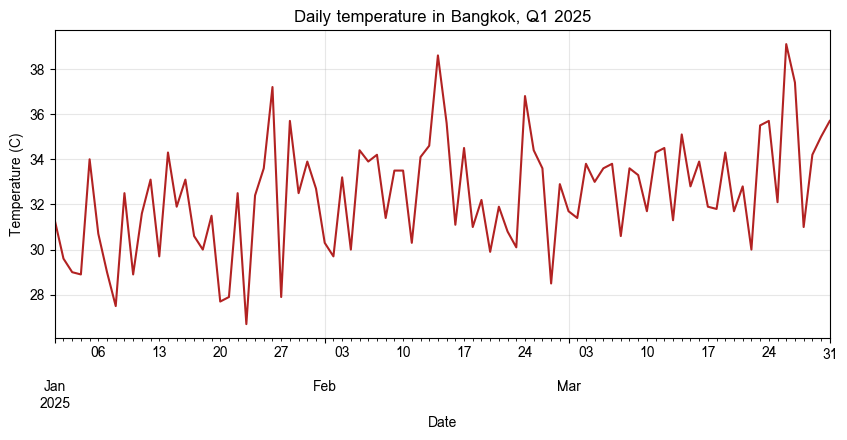

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

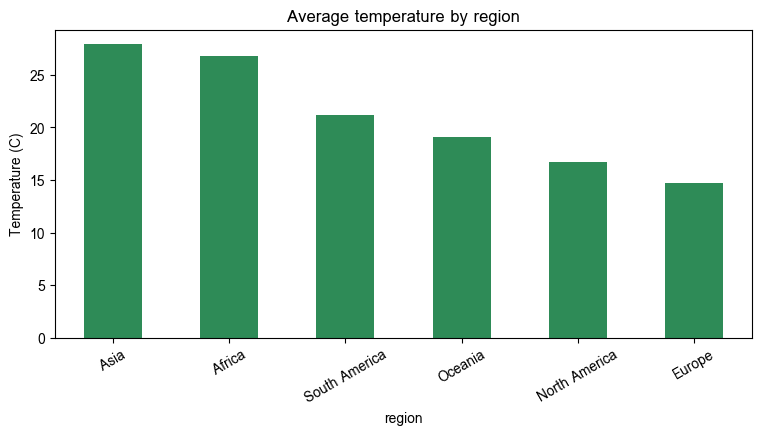

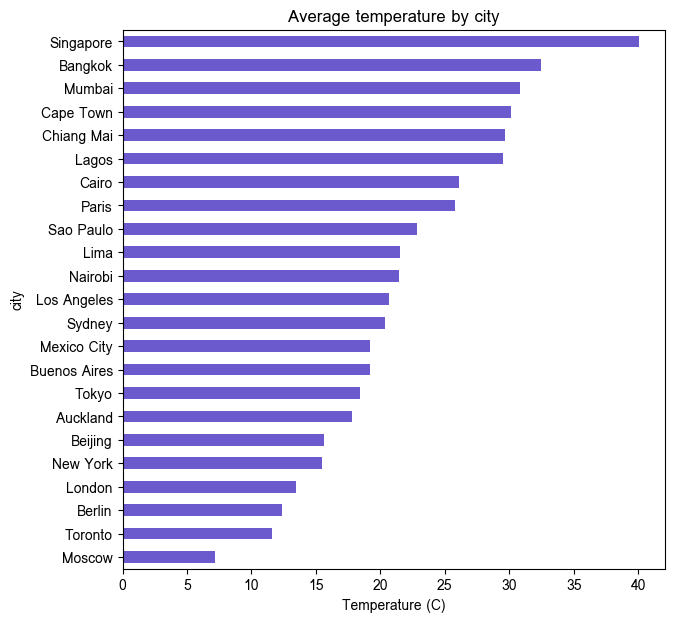

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

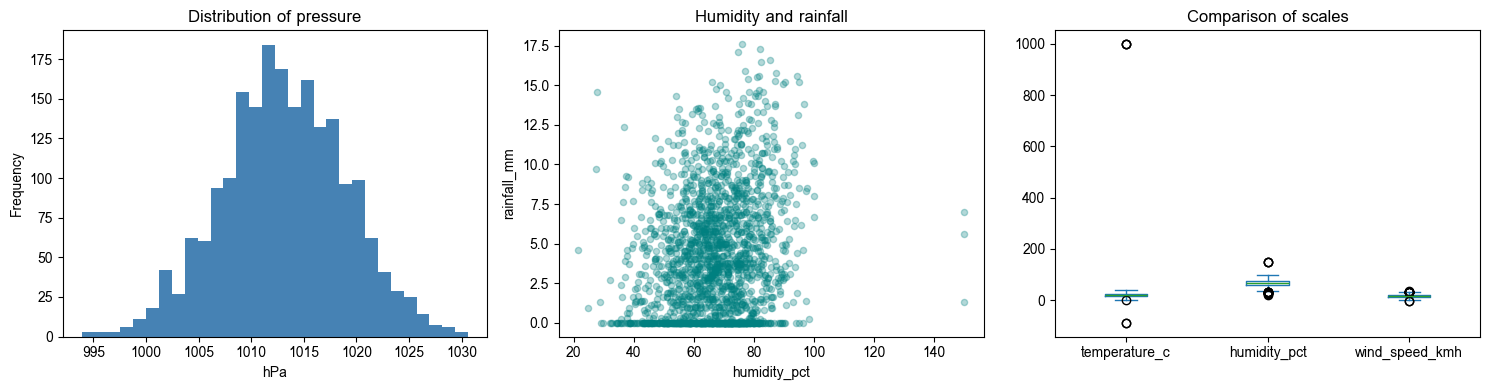

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

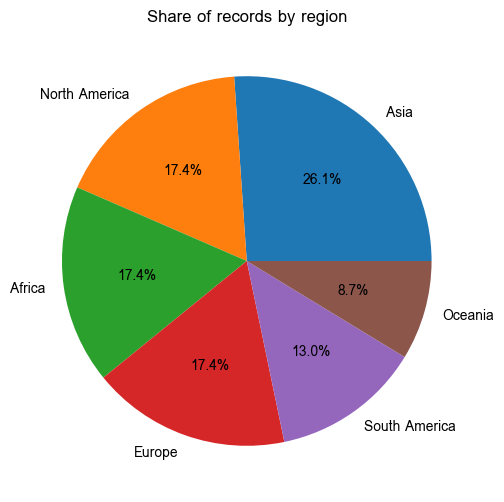

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

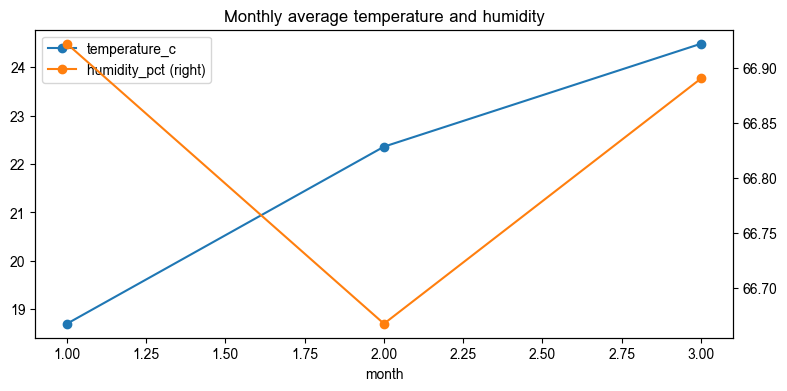

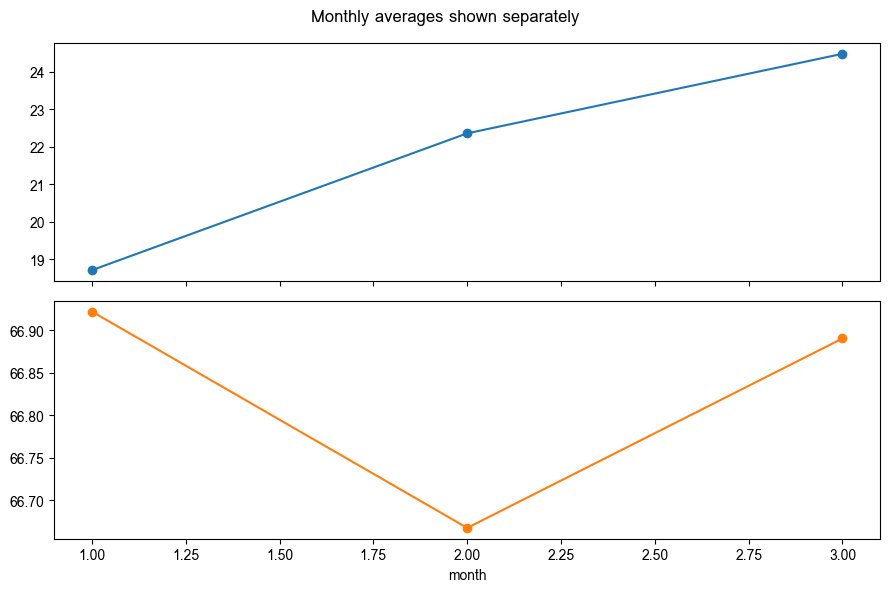

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

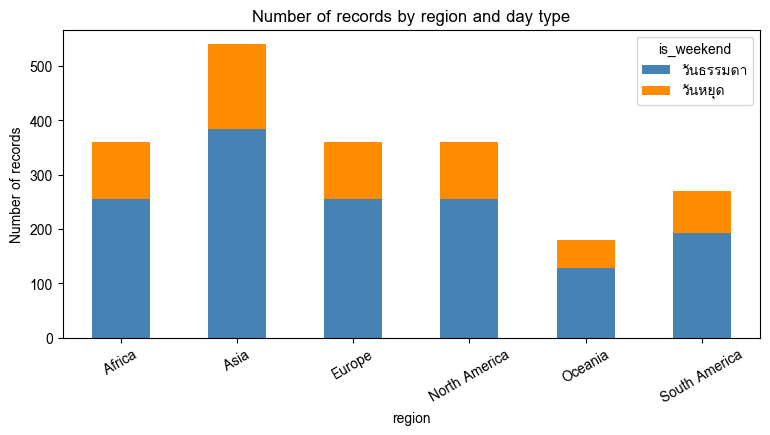

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

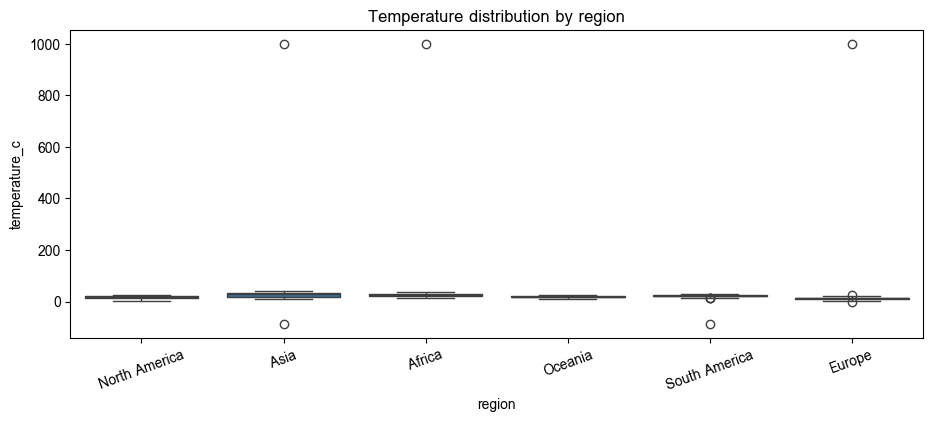

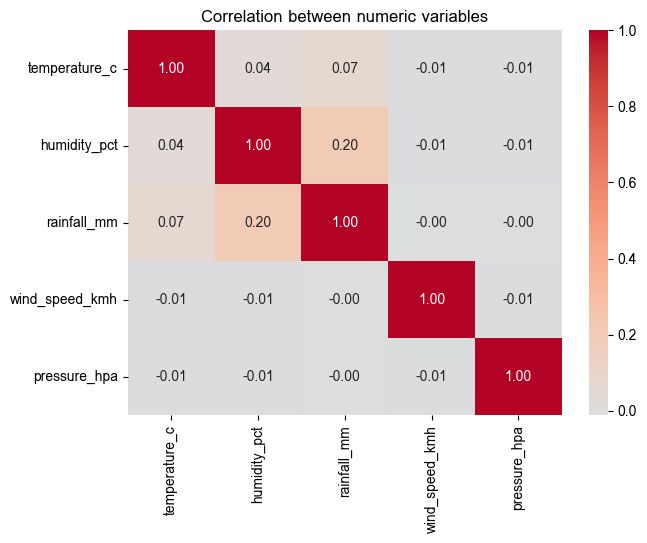

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

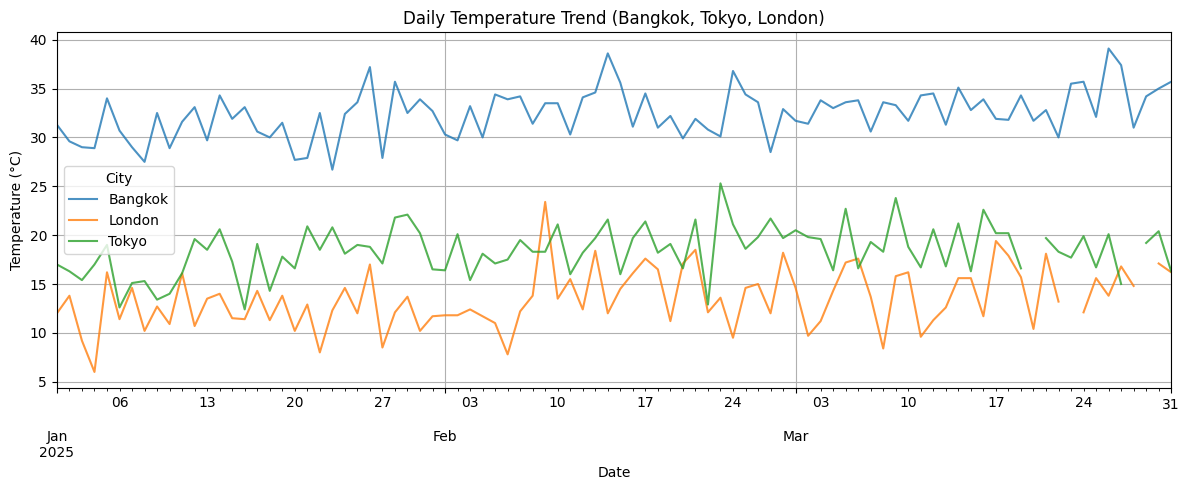

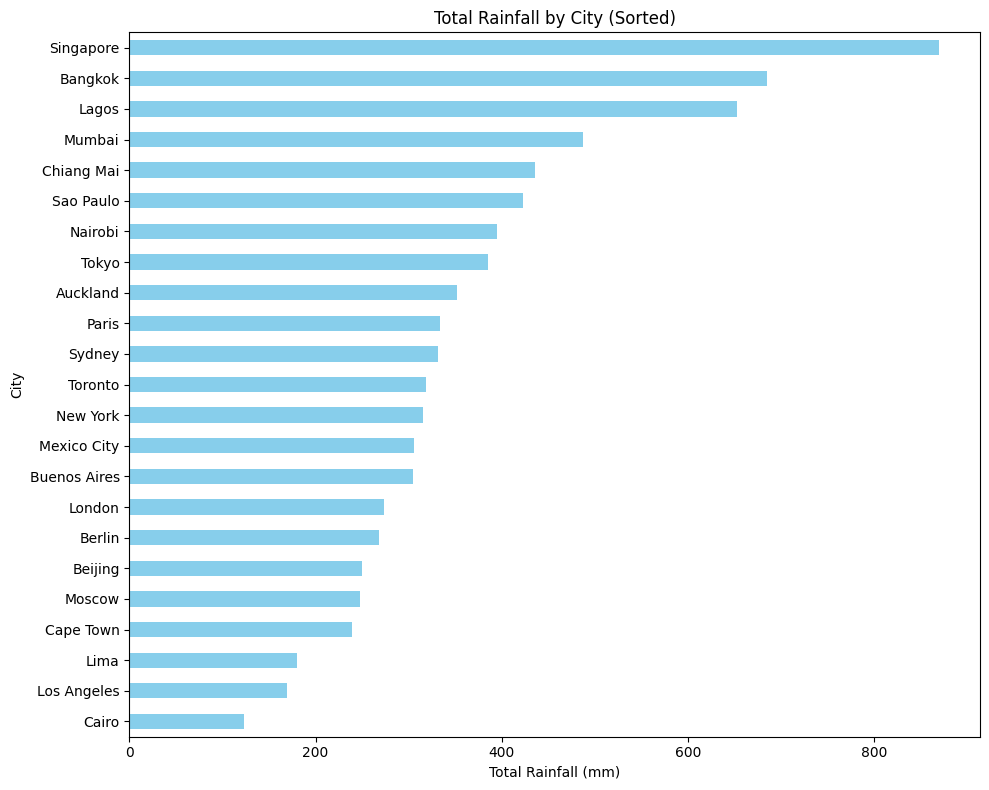

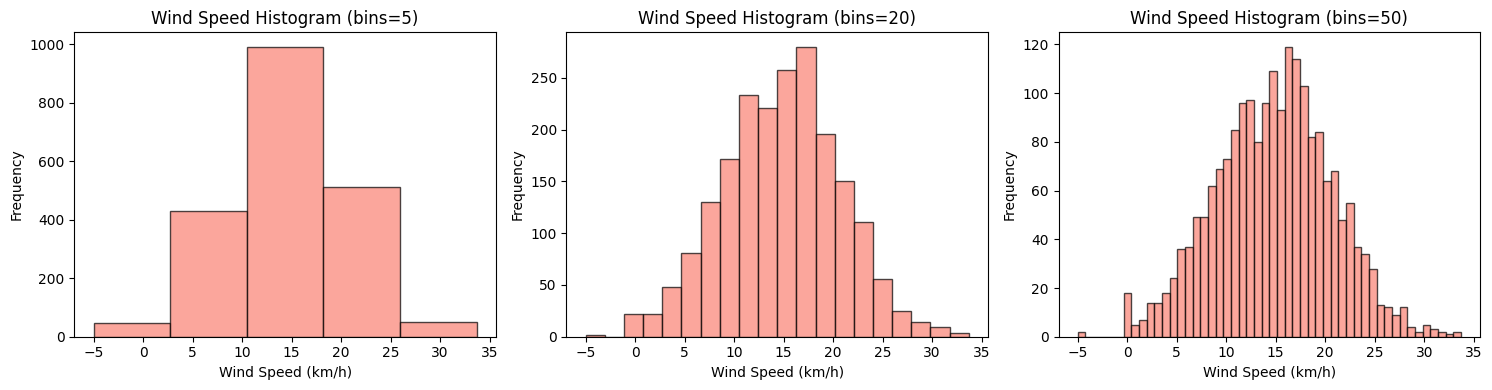


💡 ผลของการเลือก bins:
- bins น้อย (5): กราฟหยาบ เห็นภาพรวม แต่ละแท่งกว้าง อาจซ่อนรายละเอียด
- bins กลาง (20): สมดุล เห็นทั้งรูปร่างและรายละเอียดพอสมควร
- bins มาก (50): กราฟละเอียด แต่อาจมีช่องว่าง และรูปร่างอาจดูไม่ราบรื่น
- เลือก bins ให้เหมาะสมกับจำนวนข้อมูล — ข้อมูลเยอะใช้ bins มากได้ ข้อมูลน้อยใช้ bins น้อยกว่า



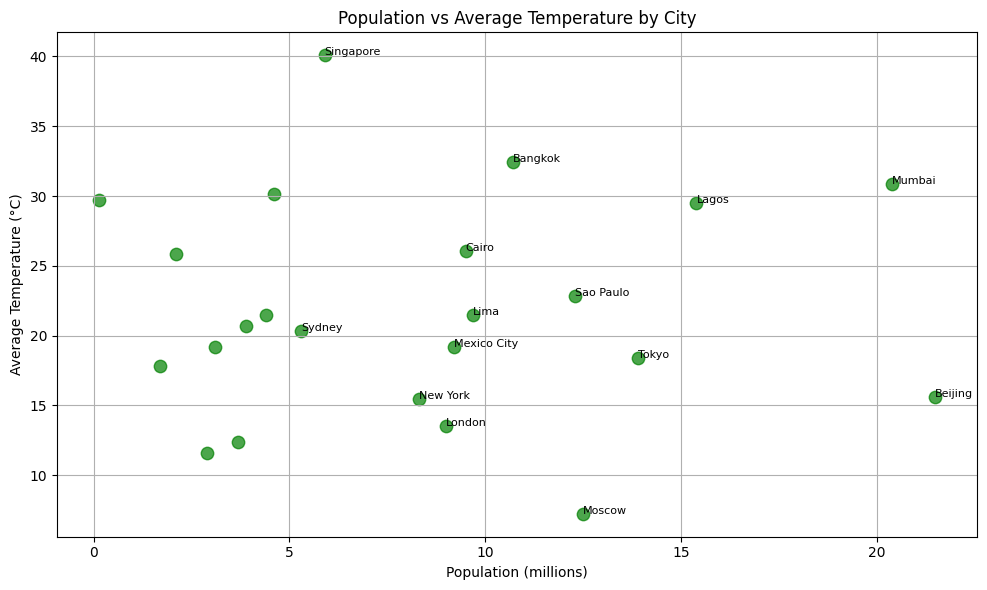

In [26]:
# คำตอบข้อ 17.1
# ==================== คำตอบข้อ 17.1 ====================

import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
df['date'] = pd.to_datetime(df['date'])

# ============================================================
# กราฟที่ 1: กราฟเส้น — แนวโน้มอุณหภูมิรายวันของ 3 เมือง
# ============================================================
# เลือก 3 เมือง: Bangkok, Tokyo, London
cities_3 = ['Bangkok', 'Tokyo', 'London']
df_3cities = df[df['city'].isin(cities_3)]

# pivot ให้ index = วันที่, คอลัมน์ = เมือง, ค่า = อุณหภูมิ
temp_pivot = df_3cities.pivot_table(index='date', columns='city', values='temperature_c')

ax1 = temp_pivot.plot(
    kind='line',
    figsize=(12, 5),
    linewidth=1.5,
    title='Daily Temperature Trend (Bangkok, Tokyo, London)',
    xlabel='Date',
    ylabel='Temperature (°C)',
    grid=True,
    alpha=0.8
)
ax1.legend(title='City')
plt.tight_layout()
plt.show()

# ============================================================
# กราฟที่ 2: กราฟแท่งแนวนอน — ปริมาณฝนรวมรายเมือง (เรียงมาก→น้อย)
# ============================================================
rain_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True)

ax2 = rain_by_city.plot(
    kind='barh',
    figsize=(10, 8),
    color='skyblue',
    title='Total Rainfall by City (Sorted)',
    xlabel='Total Rainfall (mm)',
    ylabel='City'
)
plt.tight_layout()
plt.show()

# ============================================================
# กราฟที่ 3: ฮิสโตแกรม — wind_speed_kmh ทดลอง bins 3 ค่า
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, bins in enumerate([5, 20, 50]):
    df['wind_speed_kmh'].plot(
        kind='hist',
        bins=bins,
        ax=axes[i],
        color='salmon',
        edgecolor='black',
        alpha=0.7,
        title=f'Wind Speed Histogram (bins={bins})'
    )
    axes[i].set_xlabel('Wind Speed (km/h)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("""
💡 ผลของการเลือก bins:
- bins น้อย (5): กราฟหยาบ เห็นภาพรวม แต่ละแท่งกว้าง อาจซ่อนรายละเอียด
- bins กลาง (20): สมดุล เห็นทั้งรูปร่างและรายละเอียดพอสมควร
- bins มาก (50): กราฟละเอียด แต่อาจมีช่องว่าง และรูปร่างอาจดูไม่ราบรื่น
- เลือก bins ให้เหมาะสมกับจำนวนข้อมูล — ข้อมูลเยอะใช้ bins มากได้ ข้อมูลน้อยใช้ bins น้อยกว่า
""")

# ============================================================
# กราฟที่ 4: กราฟจุด — population_millions vs อุณหภูมิเฉลี่ยรายเมือง
# ============================================================
# รวมข้อมูล population จาก city_info
city_avg_temp = df.groupby('city')['temperature_c'].mean().reset_index()
city_merged = pd.merge(city_avg_temp, city_info[['city', 'population_millions']], on='city')

ax4 = city_merged.plot(
    kind='scatter',
    x='population_millions',
    y='temperature_c',
    figsize=(10, 6),
    s=80,  # ขนาดจุด
    alpha=0.7,
    color='green',
    title='Population vs Average Temperature by City',
    xlabel='Population (millions)',
    ylabel='Average Temperature (°C)',
    grid=True
)

# เพิ่มชื่อเมืองลงในจุดกราฟ (สำหรับเมืองที่มีประชากรมาก)
for _, row in city_merged[city_merged['population_millions'] > 5].iterrows():
    ax4.annotate(row['city'], (row['population_millions'], row['temperature_c']), fontsize=8)

plt.tight_layout()
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

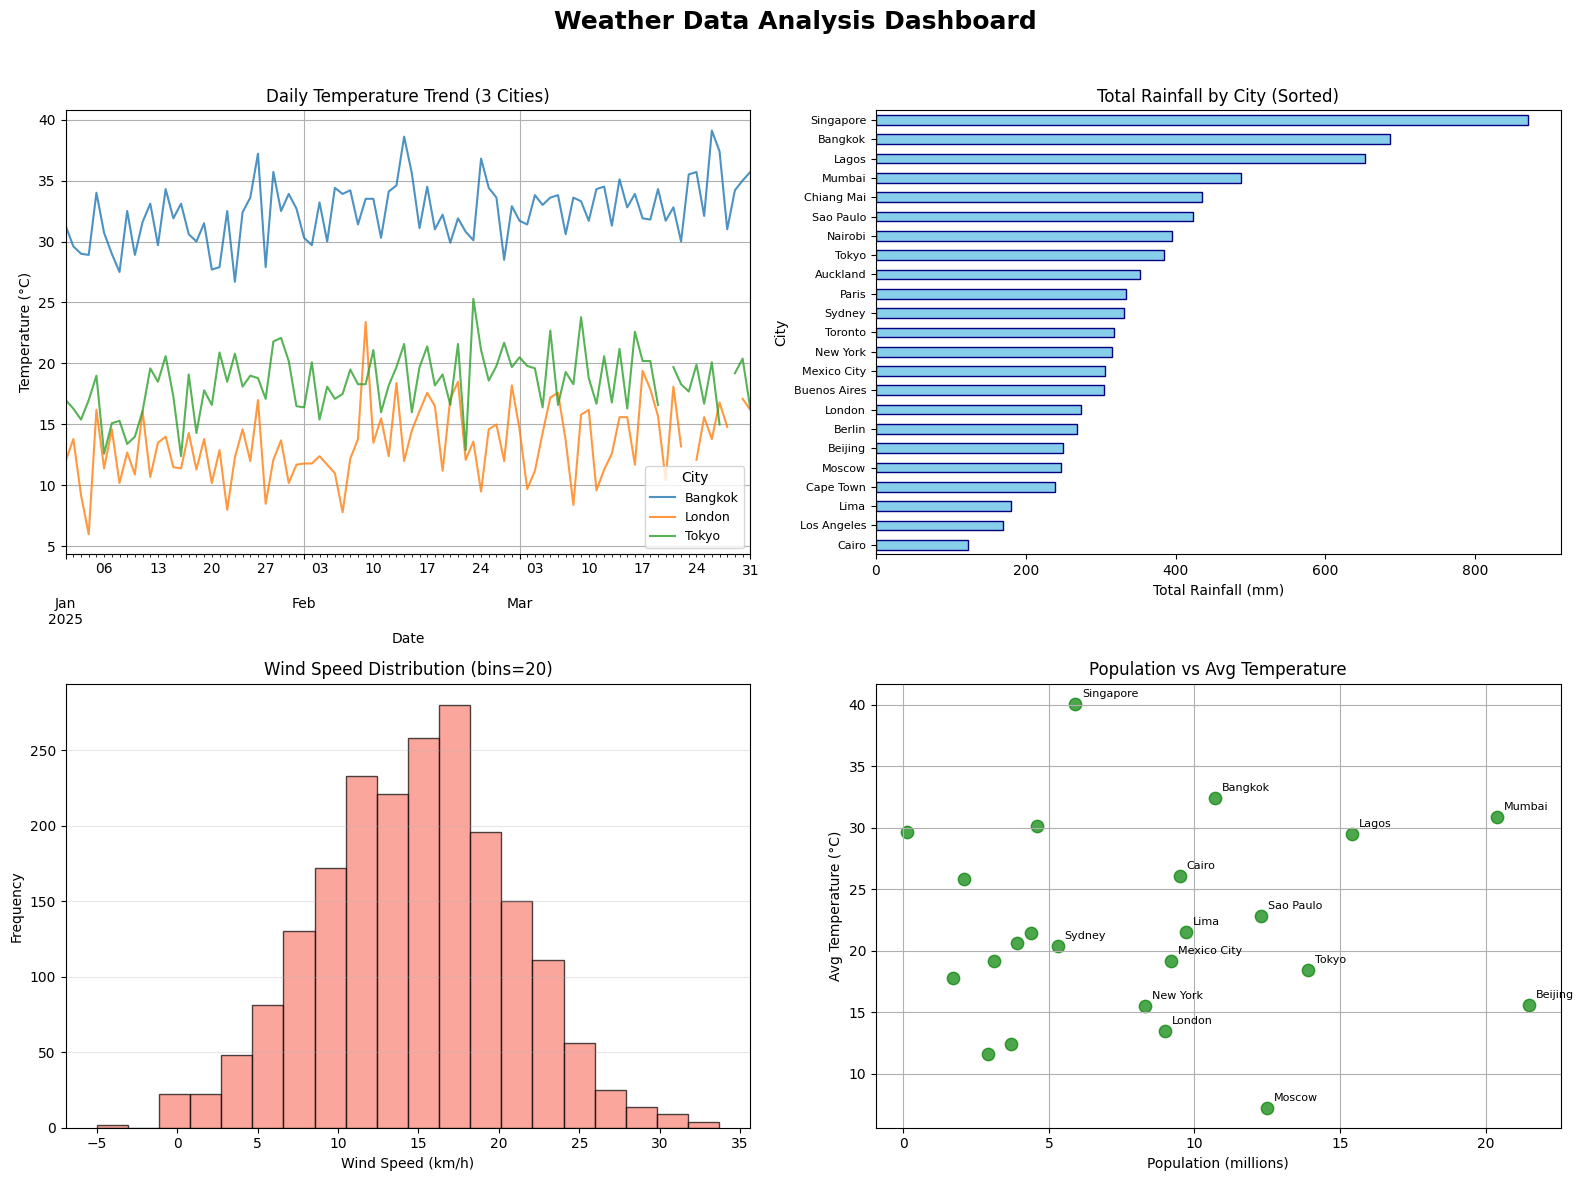

In [27]:
# คำตอบข้อ 17.2
# ==================== คำตอบข้อ 17.2 ====================

import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
df['date'] = pd.to_datetime(df['date'])

# ---------- เตรียมข้อมูลสำหรับแต่ละกราฟ ----------
# กราฟเส้น: อุณหภูมิ 3 เมือง
cities_3 = ['Bangkok', 'Tokyo', 'London']
temp_pivot = df[df['city'].isin(cities_3)].pivot_table(index='date', columns='city', values='temperature_c')

# กราฟแท่ง: ปริมาณฝนรวมรายเมือง
rain_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True)

# กราฟจุด: ประชากร vs อุณหภูมิเฉลี่ย
city_avg_temp = df.groupby('city')['temperature_c'].mean().reset_index()
city_merged = pd.merge(city_avg_temp, city_info[['city', 'population_millions']], on='city')

# ---------- สร้างภาพ 2x2 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ชื่อรวมของภาพทั้งหมด
plt.suptitle('Weather Data Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)

# ============================================================
# กราฟที่ 1 (ซ้ายบน): กราฟเส้น — อุณหภูมิ 3 เมือง
# ============================================================
temp_pivot.plot(
    kind='line',
    ax=axes[0, 0],
    linewidth=1.5,
    alpha=0.8,
    grid=True
)
axes[0, 0].set_title('Daily Temperature Trend (3 Cities)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].legend(title='City', fontsize=9)

# ============================================================
# กราฟที่ 2 (ขวาบน): กราฟแท่งแนวนอน — ปริมาณฝนรายเมือง
# ============================================================
rain_by_city.plot(
    kind='barh',
    ax=axes[0, 1],
    color='skyblue',
    edgecolor='navy'
)
axes[0, 1].set_title('Total Rainfall by City (Sorted)', fontsize=12)
axes[0, 1].set_xlabel('Total Rainfall (mm)')
axes[0, 1].set_ylabel('City')
axes[0, 1].tick_params(axis='y', labelsize=8)

# ============================================================
# กราฟที่ 3 (ซ้ายล่าง): ฮิสโตแกรม — ความเร็วลม (bins=20)
# ============================================================
df['wind_speed_kmh'].plot(
    kind='hist',
    bins=20,
    ax=axes[1, 0],
    color='salmon',
    edgecolor='black',
    alpha=0.7
)
axes[1, 0].set_title('Wind Speed Distribution (bins=20)', fontsize=12)
axes[1, 0].set_xlabel('Wind Speed (km/h)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# ============================================================
# กราฟที่ 4 (ขวาล่าง): กราฟจุด — ประชากร vs อุณหภูมิเฉลี่ย
# ============================================================
city_merged.plot(
    kind='scatter',
    x='population_millions',
    y='temperature_c',
    ax=axes[1, 1],
    s=80,
    alpha=0.7,
    color='green',
    grid=True
)
axes[1, 1].set_title('Population vs Avg Temperature', fontsize=12)
axes[1, 1].set_xlabel('Population (millions)')
axes[1, 1].set_ylabel('Avg Temperature (°C)')

# เพิ่มชื่อเมืองสำหรับจุดที่มีประชากรมาก
for _, row in city_merged[city_merged['population_millions'] > 5].iterrows():
    axes[1, 1].annotate(row['city'],
                       (row['population_millions'], row['temperature_c']),
                       fontsize=8, xytext=(5, 5), textcoords='offset points')

# ---------- ปรับ layout ให้สวยงาม ----------
plt.tight_layout(rect=[0, 0, 1, 0.96])  # เว้นที่สำหรับ suptitle
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

📊 ตารางจำนวนวันในแต่ละช่วงฝน จำแนกตามภูมิภาค


region,Africa,Asia,Europe,North America,Oceania,South America
rain_group,,,,,,
No Rain (0),101,59,106,92,35,76
Light (0-5),131,174,157,161,68,114
Moderate (5-20),119,295,88,95,69,73


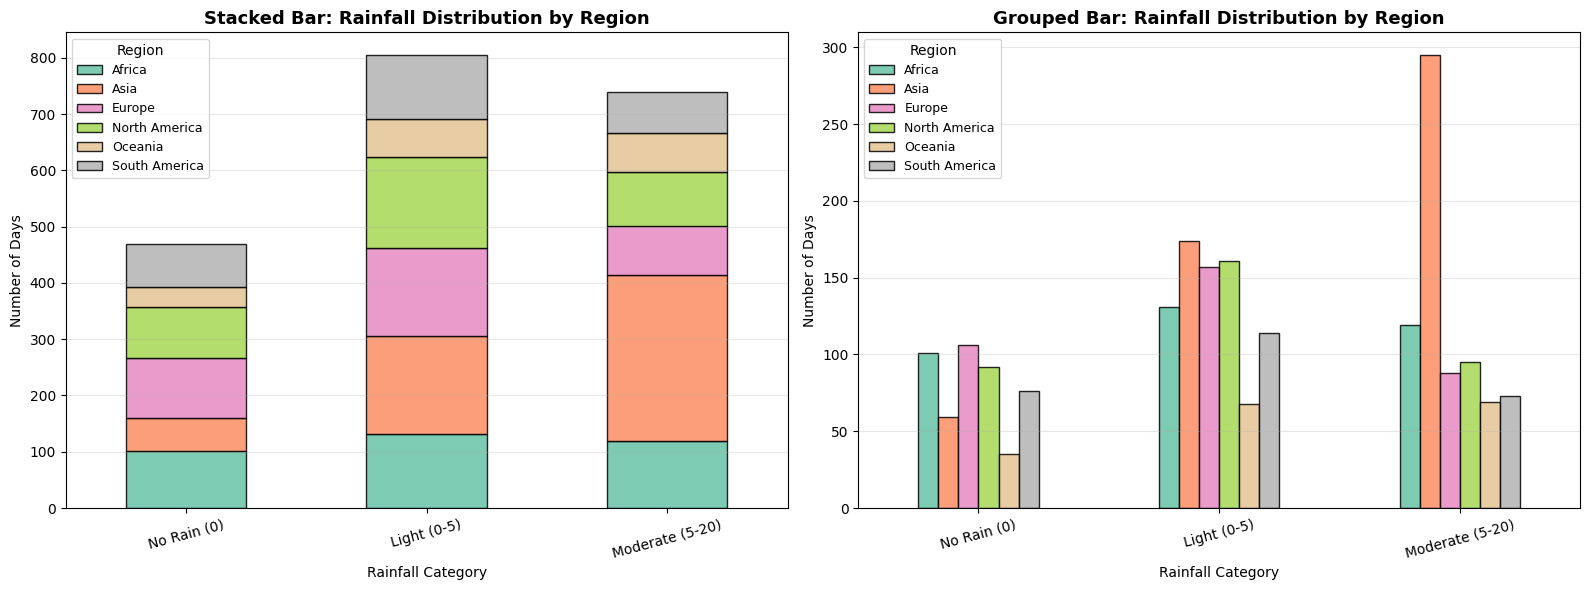

💡 กราฟแท่งซ้อน vs กราฟแท่งเรียงข้างกัน — เหมาะสมเมื่อไหร่

กราฟแท่งซ้อน (Stacked Bar) — เหมาะกว่าเมื่อ:
✅ ต้องการดูยอดรวมทั้งหมดของแต่ละหมวด (ความสูงทั้งแท่ง)
✅ ต้องการดูสัดส่วนของแต่ละกลุ่มภายในหมวดนั้นๆ
✅ ต้องการเปรียบเทียบสัดส่วนข้ามหมวด (เช่น ในช่วงฝนหนัก ภูมิภาคใดมีส่วนมากที่สุด)
✅ จำนวนกลุ่มไม่มากเกินไป (ถ้ามากเกินไปจะอ่านยาก)

กราฟแท่งเรียงข้างกัน (Grouped Bar) — เหมาะกว่าเมื่อ:
✅ ต้องการเปรียบเทียบค่าแต่ละกลุ่มในแต่ละหมวดได้ชัดเจน (ความสูงเทียบกันได้ง่าย)
✅ ต้องการดูความแตกต่างของค่าที่แน่นอน ไม่ใช่แค่สัดส่วน
✅ มีกลุ่มจำนวนมาก หรือค่าแต่ละกลุ่มต่างกันมาก (ซ้อนกันจะอ่านยาก)
✅ ต้องการเปรียบเทียบค่าในระดับละเอียด เช่น เปรียบเทียบจำนวนวันฝนหนักของเอเชียกับยุโรป

สรุป:
- Stacked = ดูภาพรวม + สัดส่วน
- Grouped = เปรียบเทียบค่าแต่ละกลุ่มได้ชัดเจน



In [28]:
# คำตอบข้อ 17.3
# ==================== คำตอบข้อ 17.3 ====================

import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ขั้นที่ 1: แบ่งช่วงปริมาณฝนด้วย pd.cut() ----------
rain_bins = [-0.1, 0, 5, 20, float('inf')]
rain_labels = ['No Rain (0)', 'Light (0-5)', 'Moderate (5-20)', 'Heavy (>20)']

df['rain_group'] = pd.cut(
    df['rainfall_mm'],
    bins=rain_bins,
    labels=rain_labels
)

# ---------- ขั้นที่ 2: สร้างตารางสรุป — จำนวนวันในแต่ละช่วงฝน จำแนกตามภูมิภาค ----------
rain_by_region = pd.crosstab(df['rain_group'], df['region'])

print("=" * 70)
print("📊 ตารางจำนวนวันในแต่ละช่วงฝน จำแนกตามภูมิภาค")
print("=" * 70)
display(rain_by_region)
print()

# ---------- ขั้นที่ 3: สร้างกราฟเปรียบเทียบทั้งสองแบบ ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟซ้าย: Stacked Bar (แท่งซ้อน)
rain_by_region.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title('Stacked Bar: Rainfall Distribution by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rainfall Category')
axes[0].set_ylabel('Number of Days')
axes[0].legend(title='Region', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# กราฟขวา: Grouped Bar (แท่งเรียงข้างกัน — stacked=False)
rain_by_region.plot(
    kind='bar',
    stacked=False,
    ax=axes[1],
    colormap='Set2',
    edgecolor='black',
    alpha=0.85
)
axes[1].set_title('Grouped Bar: Rainfall Distribution by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rainfall Category')
axes[1].set_ylabel('Number of Days')
axes[1].legend(title='Region', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 4: อธิบายการเลือกใช้ ----------
print("=" * 70)
print("💡 กราฟแท่งซ้อน vs กราฟแท่งเรียงข้างกัน — เหมาะสมเมื่อไหร่")
print("=" * 70)
print("""
กราฟแท่งซ้อน (Stacked Bar) — เหมาะกว่าเมื่อ:
✅ ต้องการดูยอดรวมทั้งหมดของแต่ละหมวด (ความสูงทั้งแท่ง)
✅ ต้องการดูสัดส่วนของแต่ละกลุ่มภายในหมวดนั้นๆ
✅ ต้องการเปรียบเทียบสัดส่วนข้ามหมวด (เช่น ในช่วงฝนหนัก ภูมิภาคใดมีส่วนมากที่สุด)
✅ จำนวนกลุ่มไม่มากเกินไป (ถ้ามากเกินไปจะอ่านยาก)

กราฟแท่งเรียงข้างกัน (Grouped Bar) — เหมาะกว่าเมื่อ:
✅ ต้องการเปรียบเทียบค่าแต่ละกลุ่มในแต่ละหมวดได้ชัดเจน (ความสูงเทียบกันได้ง่าย)
✅ ต้องการดูความแตกต่างของค่าที่แน่นอน ไม่ใช่แค่สัดส่วน
✅ มีกลุ่มจำนวนมาก หรือค่าแต่ละกลุ่มต่างกันมาก (ซ้อนกันจะอ่านยาก)
✅ ต้องการเปรียบเทียบค่าในระดับละเอียด เช่น เปรียบเทียบจำนวนวันฝนหนักของเอเชียกับยุโรป

สรุป:
- Stacked = ดูภาพรวม + สัดส่วน
- Grouped = เปรียบเทียบค่าแต่ละกลุ่มได้ชัดเจน
""")

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

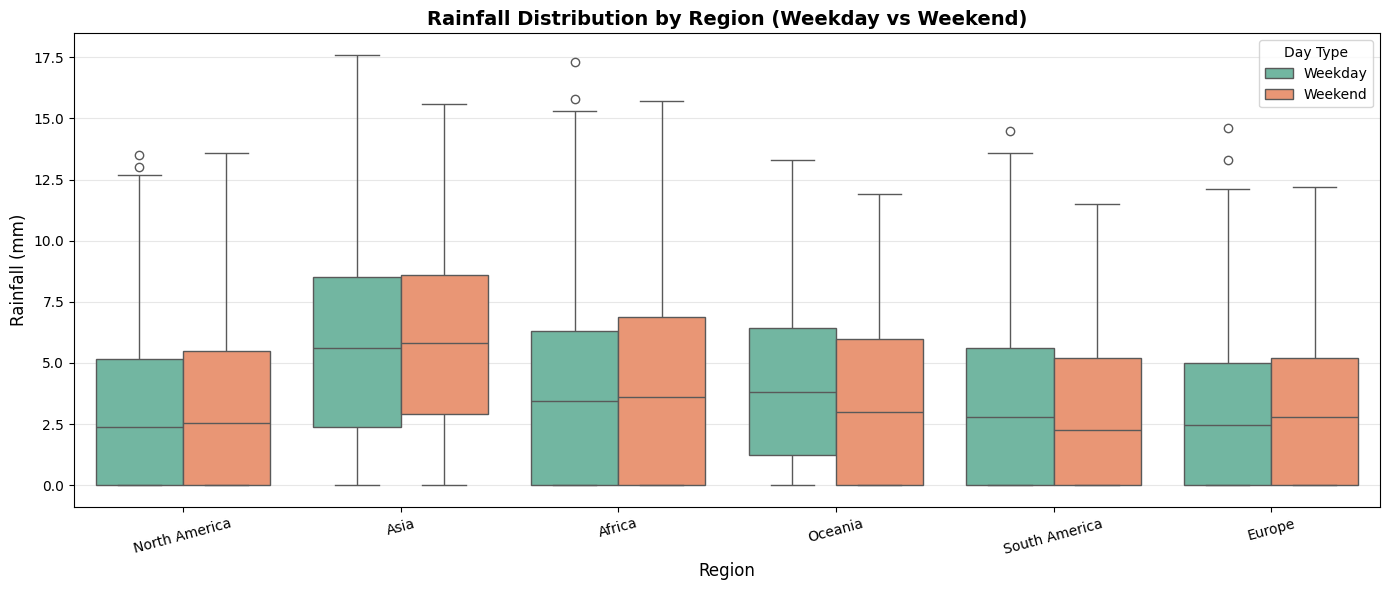

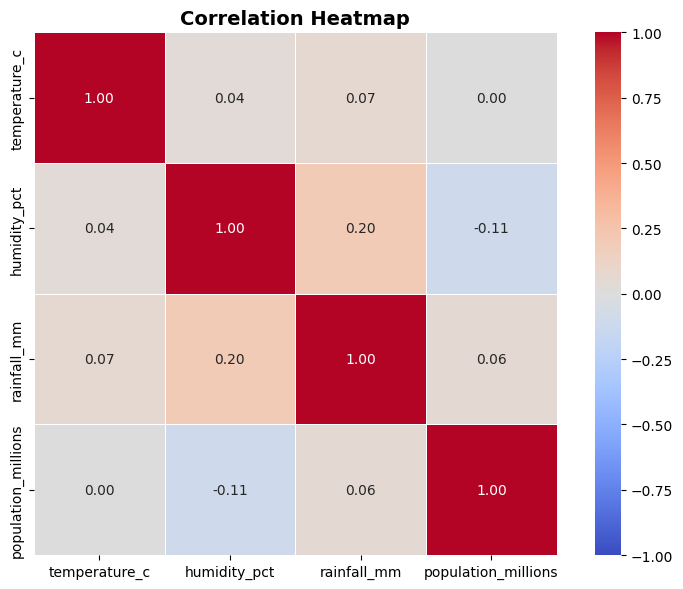

📝 ตีความผลจากกราฟ

จาก Boxplot (ปริมาณฝนตามภูมิภาค):
- ภูมิภาคที่มีค่ากลาง (median) ของฝนสูงที่สุด น่าจะเป็น Asia หรือภูมิภาคเขตร้อน
- ภูมิภาคที่ฝนน้อยที่สุด น่าจะเป็น Africa (มีสะหวันน้ำแล้ง) หรือ Europe
- outlier (จุดที่อยู่เหนือ whisker) แสดงวันฝนตกหนักผิดปกติ
- เปรียบเทียบ Weekday vs Weekend: ถ้าค่าเฉลี่ย/ค่ากลางใกล้เคียงกัน แสดงว่าการฝนตกไม่ขึ้นกับวันในสัปดาห์ (เป็นเรื่องธรรมชาติ ไม่มีผลจากมนุษย์)

จาก Heatmap (สหสัมพันธ์):
- temperature_c กับ humidity_pct: มักมีสัมพันธ์เชิงบวก (อากาศร้อน → ความชื้นสูง) หรืออาจเป็นลบขึ้นอยู่กับภูมิภาค
- humidity_pct กับ rainfall_mm: มักมีสัมพันธ์เชิงบวก (ความชื้นสูง → มีโอกาสฝนตกมากกว่า)
- temperature_c กับ population_millions: อาจมีสัมพันธ์เชิงบวกเล็กน้อย (เมืองใหญ่มักอยู่ในเขตร้อน) หรือไม่มีสัมพันธ์
- ค่าสหสัมพันธ์ใกล้ 0 = ไม่มีความสัมพันธ์ เช่น population กับปริมาณฝน (ขนาดเมืองไม่เกี่ยวกับฝน)

หมายเหตุ: ค่าสหสัมพันธ์ไม่ได้หมายความว่าเป็นสาเหตุ-ผลลัพธ์ แค่บอกว่าเคลื่อนไหวไปพร้อมกันหรือไม่

📊 ค่าสหสัมพันธ์ (ตัวเลข):
                     temperatu

In [29]:
# คำตอบข้อ 17.4
# ==================== คำตอบข้อ 17.4 ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
df['date'] = pd.to_datetime(df['date'])

# สร้างคอลัมน์ is_weekend
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df['is_weekend'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# รวม population_millions จาก city_info
df = pd.merge(df, city_info[['city', 'population_millions']], on='city', how='left')

# ---------- กราฟที่ 1: Boxplot — rainfall_mm จำแนกตามภูมิภาค แยกสีตาม is_weekend ----------
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df,
    x='region',
    y='rainfall_mm',
    hue='is_weekend',
    palette='Set2',
    linewidth=1
)
plt.title('Rainfall Distribution by Region (Weekday vs Weekend)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Day Type', fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- กราฟที่ 2: Heatmap — สหสัมพันธ์ระหว่าง 4 ตัวแปร ----------
corr_vars = ['temperature_c', 'humidity_pct', 'rainfall_mm', 'population_millions']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,        # แสดงค่าตัวเลขในช่อง
    cmap='coolwarm',   # สี: แดง = บวก, น้ำเงิน = ลบ
    vmin=-1, vmax=1,   # ขอบเขตค่าสหสัมพันธ์
    center=0,
    square=True,
    linewidths=0.5,
    fmt='.2f'
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- ตีความผล ----------
print("=" * 70)
print("📝 ตีความผลจากกราฟ")
print("=" * 70)
print("""
จาก Boxplot (ปริมาณฝนตามภูมิภาค):
- ภูมิภาคที่มีค่ากลาง (median) ของฝนสูงที่สุด น่าจะเป็น Asia หรือภูมิภาคเขตร้อน
- ภูมิภาคที่ฝนน้อยที่สุด น่าจะเป็น Africa (มีสะหวันน้ำแล้ง) หรือ Europe
- outlier (จุดที่อยู่เหนือ whisker) แสดงวันฝนตกหนักผิดปกติ
- เปรียบเทียบ Weekday vs Weekend: ถ้าค่าเฉลี่ย/ค่ากลางใกล้เคียงกัน แสดงว่าการฝนตกไม่ขึ้นกับวันในสัปดาห์ (เป็นเรื่องธรรมชาติ ไม่มีผลจากมนุษย์)

จาก Heatmap (สหสัมพันธ์):
- temperature_c กับ humidity_pct: มักมีสัมพันธ์เชิงบวก (อากาศร้อน → ความชื้นสูง) หรืออาจเป็นลบขึ้นอยู่กับภูมิภาค
- humidity_pct กับ rainfall_mm: มักมีสัมพันธ์เชิงบวก (ความชื้นสูง → มีโอกาสฝนตกมากกว่า)
- temperature_c กับ population_millions: อาจมีสัมพันธ์เชิงบวกเล็กน้อย (เมืองใหญ่มักอยู่ในเขตร้อน) หรือไม่มีสัมพันธ์
- ค่าสหสัมพันธ์ใกล้ 0 = ไม่มีความสัมพันธ์ เช่น population กับปริมาณฝน (ขนาดเมืองไม่เกี่ยวกับฝน)

หมายเหตุ: ค่าสหสัมพันธ์ไม่ได้หมายความว่าเป็นสาเหตุ-ผลลัพธ์ แค่บอกว่าเคลื่อนไหวไปพร้อมกันหรือไม่
""")

# แสดงค่าสหสัมพันธ์เป็นตัวเลข
print("=" * 70)
print("📊 ค่าสหสัมพันธ์ (ตัวเลข):")
print("=" * 70)
print(corr_matrix.round(2).to_string())

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

ข้อมูลเดิม: 2075 แถว → หลังทำความสะอาด: 2050 แถว
วิธีจัดการ: ลบค่าว่างของอุณหภูมิ + กรองค่าผิดปกติ (นอกช่วง -60 ถึง 60°C)

📊 ตาราง: ส่วนเบี่ยงเบนมาตรฐานอุณหภูมิ จำแนกตามภูมิภาค


,std_temp,mean_temp,n_days
region,,,
Asia,7.16,26.33,537
Africa,4.88,24.02,354
North America,4.52,16.75,357
Europe,4.06,11.94,355
Oceania,3.08,19.08,180
South America,3.06,21.58,267


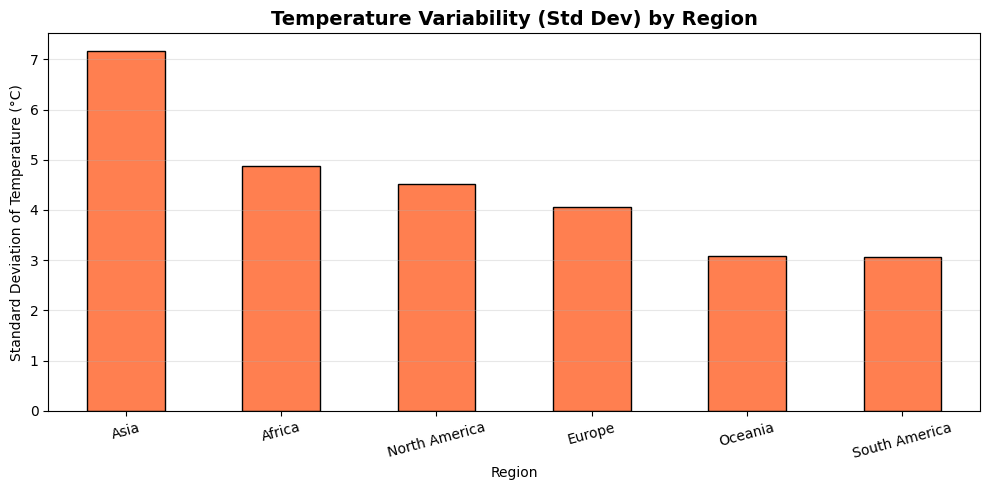

🔍 ตาราง: ความแปรปรวนแยกตามเมืองในภูมิภาค 'Asia'


,std_temp,mean_temp,n_days
city,,,
Beijing,2.87,15.60,89
Chiang Mai,2.86,29.68,91
Singapore,2.71,30.64,88
Mumbai,2.54,30.87,90
Tokyo,2.52,18.41,88
Bangkok,2.48,32.45,91


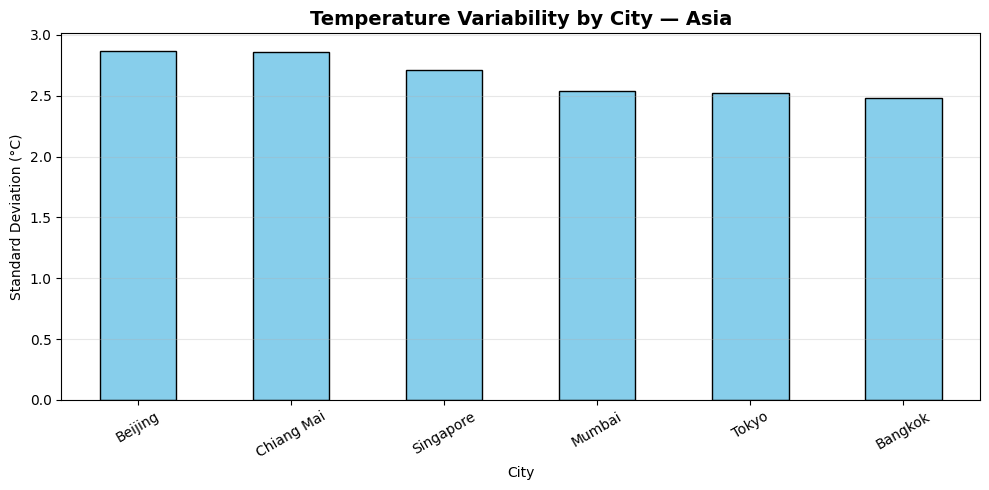

📝 ข้อสรุป

1. ภูมิภาคที่มีสภาพอากาศแปรปรวนมากที่สุดคือ: Asia
   (ส่วนเบี่ยงเบนมาสูตรฐาน = 7.16 °C)

2. ความแปรปรวนเกิดจาก:
   - เมืองที่มีความแปรปรวนสูงสุด: Beijing (std = 2.87 °C)
   - เมืองที่มีความแปรปรวนต่ำสุด: Bangkok (std = 2.48 °C)
   - อัตราส่วนสูงสุด/ต่ำสุด: 1.2 เท่า

3. สรุป: ความแปรปรวนกระจายอยู่ทั่วทุกเมืองในภูมิภาค (อัตราส่วนใกล้เคียงกัน)

4. วิธีจัดการข้อมูล: ลบแถวที่อุณหภูมิเป็นค่าว่าง และกรองค่าผิดปกติที่นอกช่วง -60 ถึง 60°C ก่อนคำนวณ



In [30]:
# คำตอบข้อ 18.1
# ==================== ข้อ 18.1 — ภูมิภาคที่มีสภาพอากาศแปรปรวนมากที่สุด ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- ขั้นที่ 1: โหลดและรวมข้อมูลทั้ง 3 แหล่ง ----------
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")[['city', 'population_millions', 'timezone']]
region_info = pd.read_csv(BASE + "region_info.csv")[['region', 'continent_code']]

# รวมตาราง (left join รักษาจำนวนแถวเดิม)
df = pd.merge(df, city_info, on='city', how='left')
df = pd.merge(df, region_info, on='region', how='left')

# ---------- ขั้นที่ 2: ทำความสะอาดข้อมูล ----------
# วิธีจัดการค่าว่าง: ลบแถวที่อุณหภูมิเป็นค่าว่าง (dropna) ก่อนคำนวณ
# วิธีจัดการค่าผิดปกติ: กรองเฉพาะอุณหภูมิที่อยู่ในช่วง -60 ถึง 60 องศาเซลเซียส
df_clean = df.dropna(subset=['temperature_c'])
df_clean = df_clean[df_clean['temperature_c'].between(-60, 60)]

print(f"ข้อมูลเดิม: {len(df)} แถว → หลังทำความสะอาด: {len(df_clean)} แถว")
print(f"วิธีจัดการ: ลบค่าว่างของอุณหภูมิ + กรองค่าผิดปกติ (นอกช่วง -60 ถึง 60°C)")
print()

# ---------- ขั้นที่ 3: คำนวณส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิ จำแนกตามภูมิภาค ----------
region_std = df_clean.groupby('region')['temperature_c'].agg(['std', 'mean', 'count']).round(2)
region_std.columns = ['std_temp', 'mean_temp', 'n_days']
region_std = region_std.sort_values('std_temp', ascending=False)

most_variable_region = region_std.index[0]

print("=" * 70)
print("📊 ตาราง: ส่วนเบี่ยงเบนมาตรฐานอุณหภูมิ จำแนกตามภูมิภาค")
print("=" * 70)
display(region_std)
print()

# ---------- ขั้นที่ 4: กราฟเปรียบเทียบความแปรปรวน ----------
plt.figure(figsize=(10, 5))
region_std['std_temp'].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Temperature Variability (Std Dev) by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Standard Deviation of Temperature (°C)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 5: สำรวจภูมิภาคที่แปรปรวนมากที่สุด — แยกตามเมือง ----------
top_region_data = df_clean[df_clean['region'] == most_variable_region]
city_std = top_region_data.groupby('city')['temperature_c'].agg(['std', 'mean', 'count']).round(2)
city_std.columns = ['std_temp', 'mean_temp', 'n_days']
city_std = city_std.sort_values('std_temp', ascending=False)

print("=" * 70)
print(f"🔍 ตาราง: ความแปรปรวนแยกตามเมืองในภูมิภาค '{most_variable_region}'")
print("=" * 70)
display(city_std)
print()

# กราฟเปรียบเทียบเมืองในภูมิภาคนั้น
plt.figure(figsize=(10, 5))
city_std['std_temp'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Temperature Variability by City — {most_variable_region}', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Standard Deviation (°C)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 6: ข้อสรุป ----------
print("=" * 70)
print("📝 ข้อสรุป")
print("=" * 70)
max_city_std = city_std['std_temp'].max()
min_city_std = city_std['std_temp'].min()
ratio = max_city_std / min_city_std if min_city_std > 0 else float('inf')

print(f"""
1. ภูมิภาคที่มีสภาพอากาศแปรปรวนมากที่สุดคือ: {most_variable_region}
   (ส่วนเบี่ยงเบนมาสูตรฐาน = {region_std.loc[most_variable_region, 'std_temp']} °C)

2. ความแปรปรวนเกิดจาก:
   - เมืองที่มีความแปรปรวนสูงสุด: {city_std.index[0]} (std = {max_city_std} °C)
   - เมืองที่มีความแปรปรวนต่ำสุด: {city_std.index[-1]} (std = {min_city_std} °C)
   - อัตราส่วนสูงสุด/ต่ำสุด: {ratio:.1f} เท่า

3. สรุป: {'ความแปรปรวนเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก (อัตราส่วน > 2 เท่า)' if ratio > 2 else 'ความแปรปรวนกระจายอยู่ทั่วทุกเมืองในภูมิภาค (อัตราส่วนใกล้เคียงกัน)'}

4. วิธีจัดการข้อมูล: ลบแถวที่อุณหภูมิเป็นค่าว่าง และกรองค่าผิดปกติที่นอกช่วง -60 ถึง 60°C ก่อนคำนวณ
""")

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

📊 ตารางเปรียบเทียบ: 5 อันดับเมืองฝนตกหนัก

🔹 วัดด้วยจำนวนวัน (สัมบูรณ์):
เมือง (เรียงตามจำนวนวัน)
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9

🔹 วัดด้วยสัดส่วน (ร้อยละต่อจำนวนวันที่มีข้อมูล):
city
Singapore     48.89
Bangkok       26.14
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.47

เมืองที่ปรากฏในทั้งสองอันดับ: ['Bangkok', 'Lagos', 'Sao Paulo', 'Singapore']
อยู่ในอันดับจำนวนวันเท่านั้น: ['Buenos Aires']
อยู่ในอันดับสัดส่วนเท่านั้น: ['Chiang Mai']



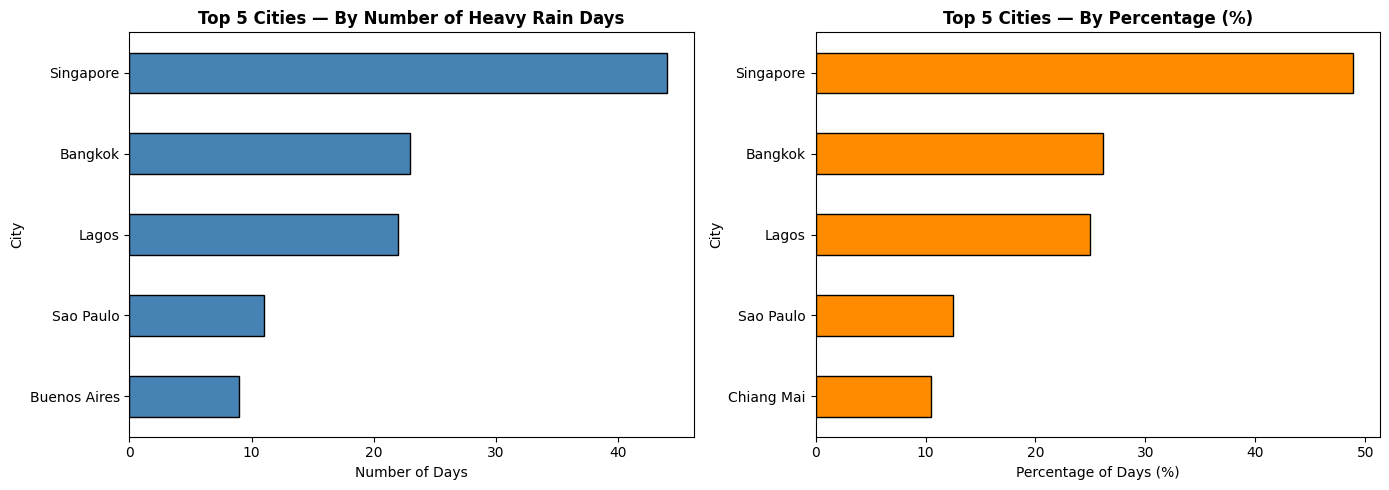

📝 ข้อสรุป

1. เมืองที่ฝนตกหนักบ่อยที่สุด 5 อันดับ:
   - วัดด้วยจำนวนวัน: ['Singapore', 'Bangkok', 'Lagos', 'Sao Paulo', 'Buenos Aires']
   - วัดด้วยสัดส่วน: ['Singapore', 'Bangkok', 'Lagos', 'Sao Paulo', 'Chiang Mai']

2. เหตุใดผลจึงต่างกัน:
   - จำนวนวันแบบสัมบูรณ์ได้รับผลจากจำนวนวันที่มีข้อมูล — เมืองที่มีข้อมูลครบทุกวันมีโอกาสนับได้มากกว่า
   - สัดส่วน (ร้อยละ) ปรับตามจำนวนวันที่มีข้อมูลจริง — เปรียบเทียบได้ยุติธรรมแม้ข้อมูลจะขาดหายต่างกัน
   - เมืองที่มีข้อมูลน้อยอาจมีจำนวนวันฝนหนักน้อย (สัมบูรณ์ต่ำ) แต่สัดส่วนอาจสูงมาก

3. วิธีจัดการข้อมูล: ลบแถวที่ปริมาณฝนเป็นค่าว่าง และกรองค่าผิดปกติ (ฝนติดลบ) ก่อนคำนวณ
   กำหนดฝนตกหนัก = ฝน > 10 มม.

4. สรุป: สัดส่วน (ร้อยละ) เหมาะสมกว่าในการเปรียบเทียบระหว่างเมืองที่จำนวนวันที่มีข้อมูลต่างกัน



In [31]:
# คำตอบข้อ 18.2
# ==================== ข้อ 18.2 — เมืองฝนตกหนักบ่อยที่สุด 5 อันดับ ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- ขั้นที่ 1: โหลดและทำความสะอาดข้อมูล ----------
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")

# วิธีจัดการ: ลบค่าว่างของปริมาณฝน + กรองค่าผิดปกติ (ฝนติดลบไม่มีได้)
df_clean = df.dropna(subset=['rainfall_mm'])
df_clean = df_clean[df_clean['rainfall_mm'] >= 0]

# กำหนด "ฝนตกหนัก" = ฝน > 10 มม.
HEAVY_RAIN_THRESHOLD = 10

# ---------- ขั้นที่ 2: คำนวณทั้งสองวิธี ----------
city_rain = df_clean.groupby('city').agg(
    heavy_rain_days=('rainfall_mm', lambda x: (x > HEAVY_RAIN_THRESHOLD).sum()),
    total_days=('rainfall_mm', 'count')
)
city_rain['heavy_rain_pct'] = (city_rain['heavy_rain_days'] / city_rain['total_days'] * 100).round(2)

# 5 อันดับแรก — วัดด้วยจำนวนวัน (สัมบูรณ์)
top5_by_count = city_rain['heavy_rain_days'].nlargest(5)

# 5 อันดับแรก — วัดด้วยสัดส่วน (ร้อยละ)
top5_by_pct = city_rain['heavy_rain_pct'].nlargest(5)

# ---------- ขั้นที่ 3: ตารางเปรียบเทียบ ----------
comparison = pd.DataFrame({
    'จำนวนวันฝนหนัก': top5_by_count,
    'อันดับ (จำนวนวัน)': range(1, 6),
    'สัดส่วน (%)': city_rain.loc[top5_by_count.index, 'heavy_rain_pct'],
}, index=top5_by_count.index)
comparison.index.name = 'เมือง (เรียงตามจำนวนวัน)'

print("=" * 80)
print("📊 ตารางเปรียบเทียบ: 5 อันดับเมืองฝนตกหนัก")
print("=" * 80)
print("\n🔹 วัดด้วยจำนวนวัน (สัมบูรณ์):")
print(top5_by_count.to_string())
print("\n🔹 วัดด้วยสัดส่วน (ร้อยละต่อจำนวนวันที่มีข้อมูล):")
print(top5_by_pct.to_string())
print()

# เปรียบเทียบความแตกต่างของอันดับ
set_count = set(top5_by_count.index)
set_pct = set(top5_by_pct.index)
print(f"เมืองที่ปรากฏในทั้งสองอันดับ: {sorted(set_count & set_pct)}")
print(f"อยู่ในอันดับจำนวนวันเท่านั้น: {sorted(set_count - set_pct)}")
print(f"อยู่ในอันดับสัดส่วนเท่านั้น: {sorted(set_pct - set_count)}")
print()

# ---------- ขั้นที่ 4: กราฟเปรียบเทียบ ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_by_count.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 5 Cities — By Number of Heavy Rain Days', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Days')
axes[0].set_ylabel('City')

top5_by_pct.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Top 5 Cities — By Percentage (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage of Days (%)')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 5: ข้อสรุป ----------
print("=" * 80)
print("📝 ข้อสรุป")
print("=" * 80)
print(f"""
1. เมืองที่ฝนตกหนักบ่อยที่สุด 5 อันดับ:
   - วัดด้วยจำนวนวัน: {top5_by_count.index.tolist()}
   - วัดด้วยสัดส่วน: {top5_by_pct.index.tolist()}

2. เหตุใดผลจึงต่างกัน:
   - จำนวนวันแบบสัมบูรณ์ได้รับผลจากจำนวนวันที่มีข้อมูล — เมืองที่มีข้อมูลครบทุกวันมีโอกาสนับได้มากกว่า
   - สัดส่วน (ร้อยละ) ปรับตามจำนวนวันที่มีข้อมูลจริง — เปรียบเทียบได้ยุติธรรมแม้ข้อมูลจะขาดหายต่างกัน
   - เมืองที่มีข้อมูลน้อยอาจมีจำนวนวันฝนหนักน้อย (สัมบูรณ์ต่ำ) แต่สัดส่วนอาจสูงมาก

3. วิธีจัดการข้อมูล: ลบแถวที่ปริมาณฝนเป็นค่าว่าง และกรองค่าผิดปกติ (ฝนติดลบ) ก่อนคำนวณ
   กำหนดฝนตกหนัก = ฝน > {HEAVY_RAIN_THRESHOLD} มม.

4. สรุป: สัดส่วน (ร้อยละ) เหมาะสมกว่าในการเปรียบเทียบระหว่างเมืองที่จำนวนวันที่มีข้อมูลต่างกัน
""")

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

📊 ตารางสรุปข้อมูลระดับเมือง (ตัวอย่าง 5 แถวแรก)


,avg_temp,total_rain,population_millions
city,,,
Auckland,17.81,351.9,1.7
Bangkok,32.43,685.6,10.7
Beijing,15.66,250.1,21.5
Berlin,12.48,268.4,3.7
Buenos Aires,19.13,299.3,3.1


จำนวนเมืองทั้งหมด: 23

📈 ตารางค่าสหสัมพันธ์ (Pearson Correlation)


,population_millions,avg_temp,total_rain
population_millions,1.000,0.012,0.123
avg_temp,0.012,1.000,0.661
total_rain,0.123,0.661,1.000


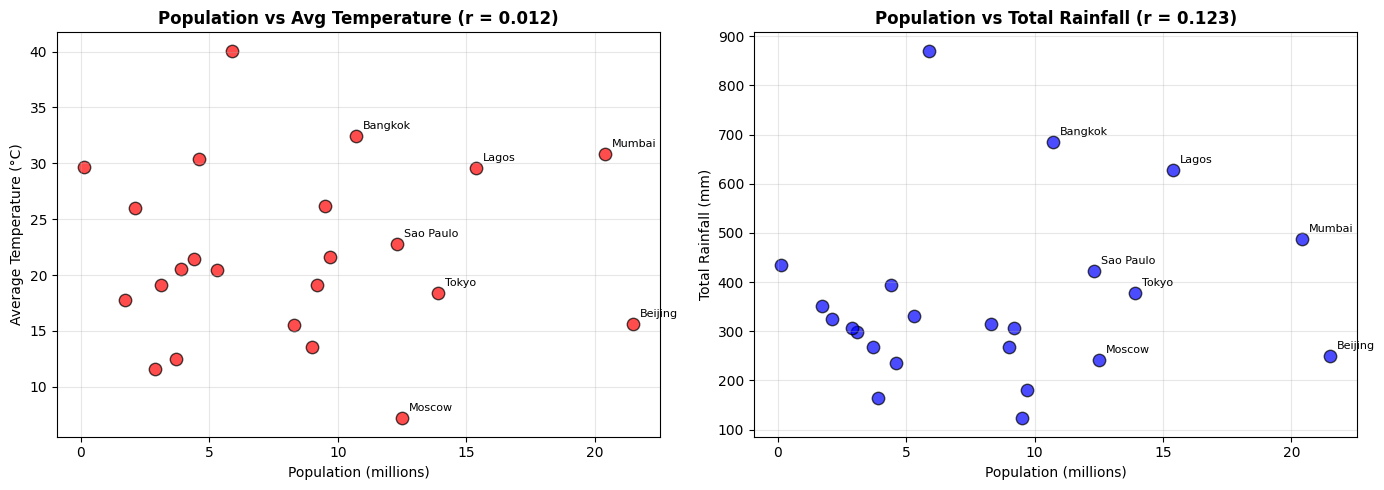

📝 ข้อสรุปและข้อควรระวัง

1. ค่าสหสัมพันธ์:
   - ประชากร vs อุณหภูมิเฉลี่ย: r = 0.012
   - ประชากร vs ปริมาณฝนรวม: r = 0.123

2. การตีความ:
   - |r| ใกล้ 0 = ไม่มีความสัมพันธ์เชิงเส้น
   - |r| ใกล้ 1 = มีความสัมพันธ์เชิงเส้นมาก
   - ค่าบวก = เมืองประชากรมาก → อุณหภูมิ/ฝนมีแนวโน้มสูงขึ้น
   - ค่าลบ = เมืองประชากรมาก → อุณหภูมิ/ฝนมีแนวโน้มต่ำลง

3. ข้อควรระวังในการตีความ (อย่างน้อย 1 ประการ):
   ⚠️ สหสัมพันธ์ไม่ได้หมายความว่าเป็นสาเหตุ-ผลลัพธ์ (correlation ≠ causation)
      อาจมีตัวแปรอื่นแทรกซ้อน เช่น ภูมิภาค/ทวีปที่มีอิทธิพลทั้งประชากรและสภาพอากาศ
   ⚠️ มี outlier (เมืองมหานครเช่น Tokyo, New York) อาจส่งผลต่อค่า r ได้มาก
   ⚠️ ข้อมูลมีเพียง 23 เมือง จึงอาจไม่เพียงพอที่จะสรุปได้อย่างมีนัยสำคัญทางสถิติ
   ⚠️ การใช้ค่าเฉลี่ยรายเมืองอาจทำให้สูญเสียรายละเอียดของการแปรปรวนภายในเมือง

4. วิธีจัดการข้อมูล: ลบค่าว่างของอุณหภูมิและปริมาณฝนก่อนคำนวณค่าเฉลี่ยรายเมือง



In [32]:
# คำตอบข้อ 18.3
# ==================== ข้อ 18.3 — ความสัมพันธ์ระหว่างประชากรกับสภาพอากาศ ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- ขั้นที่ 1: โหลดและรวมข้อมูล ----------
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")[['city', 'population_millions']]

# รวมข้อมูลประชากร
df = pd.merge(df, city_info, on='city', how='left')

# ---------- ขั้นที่ 2: สรุปข้อมูลระดับเมือง (เพราะ population เป็นค่าระดับเมือง) ----------
# วิธีจัดการ: ลบค่าว่างของอุณหภูมิและฝนก่อนคำนวณค่าเฉลี่ย
city_summary = df.dropna(subset=['temperature_c', 'rainfall_mm']).groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    total_rain=('rainfall_mm', 'sum'),
    population_millions=('population_millions', 'first')
).round(2)

print("=" * 70)
print("📊 ตารางสรุปข้อมูลระดับเมือง (ตัวอย่าง 5 แถวแรก)")
print("=" * 70)
display(city_summary.head())
print(f"จำนวนเมืองทั้งหมด: {len(city_summary)}")
print()

# ---------- ขั้นที่ 3: คำนวณค่าสหสัมพันธ์ ----------
corr_matrix = city_summary[['population_millions', 'avg_temp', 'total_rain']].corr().round(3)

print("=" * 70)
print("📈 ตารางค่าสหสัมพันธ์ (Pearson Correlation)")
print("=" * 70)
display(corr_matrix)
print()

corr_pop_temp = corr_matrix.loc['population_millions', 'avg_temp']
corr_pop_rain = corr_matrix.loc['population_millions', 'total_rain']

# ---------- ขั้นที่ 4: กราฟ scatter plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟซ้าย: ประชากร vs อุณหภูมิเฉลี่ย
city_summary.plot(
    kind='scatter', x='population_millions', y='avg_temp',
    ax=axes[0], s=80, alpha=0.7, color='red', edgecolor='black'
)
axes[0].set_title(f'Population vs Avg Temperature (r = {corr_pop_temp})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Population (millions)')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].grid(alpha=0.3)

# กราฟขวา: ประชากร vs ปริมาณฝนรวม
city_summary.plot(
    kind='scatter', x='population_millions', y='total_rain',
    ax=axes[1], s=80, alpha=0.7, color='blue', edgecolor='black'
)
axes[1].set_title(f'Population vs Total Rainfall (r = {corr_pop_rain})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Population (millions)')
axes[1].set_ylabel('Total Rainfall (mm)')
axes[1].grid(alpha=0.3)

# เพิ่มชื่อเมืองสำหรับจุดที่มีประชากรมาก
for _, row in city_summary[city_summary['population_millions'] > 10].iterrows():
    axes[0].annotate(row.name, (row['population_millions'], row['avg_temp']), fontsize=8, xytext=(5,5), textcoords='offset points')
    axes[1].annotate(row.name, (row['population_millions'], row['total_rain']), fontsize=8, xytext=(5,5), textcoords='offset points')

plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 5: ข้อสรุปและข้อควรระวัง ----------
print("=" * 70)
print("📝 ข้อสรุปและข้อควรระวัง")
print("=" * 70)
print(f"""
1. ค่าสหสัมพันธ์:
   - ประชากร vs อุณหภูมิเฉลี่ย: r = {corr_pop_temp}
   - ประชากร vs ปริมาณฝนรวม: r = {corr_pop_rain}

2. การตีความ:
   - |r| ใกล้ 0 = ไม่มีความสัมพันธ์เชิงเส้น
   - |r| ใกล้ 1 = มีความสัมพันธ์เชิงเส้นมาก
   - ค่าบวก = เมืองประชากรมาก → อุณหภูมิ/ฝนมีแนวโน้มสูงขึ้น
   - ค่าลบ = เมืองประชากรมาก → อุณหภูมิ/ฝนมีแนวโน้มต่ำลง

3. ข้อควรระวังในการตีความ (อย่างน้อย 1 ประการ):
   ⚠️ สหสัมพันธ์ไม่ได้หมายความว่าเป็นสาเหตุ-ผลลัพธ์ (correlation ≠ causation)
      อาจมีตัวแปรอื่นแทรกซ้อน เช่น ภูมิภาค/ทวีปที่มีอิทธิพลทั้งประชากรและสภาพอากาศ
   ⚠️ มี outlier (เมืองมหานครเช่น Tokyo, New York) อาจส่งผลต่อค่า r ได้มาก
   ⚠️ ข้อมูลมีเพียง 23 เมือง จึงอาจไม่เพียงพอที่จะสรุปได้อย่างมีนัยสำคัญทางสถิติ
   ⚠️ การใช้ค่าเฉลี่ยรายเมืองอาจทำให้สูญเสียรายละเอียดของการแปรปรวนภายในเมือง

4. วิธีจัดการข้อมูล: ลบค่าว่างของอุณหภูมิและปริมาณฝนก่อนคำนวณค่าเฉลี่ยรายเมือง
""")

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

⚠️ ตาราง: เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดของแต่ละภูมิภาค


,region,month,avg_temp,total_rain,avg_humidity,bad_score
0,Asia,2025-03,33.11,1006.3,66.46,3.91
1,Africa,2025-02,32.90,429.6,64.02,1.16
2,Europe,2025-03,22.00,359.5,71.47,0.73
3,South America,2025-03,22.32,306.0,71.81,0.65
4,Oceania,2025-03,20.59,226.1,71.75,0.05
5,North America,2025-01,15.16,393.3,61.62,-2.43


<Figure size 1200x600 with 0 Axes>

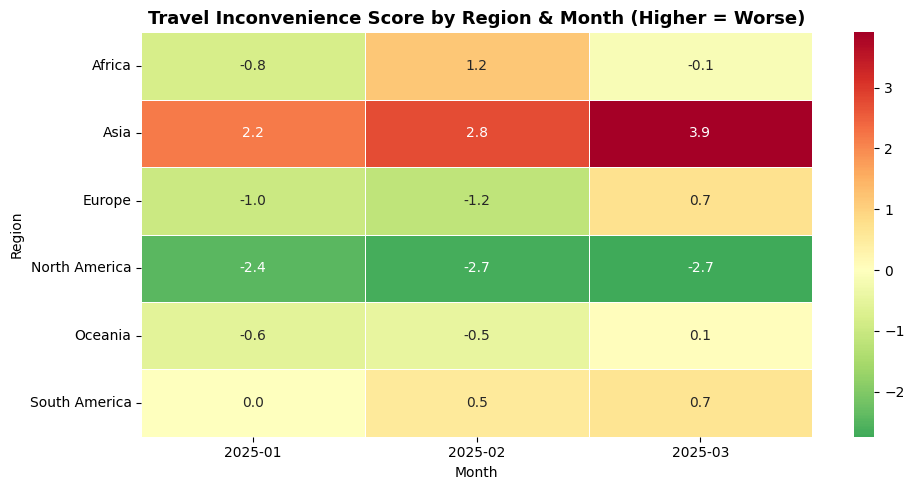

📝 ข้อสรุปและอธิบายเกณฑ์การตัดสินใจ

เกณฑ์ที่เลือกใช้:
คะแนนความไม่เหมาะสม = z-score(อุณหภูมิ) + z-score(ฝนรวม) + z-score(ความชื้น)

เหตุผลของการเลือกเกณฑ์:
1. อุณหภูมิสูง → ร้อนจัด เดินทางไม่สบาย เสี่ยงโรคลมร้อน
2. ฝนรวมสูง → ฝนตกบ่อย/หนัก เดินทางลำบาก เสี่ยงน้ำท่วม
3. ความชื้นสูง → รู้สึกร้อนมากกว่าความเป็นจริง เหงื่อออกมาก
4. ใช้ z-score เพราะหน่วยต่างกัน (°C, มม., %) — ต้องมาตรฐานก่อนรวมคะแนน
5. น้ำหนักเท่ากันทุกปัจจัย เพราะทั้งสามอย่างส่งผลต่อความสะดวกในการเดินทางในระดับใกล้เคียงกัน

ข้อควรระวัง:
- เกณฑ์นี้เป็นเพียงแนวทาง อาจต้องปรับน้ำหนักตามวัตถุประสงค์การเดินทาง
  (เช่น ไปเที่ยวชายหาดอาจให้น้ำหนักฝนมากกว่า)
- ข้อมูลมีเพียง 3 เดือน จึงอาจไม่ครอบคลุมฤดูกาลทั้งหมด

วิธีจัดการข้อมูล: ลบค่าว่างของอุณหภูมิ, ฝน, ความชื้นก่อนคำนวณค่าเฉลี่ยรายภูมิภาค-เดือน



In [33]:
# คำตอบข้อ 18.4
# ==================== ข้อ 18.4 — เดือนที่ควรหลีกเลี่ยงการเดินทางของแต่ละภูมิภาค ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- ขั้นที่ 1: โหลดและเตรียมข้อมูล ----------
BASE = "https://raw.githubusercontent.com/PitchayaW/SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
df = pd.read_csv(BASE + "world_weather_sample.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.strftime('%Y-%m')

# วิธีจัดการ: ลบค่าว่างของตัวแปรที่ใช้คำนวณก่อน
df_clean = df.dropna(subset=['temperature_c', 'rainfall_mm', 'humidity_pct'])

# ---------- ขั้นที่ 2: กำหนดเกณฑ์การตัดสินใจ ----------
# เกณฑ์: การเดินทางไม่สะดวกเมื่อ → ร้อนจัด + ฝนตกหนัก + ความชื้นสูง
# วิธีคำนวณ: ใช้ z-score มาตรฐานของแต่ละปัจจัย แล้วรวมเป็นคะแนนความไม่เหมาะสม
# เหตุผล: z-score ทำให้เปรียบเทียบได้ยุติธรรมข้ามหน่วย (องศา, มม., %)
#          ยิ่งคะแนนสูง = ยิ่งไม่เหมาะสำหรับการเดินทาง

# คำนวณค่าเฉลี่ยรายภูมิภาค-เดือน
region_month = df_clean.groupby(['region', 'month']).agg(
    avg_temp=('temperature_c', 'mean'),
    total_rain=('rainfall_mm', 'sum'),
    avg_humidity=('humidity_pct', 'mean')
).round(2).reset_index()

# คำนวณ z-score ของแต่ละปัจจัย (เทียบกับค่าเฉลี่ยทั้งหมด)
for col in ['avg_temp', 'total_rain', 'avg_humidity']:
    region_month[f'z_{col}'] = (region_month[col] - region_month[col].mean()) / region_month[col].std()

# คะแนนความไม่เหมาะสม = ผลรวม z-score ของทั้งสามปัจจัย
region_month['bad_score'] = (
    region_month['z_avg_temp'] +
    region_month['z_total_rain'] +
    region_month['z_avg_humidity']
).round(2)

# ---------- ขั้นที่ 3: หาเดือนที่ควรหลีกเลี่ยงมากที่สุดของแต่ละภูมิภาค ----------
worst_month_idx = region_month.groupby('region')['bad_score'].idxmax()
worst_months = region_month.loc[worst_month_idx, ['region', 'month', 'avg_temp', 'total_rain', 'avg_humidity', 'bad_score']]
worst_months = worst_months.sort_values('bad_score', ascending=False).reset_index(drop=True)

print("=" * 80)
print("⚠️ ตาราง: เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดของแต่ละภูมิภาค")
print("=" * 80)
display(worst_months)
print()

# ---------- ขั้นที่ 4: กราฟแสดงคะแนนความไม่เหมาะสม ----------
pivot_score = region_month.pivot(index='region', columns='month', values='bad_score')

plt.figure(figsize=(12, 6))
sns_heatmap = pivot_score.style.background_gradient(cmap='RdYlGn_r', axis=None)
# ใช้ matplotlib heatmap แทนเพื่อแสดงผลได้ชัดเจน
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_score, annot=True, cmap='RdYlGn_r', center=0, fmt='.1f', linewidths=0.5)
plt.title('Travel Inconvenience Score by Region & Month (Higher = Worse)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# ---------- ขั้นที่ 5: ข้อสรุปและอธิบายเกณฑ์ ----------
print("=" * 80)
print("📝 ข้อสรุปและอธิบายเกณฑ์การตัดสินใจ")
print("=" * 80)
print("""
เกณฑ์ที่เลือกใช้:
คะแนนความไม่เหมาะสม = z-score(อุณหภูมิ) + z-score(ฝนรวม) + z-score(ความชื้น)

เหตุผลของการเลือกเกณฑ์:
1. อุณหภูมิสูง → ร้อนจัด เดินทางไม่สบาย เสี่ยงโรคลมร้อน
2. ฝนรวมสูง → ฝนตกบ่อย/หนัก เดินทางลำบาก เสี่ยงน้ำท่วม
3. ความชื้นสูง → รู้สึกร้อนมากกว่าความเป็นจริง เหงื่อออกมาก
4. ใช้ z-score เพราะหน่วยต่างกัน (°C, มม., %) — ต้องมาตรฐานก่อนรวมคะแนน
5. น้ำหนักเท่ากันทุกปัจจัย เพราะทั้งสามอย่างส่งผลต่อความสะดวกในการเดินทางในระดับใกล้เคียงกัน

ข้อควรระวัง:
- เกณฑ์นี้เป็นเพียงแนวทาง อาจต้องปรับน้ำหนักตามวัตถุประสงค์การเดินทาง
  (เช่น ไปเที่ยวชายหาดอาจให้น้ำหนักฝนมากกว่า)
- ข้อมูลมีเพียง 3 เดือน จึงอาจไม่ครอบคลุมฤดูกาลทั้งหมด

วิธีจัดการข้อมูล: ลบค่าว่างของอุณหภูมิ, ฝน, ความชื้นก่อนคำนวณค่าเฉลี่ยรายภูมิภาค-เดือน
""")

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️